CISLR MULTIMODAL MODEL — L13.0
RGB ↔ LANDMARK ALIGNMENT + LANDMARK-GUIDED VISUAL ROI PIPELINE

Project root : /home/dipshikha/Music/cao/CISLR_RESEARCH
Video dir    : /home/dipshikha/Music/cao/CISLR_v1.5-a_videos
Raw dir      : /home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l6_full_extraction/raw_sequences
Output root  : /home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l13_multimodal/l13_0_rgb_pipeline

Sequence length       : 32
Hand box scale        : 1.6
Context box scale     : 1.5
Minimum hand box      : 32
Minimum context box   : 96

[PASS] Required L6/L9/video paths exist.

FROZEN L9 SPLIT

Train      : 585
Validation : 211
Test       : 211 (LOCKED)

Train ∩ Val  : 0
Train ∩ Test : 0
Val ∩ Test   : 0

[PASS] Frozen L9 split verified.

INDEXING L6 RAW SEQUENCES

Raw NPZ files : 7050
  1000/7050
  2000/7050
  3000/7050
  4000/7050
  5000/7050
  6000/7050
  7000/7050
  7050/7050

Indexed UIDs   : 7050
Duplicate UIDs : 0

INDEXING ORIGINAL CISLR

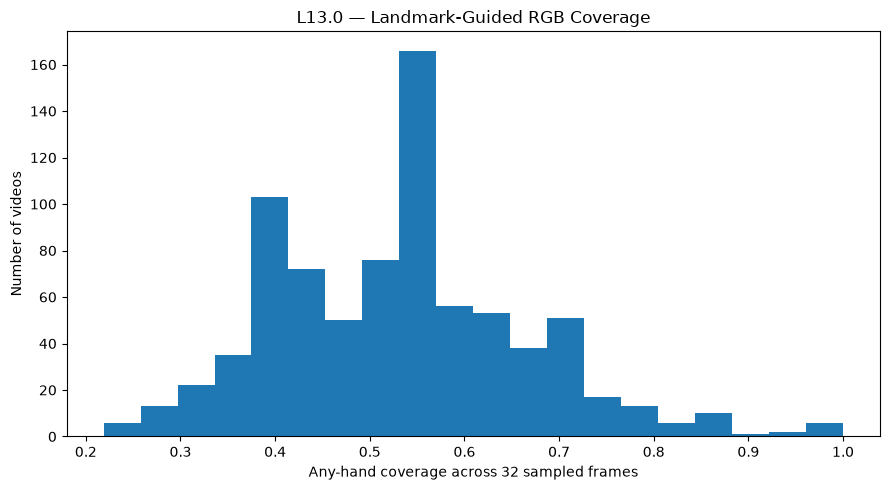


CACHE STRUCTURAL AUDIT
  audited 200/796
  audited 400/796
  audited 600/796
  audited 796/796

Cache files : 796
Bad cache   : 0

L13.0 FINAL REPORT

DATA
----------------------------------------------------------------------------------------------------------------------------------
Original CISLR videos       : 7050
L6 raw sequences            : 7050

FROZEN L9
----------------------------------------------------------------------------------------------------------------------------------
Train                       : 585
Validation                  : 211
Test                        : 211 (LOCKED)

RGB ↔ LANDMARK ALIGNMENT
----------------------------------------------------------------------------------------------------------------------------------
Expected TRAIN+VAL          : 796
Processed                   : 796
Failures                    : 0
Alignment PASS              : 796
Alignment FAIL              : 0
Mean RGB decode rate        : 100.00%

LANDMARK-GUIDED VISUAL COVE

In [1]:
# ==================================================================================================
# CISLR MULTIMODAL MODEL — L13.0
# RGB ↔ LANDMARK ALIGNMENT + LANDMARK-GUIDED VISUAL ROI PIPELINE + AUDIT
# ==================================================================================================
#
# PURPOSE
# -------
# Prepare and validate the RGB stream that will later be combined with the frozen
# L12B SSL-ST-GCN skeleton stream.
#
# L13.0 DOES NOT TRAIN A MODEL.
#
# INPUT
# -----
# 1. Original CISLR MP4 videos
# 2. L6 raw landmark sequences
# 3. Frozen L9 train / validation / test manifests
#
# OUTPUT
# ------
# For TRAIN + VALIDATION only:
#
#   Original video
#        +
#   L6 frame_numbers
#        +
#   landmarks_px
#        +
#   hand_mask
#        ↓
#   32 synchronized temporal samples
#        ↓
#   landmark-guided visual crops
#
# Saved cache per video:
#
#   uid
#   gloss
#   sampled_video_frames
#   sampled_l6_indices
#   hand0_boxes
#   hand1_boxes
#   context_boxes
#   hand0_valid
#   hand1_valid
#   context_valid
#   palm_scores
#
# IMPORTANT
# ---------
# RGB images themselves are NOT permanently duplicated here.
#
# L13A will use the saved frame indices + boxes to decode/crop frames dynamically
# or build an embedding cache.
#
# TEST:
# -----
# Test manifest is verified for leakage.
# Test videos are NEVER opened.
# Test RGB frames are NEVER decoded.
#
# ==================================================================================================


# ==================================================================================================
# 0. IMPORTS
# ==================================================================================================

import os
import cv2
import json
import math
import time
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==================================================================================================
# 1. CONFIGURATION
# ==================================================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)

MODEL_ROOT = (
    PROJECT_ROOT
    / "CISLR_LANDMARK_MODEL"
)

VIDEO_DIR = Path(
    "/home/dipshikha/Music/cao/CISLR_v1.5-a_videos"
)

RAW_DIR = (
    MODEL_ROOT
    / "audit"
    / "l6_full_extraction"
    / "raw_sequences"
)

L9_ROOT = (
    MODEL_ROOT
    / "audit"
    / "l9_split_freeze"
)

TRAIN_MANIFEST = (
    L9_ROOT
    / "splits"
    / "l9_train_manifest.csv"
)

VAL_MANIFEST = (
    L9_ROOT
    / "splits"
    / "l9_validation_manifest.csv"
)

TEST_MANIFEST = (
    L9_ROOT
    / "splits"
    / "l9_test_manifest.csv"
)

CLASS_MAPPING_PATH = (
    L9_ROOT
    / "class_mapping"
    / "l9_controlled_class_mapping.json"
)


# --------------------------------------------------------------------------------------------------
# L13 ROOT
# --------------------------------------------------------------------------------------------------

L13_ROOT = (
    MODEL_ROOT
    / "audit"
    / "l13_multimodal"
)

L130_ROOT = (
    L13_ROOT
    / "l13_0_rgb_pipeline"
)

CACHE_DIR = (
    L130_ROOT
    / "cache"
)

REPORT_DIR = (
    L130_ROOT
    / "reports"
)

AUDIT_DIR = (
    L130_ROOT
    / "audit_frames"
)

for d in [
    L13_ROOT,
    L130_ROOT,
    CACHE_DIR,
    REPORT_DIR,
    AUDIT_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )


# ==================================================================================================
# 2. L13.0 PARAMETERS
# ==================================================================================================

SEQ_LEN = 32

NUM_HANDS = 2
NUM_JOINTS = 21

# --------------------------------------------------------------------------------------------------
# Hand ROI
#
# The box is constructed from visible 21-point landmarks.
#
# Padding is proportional to landmark bounding-box size.
# --------------------------------------------------------------------------------------------------

HAND_BOX_SCALE = 1.60

MIN_HAND_BOX_SIZE = 32

# --------------------------------------------------------------------------------------------------
# Context ROI
#
# Context ROI contains BOTH hands whenever possible and some surrounding visual context.
#
# This preserves information such as:
#     hand-to-hand relationship
#     hand near face/body
#     relative global hand location
# --------------------------------------------------------------------------------------------------

CONTEXT_BOX_SCALE = 1.50

MIN_CONTEXT_BOX_SIZE = 96

# --------------------------------------------------------------------------------------------------
# Audit
# --------------------------------------------------------------------------------------------------

AUDIT_VIDEOS_PER_SPLIT = 10

AUDIT_FRAMES_PER_VIDEO = 4

# --------------------------------------------------------------------------------------------------
# Quality thresholds
# --------------------------------------------------------------------------------------------------

MIN_ANY_HAND_COVERAGE = 0.20

GOOD_COVERAGE = 0.80

WARNING_COVERAGE = 0.50


# ==================================================================================================
# 3. HEADER
# ==================================================================================================

print("=" * 130)
print("CISLR MULTIMODAL MODEL — L13.0")
print("RGB ↔ LANDMARK ALIGNMENT + LANDMARK-GUIDED VISUAL ROI PIPELINE")
print("=" * 130)

print()
print("Project root :", PROJECT_ROOT)
print("Video dir    :", VIDEO_DIR)
print("Raw dir      :", RAW_DIR)
print("Output root  :", L130_ROOT)

print()
print("Sequence length       :", SEQ_LEN)
print("Hand box scale        :", HAND_BOX_SCALE)
print("Context box scale     :", CONTEXT_BOX_SCALE)
print("Minimum hand box      :", MIN_HAND_BOX_SIZE)
print("Minimum context box   :", MIN_CONTEXT_BOX_SIZE)


# ==================================================================================================
# 4. REQUIRED PATH CHECK
# ==================================================================================================

required_paths = [
    VIDEO_DIR,
    RAW_DIR,
    TRAIN_MANIFEST,
    VAL_MANIFEST,
    TEST_MANIFEST,
    CLASS_MAPPING_PATH,
]

for p in required_paths:

    if not p.exists():

        raise FileNotFoundError(
            f"Missing required path:\n{p}"
        )


print()
print("[PASS] Required L6/L9/video paths exist.")


# ==================================================================================================
# 5. LOAD FROZEN L9 MANIFESTS
# ==================================================================================================

train_df = pd.read_csv(
    TRAIN_MANIFEST
)

val_df = pd.read_csv(
    VAL_MANIFEST
)

test_df = pd.read_csv(
    TEST_MANIFEST
)


for name, df in [
    ("TRAIN", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df),
]:

    if "uid" not in df.columns:

        raise RuntimeError(
            f"{name} manifest missing UID column."
        )

    df["uid"] = (
        df["uid"]
        .astype(str)
    )


# --------------------------------------------------------------------------------------------------
# Frozen counts
# --------------------------------------------------------------------------------------------------

assert len(train_df) == 585
assert len(val_df) == 211
assert len(test_df) == 211


train_uids = set(
    train_df["uid"]
)

val_uids = set(
    val_df["uid"]
)

test_uids = set(
    test_df["uid"]
)


assert len(
    train_uids & val_uids
) == 0

assert len(
    train_uids & test_uids
) == 0

assert len(
    val_uids & test_uids
) == 0


print()
print("=" * 130)
print("FROZEN L9 SPLIT")
print("=" * 130)

print()
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df), "(LOCKED)")

print()
print("Train ∩ Val  :", len(train_uids & val_uids))
print("Train ∩ Test :", len(train_uids & test_uids))
print("Val ∩ Test   :", len(val_uids & test_uids))

print()
print("[PASS] Frozen L9 split verified.")


# ==================================================================================================
# 6. INDEX L6 RAW SEQUENCES
# ==================================================================================================

raw_files = sorted(
    RAW_DIR.glob("*.npz")
)

print()
print("=" * 130)
print("INDEXING L6 RAW SEQUENCES")
print("=" * 130)

print()
print("Raw NPZ files :", len(raw_files))


uid_to_raw = {}

duplicate_raw_uids = []


for i, path in enumerate(
    raw_files,
    start=1
):

    try:

        with np.load(
            path,
            allow_pickle=True
        ) as d:

            uid = str(
                d["uid"].item()
            )

        if uid in uid_to_raw:

            duplicate_raw_uids.append(
                uid
            )

        else:

            uid_to_raw[uid] = path

    except Exception as e:

        print(
            "[WARNING] Could not index raw file:",
            path.name,
            str(e)
        )

    if (
        i % 1000 == 0
        or i == len(raw_files)
    ):

        print(
            f"  {i}/{len(raw_files)}"
        )


print()
print("Indexed UIDs   :", len(uid_to_raw))
print("Duplicate UIDs :", len(duplicate_raw_uids))


# ==================================================================================================
# 7. INDEX ORIGINAL CISLR MP4 VIDEOS
# ==================================================================================================

print()
print("=" * 130)
print("INDEXING ORIGINAL CISLR VIDEOS")
print("=" * 130)


video_files = sorted(
    VIDEO_DIR.glob("*.mp4")
)


print()
print("MP4 files :", len(video_files))


# --------------------------------------------------------------------------------------------------
# First map filename stem -> path.
#
# CISLR filenames normally correspond to UID, but some filenames can contain suffixes.
# We also use the exact video_path stored inside L6 raw NPZ as the authoritative fallback.
# --------------------------------------------------------------------------------------------------

stem_to_video = {}

for path in video_files:

    stem_to_video[
        path.stem
    ] = path


print("[PASS] Original video index created.")


# ==================================================================================================
# 8. VIDEO RESOLUTION
# ==================================================================================================

def resolve_video_path(
    uid,
    raw_path
):

    """
    Resolve the original MP4 corresponding to one L6 raw sequence.

    Priority:
        1. video_path stored in the raw NPZ
        2. exact filename stem == UID
        3. VIDEO_DIR / stored filename
    """

    # ----------------------------------------------------------------------------------------------
    # 1. L6 stored source path
    # ----------------------------------------------------------------------------------------------

    stored_video = None

    try:

        with np.load(
            raw_path,
            allow_pickle=True
        ) as d:

            if "video_path" in d.files:

                stored_video = Path(
                    str(
                        d["video_path"].item()
                    )
                )

    except Exception:

        stored_video = None


    if (
        stored_video is not None
        and stored_video.exists()
    ):

        return stored_video


    # ----------------------------------------------------------------------------------------------
    # 2. UID exact stem
    # ----------------------------------------------------------------------------------------------

    if uid in stem_to_video:

        return stem_to_video[uid]


    # ----------------------------------------------------------------------------------------------
    # 3. Stored filename under VIDEO_DIR
    # ----------------------------------------------------------------------------------------------

    if stored_video is not None:

        candidate = (
            VIDEO_DIR
            / stored_video.name
        )

        if candidate.exists():

            return candidate


    return None


# ==================================================================================================
# 9. TEMPORAL SAMPLING
# ==================================================================================================

def uniform_indices(
    length,
    target_length=32
):

    if length <= 0:

        return np.zeros(
            target_length,
            dtype=np.int64
        )

    idx = np.linspace(
        0,
        length - 1,
        target_length
    )

    idx = np.round(
        idx
    ).astype(
        np.int64
    )

    idx = np.clip(
        idx,
        0,
        length - 1
    )

    return idx


# ==================================================================================================
# 10. BOX UTILITIES
# ==================================================================================================

def clip_box(
    box,
    width,
    height
):

    x1, y1, x2, y2 = box

    x1 = int(
        max(
            0,
            min(
                width - 1,
                round(x1)
            )
        )
    )

    y1 = int(
        max(
            0,
            min(
                height - 1,
                round(y1)
            )
        )
    )

    x2 = int(
        max(
            x1 + 1,
            min(
                width,
                round(x2)
            )
        )
    )

    y2 = int(
        max(
            y1 + 1,
            min(
                height,
                round(y2)
            )
        )
    )

    return np.array(
        [x1, y1, x2, y2],
        dtype=np.int32
    )


def square_box_from_points(
    points_xy,
    width,
    height,
    scale=1.60,
    minimum_size=32
):

    """
    points_xy:
        [N,2]

    Produces a square landmark-guided box.
    """

    points_xy = np.asarray(
        points_xy,
        dtype=np.float32
    )

    finite = np.isfinite(
        points_xy
    ).all(
        axis=1
    )

    points_xy = points_xy[
        finite
    ]


    if len(points_xy) == 0:

        return None


    x_min = float(
        points_xy[:, 0].min()
    )

    x_max = float(
        points_xy[:, 0].max()
    )

    y_min = float(
        points_xy[:, 1].min()
    )

    y_max = float(
        points_xy[:, 1].max()
    )


    cx = (
        x_min + x_max
    ) / 2.0

    cy = (
        y_min + y_max
    ) / 2.0


    raw_w = max(
        x_max - x_min,
        1.0
    )

    raw_h = max(
        y_max - y_min,
        1.0
    )


    side = max(
        raw_w,
        raw_h
    )

    side *= scale

    side = max(
        side,
        float(minimum_size)
    )


    box = [
        cx - side / 2.0,
        cy - side / 2.0,
        cx + side / 2.0,
        cy + side / 2.0,
    ]


    return clip_box(
        box,
        width,
        height
    )


def context_box_from_hands(
    landmarks,
    mask,
    width,
    height
):

    """
    landmarks:
        [2,21,3]

    mask:
        [2]

    Builds one square context box around all visible hands.
    """

    all_points = []


    for h in range(NUM_HANDS):

        if mask[h] <= 0:

            continue


        pts = landmarks[
            h,
            :,
            :2
        ]


        finite = np.isfinite(
            pts
        ).all(
            axis=1
        )

        pts = pts[
            finite
        ]


        if len(pts) > 0:

            all_points.append(
                pts
            )


    if len(all_points) == 0:

        return None


    all_points = np.concatenate(
        all_points,
        axis=0
    )


    return square_box_from_points(
        all_points,
        width,
        height,
        scale=CONTEXT_BOX_SCALE,
        minimum_size=MIN_CONTEXT_BOX_SIZE
    )


# ==================================================================================================
# 11. SAFE FRAME READER
# ==================================================================================================

def read_specific_frame(
    cap,
    frame_number
):

    """
    Decode a requested frame.

    Used only for TRAIN / VALIDATION auditing.
    """

    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        int(frame_number)
    )

    ok, frame = cap.read()

    if not ok:

        return None

    return frame


# ==================================================================================================
# 12. PROCESS ONE VIDEO
# ==================================================================================================

def process_video_alignment(
    uid,
    split,
    gloss=None,
    make_audit=False
):

    """
    IMPORTANT:
        This function must NEVER be called on TEST UIDs.
    """

    if uid in test_uids:

        raise RuntimeError(
            "SECURITY CHECK: attempted to open a locked TEST video."
        )


    # ----------------------------------------------------------------------------------------------
    # Raw sequence
    # ----------------------------------------------------------------------------------------------

    if uid not in uid_to_raw:

        return None, "missing_raw_sequence"


    raw_path = uid_to_raw[
        uid
    ]


    # ----------------------------------------------------------------------------------------------
    # Original video
    # ----------------------------------------------------------------------------------------------

    video_path = resolve_video_path(
        uid,
        raw_path
    )


    if video_path is None:

        return None, "missing_video"


    # ----------------------------------------------------------------------------------------------
    # Load L6 metadata
    # ----------------------------------------------------------------------------------------------

    try:

        with np.load(
            raw_path,
            allow_pickle=True
        ) as d:

            loaded_uid = str(
                d["uid"].item()
            )

            frame_numbers = d[
                "frame_numbers"
            ].astype(
                np.int64
            )

            landmarks_px = d[
                "landmarks_px"
            ].astype(
                np.float32
            )

            hand_mask = d[
                "hand_mask"
            ].astype(
                np.uint8
            )

            palm_scores = d[
                "palm_scores"
            ].astype(
                np.float32
            )

            raw_width = int(
                d["width"].item()
            )

            raw_height = int(
                d["height"].item()
            )

            raw_fps = float(
                d["fps"].item()
            )


    except Exception as e:

        return (
            None,
            f"raw_load_error:{str(e)}"
        )


    # ----------------------------------------------------------------------------------------------
    # Structural checks
    # ----------------------------------------------------------------------------------------------

    if loaded_uid != uid:

        return None, "uid_mismatch"


    T = len(
        frame_numbers
    )


    if landmarks_px.shape != (
        T,
        2,
        21,
        3
    ):

        return (
            None,
            f"bad_landmark_shape:{landmarks_px.shape}"
        )


    if hand_mask.shape != (
        T,
        2
    ):

        return (
            None,
            f"bad_mask_shape:{hand_mask.shape}"
        )


    if palm_scores.shape != (
        T,
        2
    ):

        return (
            None,
            f"bad_palm_score_shape:{palm_scores.shape}"
        )


    # ----------------------------------------------------------------------------------------------
    # Open video metadata
    # ----------------------------------------------------------------------------------------------

    cap = cv2.VideoCapture(
        str(video_path)
    )


    if not cap.isOpened():

        return None, "video_open_failed"


    video_frame_count = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )

    video_width = int(
        cap.get(
            cv2.CAP_PROP_FRAME_WIDTH
        )
    )

    video_height = int(
        cap.get(
            cv2.CAP_PROP_FRAME_HEIGHT
        )
    )

    video_fps = float(
        cap.get(
            cv2.CAP_PROP_FPS
        )
    )


    # ----------------------------------------------------------------------------------------------
    # Metadata alignment checks
    # ----------------------------------------------------------------------------------------------

    dimensions_match = (
        video_width == raw_width
        and
        video_height == raw_height
    )


    fps_match = (
        abs(
            video_fps - raw_fps
        ) < 0.25
    )


    frame_numbers_valid = bool(
        np.all(
            frame_numbers >= 0
        )
        and
        np.all(
            frame_numbers < max(
                video_frame_count,
                1
            )
        )
    )


    # ----------------------------------------------------------------------------------------------
    # Same temporal philosophy as L12B:
    #
    # Uniformly select 32 positions from the L6 sequence.
    #
    # Crucially:
    #
    # sampled_l6_idx
    #       ↓
    # frame_numbers[sampled_l6_idx]
    #       ↓
    # actual MP4 frame
    #
    # Therefore RGB and skeleton refer to the same source time.
    # ----------------------------------------------------------------------------------------------

    sampled_l6_idx = uniform_indices(
        T,
        SEQ_LEN
    )


    sampled_video_frames = frame_numbers[
        sampled_l6_idx
    ]


    sampled_landmarks = landmarks_px[
        sampled_l6_idx
    ]


    sampled_mask = hand_mask[
        sampled_l6_idx
    ]


    sampled_palm_scores = palm_scores[
        sampled_l6_idx
    ]


    # ----------------------------------------------------------------------------------------------
    # Boxes
    # ----------------------------------------------------------------------------------------------

    hand0_boxes = np.full(
        (SEQ_LEN, 4),
        -1,
        dtype=np.int32
    )

    hand1_boxes = np.full(
        (SEQ_LEN, 4),
        -1,
        dtype=np.int32
    )

    context_boxes = np.full(
        (SEQ_LEN, 4),
        -1,
        dtype=np.int32
    )


    hand0_valid = np.zeros(
        SEQ_LEN,
        dtype=np.uint8
    )

    hand1_valid = np.zeros(
        SEQ_LEN,
        dtype=np.uint8
    )

    context_valid = np.zeros(
        SEQ_LEN,
        dtype=np.uint8
    )


    for t in range(
        SEQ_LEN
    ):

        # ------------------------------------------------------------------------------------------
        # Track 0
        # ------------------------------------------------------------------------------------------

        if sampled_mask[
            t,
            0
        ] > 0:

            box = square_box_from_points(
                sampled_landmarks[
                    t,
                    0,
                    :,
                    :2
                ],
                video_width,
                video_height,
                scale=HAND_BOX_SCALE,
                minimum_size=MIN_HAND_BOX_SIZE
            )

            if box is not None:

                hand0_boxes[
                    t
                ] = box

                hand0_valid[
                    t
                ] = 1


        # ------------------------------------------------------------------------------------------
        # Track 1
        # ------------------------------------------------------------------------------------------

        if sampled_mask[
            t,
            1
        ] > 0:

            box = square_box_from_points(
                sampled_landmarks[
                    t,
                    1,
                    :,
                    :2
                ],
                video_width,
                video_height,
                scale=HAND_BOX_SCALE,
                minimum_size=MIN_HAND_BOX_SIZE
            )

            if box is not None:

                hand1_boxes[
                    t
                ] = box

                hand1_valid[
                    t
                ] = 1


        # ------------------------------------------------------------------------------------------
        # Context
        # ------------------------------------------------------------------------------------------

        box = context_box_from_hands(
            sampled_landmarks[
                t
            ],
            sampled_mask[
                t
            ],
            video_width,
            video_height
        )

        if box is not None:

            context_boxes[
                t
            ] = box

            context_valid[
                t
            ] = 1


    # ----------------------------------------------------------------------------------------------
    # Coverage
    # ----------------------------------------------------------------------------------------------

    any_hand = (
        (hand0_valid > 0)
        |
        (hand1_valid > 0)
    )


    both_hands = (
        (hand0_valid > 0)
        &
        (hand1_valid > 0)
    )


    any_hand_coverage = float(
        np.mean(
            any_hand
        )
    )

    both_hand_coverage = float(
        np.mean(
            both_hands
        )
    )

    track0_coverage = float(
        np.mean(
            hand0_valid
        )
    )

    track1_coverage = float(
        np.mean(
            hand1_valid
        )
    )

    context_coverage = float(
        np.mean(
            context_valid
        )
    )


    if any_hand_coverage >= GOOD_COVERAGE:

        quality = "GOOD"

    elif any_hand_coverage >= WARNING_COVERAGE:

        quality = "REVIEW"

    else:

        quality = "POOR"


    # ----------------------------------------------------------------------------------------------
    # Verify actual selected RGB frames can be decoded.
    #
    # We decode the 32 selected frames during L13.0 because alignment must be proven,
    # but we DO NOT save 32 full RGB images.
    # ----------------------------------------------------------------------------------------------

    decoded_ok = np.zeros(
        SEQ_LEN,
        dtype=np.uint8
    )


    audit_images = []


    # Select a small subset for visual montage.

    if make_audit:

        audit_positions = np.unique(
            np.round(
                np.linspace(
                    0,
                    SEQ_LEN - 1,
                    AUDIT_FRAMES_PER_VIDEO
                )
            ).astype(
                np.int64
            )
        )

        audit_positions = set(
            audit_positions.tolist()
        )

    else:

        audit_positions = set()


    for t in range(
        SEQ_LEN
    ):

        frame_number = int(
            sampled_video_frames[
                t
            ]
        )


        frame = read_specific_frame(
            cap,
            frame_number
        )


        if frame is None:

            continue


        decoded_ok[
            t
        ] = 1


        if t not in audit_positions:

            continue


        vis = frame.copy()


        # ------------------------------------------------------------------------------------------
        # Draw skeleton
        # ------------------------------------------------------------------------------------------

        for h in range(
            NUM_HANDS
        ):

            if sampled_mask[
                t,
                h
            ] <= 0:

                continue


            pts = sampled_landmarks[
                t,
                h,
                :,
                :2
            ]


            # joints

            for p in pts:

                if not np.isfinite(
                    p
                ).all():

                    continue

                cv2.circle(
                    vis,
                    (
                        int(round(p[0])),
                        int(round(p[1]))
                    ),
                    2,
                    (
                        0,
                        255,
                        0
                    ),
                    -1
                )


        # ------------------------------------------------------------------------------------------
        # Hand boxes
        # ------------------------------------------------------------------------------------------

        for h, (
            boxes,
            valid
        ) in enumerate(
            [
                (
                    hand0_boxes,
                    hand0_valid
                ),
                (
                    hand1_boxes,
                    hand1_valid
                ),
            ]
        ):

            if valid[
                t
            ] == 0:

                continue


            x1, y1, x2, y2 = boxes[
                t
            ]


            cv2.rectangle(
                vis,
                (
                    int(x1),
                    int(y1)
                ),
                (
                    int(x2),
                    int(y2)
                ),
                (
                    255,
                    0,
                    0
                ),
                2
            )


            cv2.putText(
                vis,
                f"H{h}",
                (
                    int(x1),
                    max(
                        15,
                        int(y1) - 4
                    )
                ),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (
                    255,
                    0,
                    0
                ),
                1,
                cv2.LINE_AA
            )


        # ------------------------------------------------------------------------------------------
        # Context box
        # ------------------------------------------------------------------------------------------

        if context_valid[
            t
        ] > 0:

            x1, y1, x2, y2 = context_boxes[
                t
            ]


            cv2.rectangle(
                vis,
                (
                    int(x1),
                    int(y1)
                ),
                (
                    int(x2),
                    int(y2)
                ),
                (
                    0,
                    165,
                    255
                ),
                2
            )


        # ------------------------------------------------------------------------------------------
        # Status
        # ------------------------------------------------------------------------------------------

        label_text = (
            f"{split} | "
            f"{gloss if gloss is not None else ''} | "
            f"frame={frame_number}"
        )


        cv2.rectangle(
            vis,
            (0, 0),
            (
                vis.shape[1],
                25
            ),
            (
                0,
                0,
                0
            ),
            -1
        )


        cv2.putText(
            vis,
            label_text,
            (
                5,
                18
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (
                255,
                255,
                255
            ),
            1,
            cv2.LINE_AA
        )


        audit_images.append(
            (
                t,
                frame_number,
                vis
            )
        )


    cap.release()


    decode_rate = float(
        decoded_ok.mean()
    )


    # ----------------------------------------------------------------------------------------------
    # Alignment status
    # ----------------------------------------------------------------------------------------------

    alignment_pass = bool(
        dimensions_match
        and
        fps_match
        and
        frame_numbers_valid
        and
        decode_rate >= 0.999
    )


    # ----------------------------------------------------------------------------------------------
    # Cache
    # ----------------------------------------------------------------------------------------------

    cache_path = (
        CACHE_DIR
        / f"{uid}.npz"
    )


    np.savez_compressed(
        cache_path,

        uid=np.array(
            uid
        ),

        gloss=np.array(
            "" if gloss is None else str(gloss)
        ),

        split=np.array(
            split
        ),

        video_path=np.array(
            str(video_path)
        ),

        raw_path=np.array(
            str(raw_path)
        ),

        video_width=np.int32(
            video_width
        ),

        video_height=np.int32(
            video_height
        ),

        video_fps=np.float32(
            video_fps
        ),

        video_frame_count=np.int32(
            video_frame_count
        ),

        sampled_l6_indices=sampled_l6_idx.astype(
            np.int32
        ),

        sampled_video_frames=sampled_video_frames.astype(
            np.int32
        ),

        sampled_landmarks_px=sampled_landmarks.astype(
            np.float32
        ),

        sampled_hand_mask=sampled_mask.astype(
            np.uint8
        ),

        sampled_palm_scores=sampled_palm_scores.astype(
            np.float32
        ),

        hand0_boxes=hand0_boxes,

        hand1_boxes=hand1_boxes,

        context_boxes=context_boxes,

        hand0_valid=hand0_valid,

        hand1_valid=hand1_valid,

        context_valid=context_valid,

        decoded_ok=decoded_ok,
    )


    # ----------------------------------------------------------------------------------------------
    # Report
    # ----------------------------------------------------------------------------------------------

    result = {

        "uid":
            uid,

        "gloss":
            (
                ""
                if gloss is None
                else str(gloss)
            ),

        "split":
            split,

        "video_path":
            str(video_path),

        "raw_path":
            str(raw_path),

        "cache_path":
            str(cache_path),

        "raw_sequence_frames":
            int(T),

        "video_frame_count":
            int(video_frame_count),

        "video_width":
            int(video_width),

        "video_height":
            int(video_height),

        "video_fps":
            float(video_fps),

        "raw_width":
            int(raw_width),

        "raw_height":
            int(raw_height),

        "raw_fps":
            float(raw_fps),

        "dimensions_match":
            bool(dimensions_match),

        "fps_match":
            bool(fps_match),

        "frame_numbers_valid":
            bool(frame_numbers_valid),

        "decode_rate":
            decode_rate,

        "alignment_pass":
            alignment_pass,

        "track0_coverage":
            track0_coverage,

        "track1_coverage":
            track1_coverage,

        "any_hand_coverage":
            any_hand_coverage,

        "both_hand_coverage":
            both_hand_coverage,

        "context_coverage":
            context_coverage,

        "quality":
            quality,

        "mean_track0_palm_score":
            float(
                sampled_palm_scores[
                    :,
                    0
                ].mean()
            ),

        "mean_track1_palm_score":
            float(
                sampled_palm_scores[
                    :,
                    1
                ].mean()
            ),
    }


    return (
        result,
        audit_images
    )


# ==================================================================================================
# 13. AUDIT IMAGE SAVER
# ==================================================================================================

def save_audit_montage(
    uid,
    gloss,
    split,
    audit_images
):

    if len(
        audit_images
    ) == 0:

        return None


    # ----------------------------------------------------------------------------------------------
    # Normalize all images to same display height
    # ----------------------------------------------------------------------------------------------

    target_h = 300

    resized = []


    for (
        temporal_idx,
        frame_number,
        img
    ) in audit_images:

        h, w = img.shape[
            :2
        ]

        scale = (
            target_h
            / max(
                h,
                1
            )
        )

        new_w = max(
            1,
            int(
                round(
                    w * scale
                )
            )
        )


        r = cv2.resize(
            img,
            (
                new_w,
                target_h
            ),
            interpolation=cv2.INTER_AREA
        )


        cv2.putText(
            r,
            f"t={temporal_idx}",
            (
                5,
                target_h - 8
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (
                255,
                255,
                255
            ),
            1,
            cv2.LINE_AA
        )


        resized.append(
            r
        )


    montage = cv2.hconcat(
        resized
    )


    safe_gloss = (
        str(gloss)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
    )


    out_path = (
        AUDIT_DIR
        / f"{split}_{safe_gloss}_{uid}.jpg"
    )


    cv2.imwrite(
        str(out_path),
        montage
    )


    return out_path


# ==================================================================================================
# 14. SELECT AUDIT VIDEOS
# ==================================================================================================

rng = np.random.default_rng(
    SEED
)


def select_audit_uids(
    df,
    n
):

    if len(df) <= n:

        return set(
            df["uid"].astype(str)
        )


    indices = rng.choice(
        len(df),
        size=n,
        replace=False
    )


    return set(
        df.iloc[
            indices
        ]["uid"].astype(str)
    )


train_audit_uids = select_audit_uids(
    train_df,
    AUDIT_VIDEOS_PER_SPLIT
)

val_audit_uids = select_audit_uids(
    val_df,
    AUDIT_VIDEOS_PER_SPLIT
)


print()
print("Train visual audit videos :", len(train_audit_uids))
print("Val visual audit videos   :", len(val_audit_uids))
print("Test visual audit videos  : 0")


# ==================================================================================================
# 15. PROCESS TRAIN / VALIDATION
# ==================================================================================================

all_results = []

failures = []


def run_split(
    df,
    split_name,
    audit_uids
):

    print()
    print("=" * 130)
    print(
        f"PROCESSING {split_name}"
    )
    print("=" * 130)

    start_time = time.time()


    for i, (
        _,
        row
    ) in enumerate(
        df.iterrows(),
        start=1
    ):

        uid = str(
            row["uid"]
        )


        if uid in test_uids:

            raise RuntimeError(
                "SECURITY CHECK FAILED: "
                "test UID entered RGB processing."
            )


        gloss = (
            str(
                row["gloss"]
            )
            if "gloss" in row.index
            else ""
        )


        make_audit = (
            uid in audit_uids
        )


        result, extra = process_video_alignment(
            uid=uid,
            split=split_name,
            gloss=gloss,
            make_audit=make_audit
        )


        if result is None:

            failures.append(
                {
                    "uid":
                        uid,

                    "gloss":
                        gloss,

                    "split":
                        split_name,

                    "reason":
                        str(extra),
                }
            )

        else:

            all_results.append(
                result
            )


            if make_audit:

                audit_path = save_audit_montage(
                    uid,
                    gloss,
                    split_name,
                    extra
                )

                if audit_path is not None:

                    print(
                        "  [AUDIT]",
                        audit_path.name
                    )


        if (
            i % 50 == 0
            or i == len(df)
        ):

            elapsed = (
                time.time()
                -
                start_time
            )

            print(
                f"  {i}/{len(df)} | "
                f"{elapsed:.1f} sec"
            )


    elapsed = (
        time.time()
        -
        start_time
    )


    print()
    print(
        f"[DONE] {split_name}: "
        f"{elapsed:.2f} sec"
    )


# --------------------------------------------------------------------------------------------------
# TRAIN
# --------------------------------------------------------------------------------------------------

run_split(
    train_df,
    "TRAIN",
    train_audit_uids
)


# --------------------------------------------------------------------------------------------------
# VALIDATION
# --------------------------------------------------------------------------------------------------

run_split(
    val_df,
    "VALIDATION",
    val_audit_uids
)


# ==================================================================================================
# 16. ABSOLUTE TEST-LOCK CHECK
# ==================================================================================================

processed_uids = set(
    r["uid"]
    for r in all_results
)


processed_test_overlap = (
    processed_uids
    &
    test_uids
)


if len(
    processed_test_overlap
) != 0:

    raise RuntimeError(
        "TEST LEAKAGE DETECTED:\n"
        f"{sorted(processed_test_overlap)[:10]}"
    )


# Check cache directory as an additional safety layer.

cached_uids = set(
    p.stem
    for p in CACHE_DIR.glob("*.npz")
)


cached_test_overlap = (
    cached_uids
    &
    test_uids
)


if len(
    cached_test_overlap
) != 0:

    raise RuntimeError(
        "TEST UID FOUND IN RGB CACHE:\n"
        f"{sorted(cached_test_overlap)[:10]}"
    )


print()
print("=" * 130)
print("TEST LOCK VERIFICATION")
print("=" * 130)

print()
print("Test manifest UIDs :", len(test_uids))
print("Test videos opened : 0")
print("Test frames decoded: 0")
print("Test cache files   :", len(cached_test_overlap))

print()
print("[PASS] TEST remains completely locked.")


# ==================================================================================================
# 17. SAVE REPORTS
# ==================================================================================================

report_df = pd.DataFrame(
    all_results
)

failure_df = pd.DataFrame(
    failures
)


report_path = (
    REPORT_DIR
    / "l13_0_alignment_report.csv"
)

failure_path = (
    REPORT_DIR
    / "l13_0_failures.csv"
)


report_df.to_csv(
    report_path,
    index=False
)


failure_df.to_csv(
    failure_path,
    index=False
)


# ==================================================================================================
# 18. SPLIT AUDIT
# ==================================================================================================

expected_train = set(
    train_df["uid"]
)

expected_val = set(
    val_df["uid"]
)


actual_train = set(
    report_df.loc[
        report_df["split"] == "TRAIN",
        "uid"
    ]
)

actual_val = set(
    report_df.loc[
        report_df["split"] == "VALIDATION",
        "uid"
    ]
)


missing_train = (
    expected_train
    -
    actual_train
)

missing_val = (
    expected_val
    -
    actual_val
)


print()
print("=" * 130)
print("SPLIT COMPLETENESS")
print("=" * 130)

print()
print(
    "TRAIN expected  :",
    len(expected_train)
)

print(
    "TRAIN processed :",
    len(actual_train)
)

print(
    "TRAIN missing   :",
    len(missing_train)
)

print()

print(
    "VAL expected    :",
    len(expected_val)
)

print(
    "VAL processed   :",
    len(actual_val)
)

print(
    "VAL missing     :",
    len(missing_val)
)


# ==================================================================================================
# 19. ALIGNMENT STATISTICS
# ==================================================================================================

if len(
    report_df
) == 0:

    raise RuntimeError(
        "No RGB alignment records were produced."
    )


alignment_pass_count = int(
    report_df[
        "alignment_pass"
    ].sum()
)


alignment_fail_count = (
    len(report_df)
    -
    alignment_pass_count
)


mean_decode_rate = float(
    report_df[
        "decode_rate"
    ].mean()
)


mean_any_coverage = float(
    report_df[
        "any_hand_coverage"
    ].mean()
)


median_any_coverage = float(
    report_df[
        "any_hand_coverage"
    ].median()
)


mean_both_coverage = float(
    report_df[
        "both_hand_coverage"
    ].mean()
)


mean_context_coverage = float(
    report_df[
        "context_coverage"
    ].mean()
)


quality_counts = (
    report_df[
        "quality"
    ]
    .value_counts()
    .to_dict()
)


print()
print("=" * 130)
print("L13.0 RGB ALIGNMENT AUDIT")
print("=" * 130)

print()

print(
    "Processed videos        :",
    len(report_df)
)

print(
    "Failed videos           :",
    len(failure_df)
)

print()

print(
    "Alignment PASS          :",
    alignment_pass_count
)

print(
    "Alignment FAIL          :",
    alignment_fail_count
)

print()

print(
    "Mean RGB decode rate    :",
    f"{100 * mean_decode_rate:.2f}%"
)

print(
    "Mean any-hand coverage  :",
    f"{100 * mean_any_coverage:.2f}%"
)

print(
    "Median any-hand coverage:",
    f"{100 * median_any_coverage:.2f}%"
)

print(
    "Mean both-hand coverage :",
    f"{100 * mean_both_coverage:.2f}%"
)

print(
    "Mean context coverage   :",
    f"{100 * mean_context_coverage:.2f}%"
)

print()

print(
    "GOOD   :",
    quality_counts.get(
        "GOOD",
        0
    )
)

print(
    "REVIEW :",
    quality_counts.get(
        "REVIEW",
        0
    )
)

print(
    "POOR   :",
    quality_counts.get(
        "POOR",
        0
    )
)


# ==================================================================================================
# 20. SPLIT-SPECIFIC STATISTICS
# ==================================================================================================

print()
print("=" * 130)
print("SPLIT-SPECIFIC RGB QUALITY")
print("=" * 130)


split_summary_rows = []


for split_name in [
    "TRAIN",
    "VALIDATION"
]:

    sdf = report_df[
        report_df["split"]
        ==
        split_name
    ]


    if len(sdf) == 0:

        continue


    row = {

        "split":
            split_name,

        "videos":
            int(
                len(sdf)
            ),

        "alignment_pass":
            int(
                sdf[
                    "alignment_pass"
                ].sum()
            ),

        "mean_decode_rate":
            float(
                sdf[
                    "decode_rate"
                ].mean()
            ),

        "mean_track0_coverage":
            float(
                sdf[
                    "track0_coverage"
                ].mean()
            ),

        "mean_track1_coverage":
            float(
                sdf[
                    "track1_coverage"
                ].mean()
            ),

        "mean_any_hand_coverage":
            float(
                sdf[
                    "any_hand_coverage"
                ].mean()
            ),

        "mean_both_hand_coverage":
            float(
                sdf[
                    "both_hand_coverage"
                ].mean()
            ),

        "mean_context_coverage":
            float(
                sdf[
                    "context_coverage"
                ].mean()
            ),
    }


    split_summary_rows.append(
        row
    )


split_summary_df = pd.DataFrame(
    split_summary_rows
)


print()
print(
    split_summary_df.to_string(
        index=False
    )
)


split_summary_df.to_csv(
    REPORT_DIR
    / "l13_0_split_summary.csv",
    index=False
)


# ==================================================================================================
# 21. WORST COVERAGE CASES
# ==================================================================================================

worst_df = (
    report_df
    .sort_values(
        [
            "any_hand_coverage",
            "decode_rate"
        ],
        ascending=[
            True,
            True
        ]
    )
    .head(25)
    .copy()
)


worst_df.to_csv(
    REPORT_DIR
    / "l13_0_worst_coverage.csv",
    index=False
)


print()
print("=" * 130)
print("25 LOWEST HAND-COVERAGE VIDEOS")
print("=" * 130)

print()

print(
    worst_df[
        [
            "uid",
            "gloss",
            "split",
            "any_hand_coverage",
            "both_hand_coverage",
            "decode_rate",
            "quality"
        ]
    ].to_string(
        index=False
    )
)


# ==================================================================================================
# 22. DISTRIBUTION PLOT
# ==================================================================================================

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    report_df[
        "any_hand_coverage"
    ].values,
    bins=20
)

plt.xlabel(
    "Any-hand coverage across 32 sampled frames"
)

plt.ylabel(
    "Number of videos"
)

plt.title(
    "L13.0 — Landmark-Guided RGB Coverage"
)

plt.tight_layout()


coverage_plot_path = (
    REPORT_DIR
    / "l13_0_hand_coverage_distribution.png"
)


plt.savefig(
    coverage_plot_path,
    dpi=160
)

plt.show()


# ==================================================================================================
# 23. CACHE STRUCTURAL AUDIT
# ==================================================================================================

print()
print("=" * 130)
print("CACHE STRUCTURAL AUDIT")
print("=" * 130)


cache_files = sorted(
    CACHE_DIR.glob("*.npz")
)


bad_cache = []


for i, path in enumerate(
    cache_files,
    start=1
):

    try:

        with np.load(
            path,
            allow_pickle=True
        ) as d:

            assert d[
                "sampled_video_frames"
            ].shape == (
                32,
            )

            assert d[
                "sampled_l6_indices"
            ].shape == (
                32,
            )

            assert d[
                "sampled_landmarks_px"
            ].shape == (
                32,
                2,
                21,
                3
            )

            assert d[
                "sampled_hand_mask"
            ].shape == (
                32,
                2
            )

            assert d[
                "sampled_palm_scores"
            ].shape == (
                32,
                2
            )

            assert d[
                "hand0_boxes"
            ].shape == (
                32,
                4
            )

            assert d[
                "hand1_boxes"
            ].shape == (
                32,
                4
            )

            assert d[
                "context_boxes"
            ].shape == (
                32,
                4
            )


            uid = str(
                d["uid"].item()
            )


            if uid in test_uids:

                raise RuntimeError(
                    "Locked TEST UID found in cache."
                )


    except Exception as e:

        bad_cache.append(
            {
                "path":
                    str(path),

                "reason":
                    str(e),
            }
        )


    if (
        i % 200 == 0
        or i == len(cache_files)
    ):

        print(
            f"  audited {i}/{len(cache_files)}"
        )


bad_cache_df = pd.DataFrame(
    bad_cache
)


bad_cache_df.to_csv(
    REPORT_DIR
    / "l13_0_bad_cache.csv",
    index=False
)


print()
print("Cache files :", len(cache_files))
print("Bad cache   :", len(bad_cache_df))


# ==================================================================================================
# 24. FINAL PASS CONDITIONS
# ==================================================================================================

expected_processed = (
    len(train_df)
    +
    len(val_df)
)


pass_conditions = {

    "frozen_train_count":
        len(train_df) == 585,

    "frozen_validation_count":
        len(val_df) == 211,

    "frozen_test_count":
        len(test_df) == 211,

    "zero_split_overlap":
        (
            len(
                train_uids
                &
                val_uids
            )
            == 0

            and

            len(
                train_uids
                &
                test_uids
            )
            == 0

            and

            len(
                val_uids
                &
                test_uids
            )
            == 0
        ),

    "all_train_processed":
        len(
            missing_train
        ) == 0,

    "all_validation_processed":
        len(
            missing_val
        ) == 0,

    "no_processing_failures":
        len(
            failure_df
        ) == 0,

    "all_alignment_pass":
        alignment_fail_count == 0,

    "all_cache_structurally_valid":
        len(
            bad_cache_df
        ) == 0,

    "test_not_processed":
        len(
            processed_test_overlap
        ) == 0,

    "test_not_cached":
        len(
            cached_test_overlap
        ) == 0,
}


overall_pass = all(
    pass_conditions.values()
)


# ==================================================================================================
# 25. SUMMARY JSON
# ==================================================================================================

summary = {

    "stage":
        "L13.0",

    "description":
        (
            "RGB-landmark alignment and "
            "landmark-guided visual ROI pipeline"
        ),

    "seed":
        SEED,

    "sequence_length":
        SEQ_LEN,

    "hand_box_scale":
        HAND_BOX_SCALE,

    "context_box_scale":
        CONTEXT_BOX_SCALE,

    "split": {

        "train":
            int(
                len(train_df)
            ),

        "validation":
            int(
                len(val_df)
            ),

        "test_locked":
            int(
                len(test_df)
            ),
    },

    "processing": {

        "expected_train_validation":
            int(
                expected_processed
            ),

        "processed":
            int(
                len(report_df)
            ),

        "failures":
            int(
                len(failure_df)
            ),

        "alignment_pass":
            int(
                alignment_pass_count
            ),

        "alignment_fail":
            int(
                alignment_fail_count
            ),

        "cache_files":
            int(
                len(cache_files)
            ),

        "bad_cache":
            int(
                len(bad_cache_df)
            ),
    },

    "quality": {

        "mean_decode_rate":
            mean_decode_rate,

        "mean_any_hand_coverage":
            mean_any_coverage,

        "median_any_hand_coverage":
            median_any_coverage,

        "mean_both_hand_coverage":
            mean_both_coverage,

        "mean_context_coverage":
            mean_context_coverage,

        "good":
            int(
                quality_counts.get(
                    "GOOD",
                    0
                )
            ),

        "review":
            int(
                quality_counts.get(
                    "REVIEW",
                    0
                )
            ),

        "poor":
            int(
                quality_counts.get(
                    "POOR",
                    0
                )
            ),
    },

    "test_integrity": {

        "test_manifest_verified":
            True,

        "test_videos_opened":
            0,

        "test_frames_decoded":
            0,

        "test_cache_files":
            int(
                len(
                    cached_test_overlap
                )
            ),

        "test_evaluated":
            False,
    },

    "pass_conditions":
        {
            k:
                bool(v)
            for k, v in pass_conditions.items()
        },

    "overall_pass":
        bool(
            overall_pass
        ),
}


summary_path = (
    REPORT_DIR
    / "l13_0_summary.json"
)


with open(
    summary_path,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ==================================================================================================
# 26. CHECKPOINT JSON
# ==================================================================================================

checkpoint = {

    "stage":
        "L13.0",

    "status":
        (
            "PASS"
            if overall_pass
            else "FAIL"
        ),

    "rgb_pipeline_frozen":
        bool(
            overall_pass
        ),

    "test_locked":
        True,

    "next_stage":
        (
            "L13A visual representation learning"
            if overall_pass
            else "Fix L13.0 failures before L13A"
        ),
}


checkpoint_path = (
    REPORT_DIR
    / "l13_0_checkpoint.json"
)


with open(
    checkpoint_path,
    "w"
) as f:

    json.dump(
        checkpoint,
        f,
        indent=2
    )


# ==================================================================================================
# 27. FINAL REPORT
# ==================================================================================================

print()
print("=" * 130)
print("L13.0 FINAL REPORT")
print("=" * 130)


print()
print("DATA")
print("-" * 130)

print(
    "Original CISLR videos       :",
    len(video_files)
)

print(
    "L6 raw sequences            :",
    len(raw_files)
)

print()


print("FROZEN L9")
print("-" * 130)

print(
    "Train                       :",
    len(train_df)
)

print(
    "Validation                  :",
    len(val_df)
)

print(
    "Test                        :",
    len(test_df),
    "(LOCKED)"
)

print()


print("RGB ↔ LANDMARK ALIGNMENT")
print("-" * 130)

print(
    "Expected TRAIN+VAL          :",
    expected_processed
)

print(
    "Processed                   :",
    len(report_df)
)

print(
    "Failures                    :",
    len(failure_df)
)

print(
    "Alignment PASS              :",
    alignment_pass_count
)

print(
    "Alignment FAIL              :",
    alignment_fail_count
)

print(
    "Mean RGB decode rate        :",
    f"{100 * mean_decode_rate:.2f}%"
)

print()


print("LANDMARK-GUIDED VISUAL COVERAGE")
print("-" * 130)

print(
    "Mean any-hand coverage      :",
    f"{100 * mean_any_coverage:.2f}%"
)

print(
    "Median any-hand coverage    :",
    f"{100 * median_any_coverage:.2f}%"
)

print(
    "Mean both-hand coverage     :",
    f"{100 * mean_both_coverage:.2f}%"
)

print(
    "Mean context ROI coverage   :",
    f"{100 * mean_context_coverage:.2f}%"
)

print()

print(
    "GOOD                        :",
    quality_counts.get(
        "GOOD",
        0
    )
)

print(
    "REVIEW                      :",
    quality_counts.get(
        "REVIEW",
        0
    )
)

print(
    "POOR                        :",
    quality_counts.get(
        "POOR",
        0
    )
)

print()


print("CACHE")
print("-" * 130)

print(
    "Cache files                 :",
    len(cache_files)
)

print(
    "Bad cache files             :",
    len(bad_cache_df)
)

print(
    "RGB frames duplicated       : NO"
)

print(
    "Cache contains              : frame indices + boxes + landmarks + quality"
)

print()


print("TEST INTEGRITY")
print("-" * 130)

print(
    "Test manifest               : verified"
)

print(
    "Test videos opened          : NO"
)

print(
    "Test RGB frames decoded     : NO"
)

print(
    "Test RGB cached             : NO"
)

print(
    "Test evaluated              : NO"
)

print(
    "Status                      : LOCKED"
)

print()


print("=" * 130)
print("L13.0 CHECKPOINT")
print("=" * 130)

print()


for key, value in pass_conditions.items():

    print(
        f"{'[PASS]' if value else '[FAIL]'} "
        f"{key}"
    )


print()


if overall_pass:

    print(
        "[PASS] L13.0 COMPLETE."
    )

    print()
    print(
        "RGB ↔ landmark temporal alignment is valid."
    )

    print(
        "Landmark-guided ROI metadata is frozen."
    )

    print(
        "The L9 test set remains completely locked."
    )

    print()
    print(
        "NEXT: L13A — VISUAL REPRESENTATION LEARNING."
    )

else:

    print(
        "[FAIL] L13.0 IS NOT FROZEN."
    )

    print()
    print(
        "Do NOT continue to L13A until the failed "
        "integrity conditions are resolved."
    )


print()
print("=" * 130)
print("OUTPUTS")
print("=" * 130)

print()

print(
    "Alignment report:"
)

print(
    report_path
)

print()

print(
    "Failures:"
)

print(
    failure_path
)

print()

print(
    "Split summary:"
)

print(
    REPORT_DIR
    / "l13_0_split_summary.csv"
)

print()

print(
    "Worst coverage:"
)

print(
    REPORT_DIR
    / "l13_0_worst_coverage.csv"
)

print()

print(
    "Summary:"
)

print(
    summary_path
)

print()

print(
    "Checkpoint:"
)

print(
    checkpoint_path
)

print()

print(
    "Visual audit directory:"
)

print(
    AUDIT_DIR
)

print()

print(
    "RGB metadata cache:"
)

print(
    CACHE_DIR
)

print()
print("=" * 130)

CISLR MULTIMODAL MODEL — L13A
LANDMARK-GUIDED RGB SELF-SUPERVISED VISUAL REPRESENTATION LEARNING

PyTorch version     : 2.14.0+cu130
Torchvision version : 0.29.0+cu130
Device              : cuda
GPU                 : NVIDIA GeForce RTX 4050 Laptop GPU
AMP                 : True

[PASS] Required L6/L9/L13.0 paths exist.
[PASS] L13.0 checkpoint verified.

FROZEN L9 SPLIT

Train      : 585
Validation : 211 (EXCLUDED FROM SSL)
Test       : 211 (LOCKED)

[PASS] Zero UID overlap.

INDEXING L6 RAW SEQUENCES
  1000/7050
  2000/7050
  3000/7050
  4000/7050
  5000/7050
  6000/7050
  7000/7050
  7050/7050

Raw files found      : 7050
Unique UIDs indexed  : 7050

Missing video paths : 0

L13A PERMISSIBLE SSL POPULATION

Available L6 videos       : 7050
L9 validation excluded    : 211
L9 test excluded          : 211
Permissible SSL videos    : 6628

SSL ∩ validation          : 0
SSL ∩ test                : 0

[PASS] Validation/test excluded before RGB decoding.

SSL training videos : 6098
SSL holdo

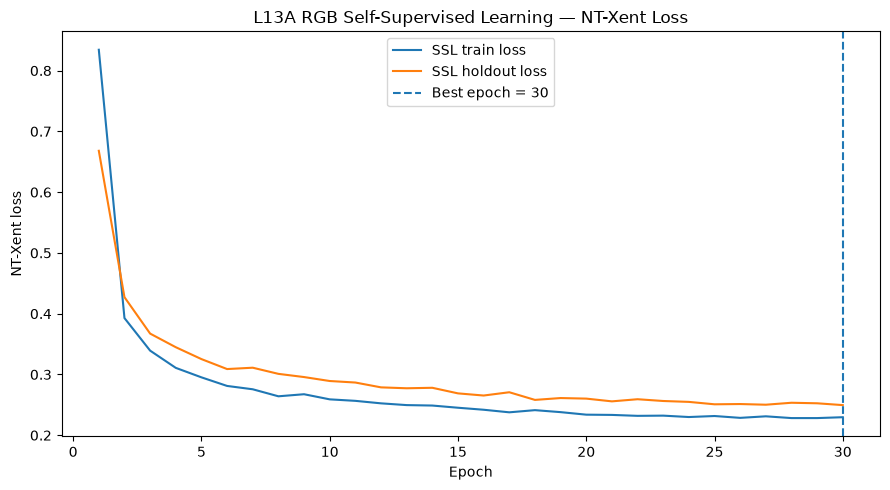


VISUAL SOURCE USAGE

FULL      :    37328 ( 20.46%)
CONTEXT   :    85937 ( 47.11%)
HAND0     :    45154 ( 24.76%)
HAND1     :    13981 (  7.67%)

FINAL DATA-LEAKAGE AUDIT

SSL train ∩ L9 validation   : 0
SSL train ∩ L9 test         : 0
SSL holdout ∩ L9 validation : 0
SSL holdout ∩ L9 test       : 0

L9 validation RGB used       : NO
L9 test RGB used             : NO
L9 test evaluated            : NO

L13A FINAL REPORT

VISUAL ENCODER
----------------------------------------------------------------------------------------------------------------------------------
Architecture                 : MobileNetV3-Small
ImageNet initialization      : YES
Input resolution             : 224x224
Visual embedding             : 576
Projection embedding         : 128
Parameters                   : 1,289,120

SELF-SUPERVISED DATA
----------------------------------------------------------------------------------------------------------------------------------
Available L6 raw videos      : 7050
Permiss

In [4]:
# ==================================================================================================
# CISLR MULTIMODAL MODEL — L13A
# LANDMARK-GUIDED RGB SELF-SUPERVISED VISUAL REPRESENTATION LEARNING
# COMPLETE CLEAN VERSION — AMP-SAFE
# ==================================================================================================
#
# PURPOSE
# -------
# Learn an RGB visual representation that complements the frozen L12B skeleton ST-GCN.
#
# DATA POLICY
# -----------
# L9 TRAIN      : allowed in SSL
# Other CISLR   : allowed in SSL
# L9 VALIDATION : EXCLUDED from SSL
# L9 TEST       : EXCLUDED / NEVER OPENED / NEVER DECODED
#
# PIPELINE
# --------
#
# CISLR RGB video
#      │
#      ├── L6 landmarks available ──> hand/context crop
#      │
#      └── landmarks unavailable ───> full RGB frame
#                         │
#                         ▼
#                MobileNetV3-Small
#                 ImageNet pretrained
#                         │
#                         ▼
#                   576-D feature
#                         │
#                         ▼
#                 projection head
#                         │
#                         ▼
#               SimCLR / NT-Xent SSL
#
# OUTPUT
# ------
# Best visual encoder for:
#   L13B -> RGB temporal classifier
#   L13C -> RGB + L12B skeleton fusion
#
# IMPORTANT
# ---------
# This stage does NOT perform 211-class classification.
# L9 test remains completely locked.
#
# ==================================================================================================


# ==================================================================================================
# 0. IMPORTS
# ==================================================================================================

import os
import cv2
import gc
import json
import time
import random
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights
)

warnings.filterwarnings("ignore")


# ==================================================================================================
# 1. REPRODUCIBILITY
# ==================================================================================================

SEED = 42


def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

torch.backends.cudnn.benchmark = True


# ==================================================================================================
# 2. DEVICE
# ==================================================================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"


print("=" * 130)
print("CISLR MULTIMODAL MODEL — L13A")
print("LANDMARK-GUIDED RGB SELF-SUPERVISED VISUAL REPRESENTATION LEARNING")
print("=" * 130)

print()
print("PyTorch version     :", torch.__version__)
print("Torchvision version :", torchvision.__version__)
print("Device              :", DEVICE)

if torch.cuda.is_available():
    print("GPU                 :", torch.cuda.get_device_name(0))

print("AMP                 :", USE_AMP)


# ==================================================================================================
# 3. PATHS
# ==================================================================================================

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)

MODEL_ROOT = (
    PROJECT_ROOT /
    "CISLR_LANDMARK_MODEL"
)

VIDEO_DIR = Path(
    "/home/dipshikha/Music/cao/CISLR_v1.5-a_videos"
)

RAW_DIR = (
    MODEL_ROOT /
    "audit" /
    "l6_full_extraction" /
    "raw_sequences"
)

L9_ROOT = (
    MODEL_ROOT /
    "audit" /
    "l9_split_freeze"
)

TRAIN_MANIFEST = (
    L9_ROOT /
    "splits" /
    "l9_train_manifest.csv"
)

VAL_MANIFEST = (
    L9_ROOT /
    "splits" /
    "l9_validation_manifest.csv"
)

TEST_MANIFEST = (
    L9_ROOT /
    "splits" /
    "l9_test_manifest.csv"
)


# --------------------------------------------------------------------------------------------------
# L13.0
# --------------------------------------------------------------------------------------------------

L130_ROOT = (
    MODEL_ROOT /
    "audit" /
    "l13_multimodal" /
    "l13_0_rgb_pipeline"
)

L130_CHECKPOINT = (
    L130_ROOT /
    "reports" /
    "l13_0_checkpoint.json"
)


# --------------------------------------------------------------------------------------------------
# L13A
# --------------------------------------------------------------------------------------------------

L13A_ROOT = (
    MODEL_ROOT /
    "audit" /
    "l13_multimodal" /
    "l13_a_visual"
)

MODEL_DIR = L13A_ROOT / "models"
REPORT_DIR = L13A_ROOT / "reports"
PLOT_DIR = L13A_ROOT / "plots"
AUDIT_DIR = L13A_ROOT / "audit"

for d in [
    L13A_ROOT,
    MODEL_DIR,
    REPORT_DIR,
    PLOT_DIR,
    AUDIT_DIR
]:
    d.mkdir(parents=True, exist_ok=True)


# ==================================================================================================
# 4. CONFIGURATION
# ==================================================================================================

IMAGE_SIZE = 224

VISUAL_EMBED_DIM = 576
PROJECTION_DIM = 128

SSL_EPOCHS = 30

BATCH_SIZE = 64

NUM_WORKERS = min(
    8,
    os.cpu_count() if os.cpu_count() is not None else 4
)

LR = 3e-4

WEIGHT_DECAY = 1e-4

TEMPERATURE = 0.15

GRAD_CLIP = 5.0

EARLY_STOP_PATIENCE = 8

SSL_HOLDOUT_FRACTION = 0.08


# --------------------------------------------------------------------------------------------------
# Visual-source probabilities
# --------------------------------------------------------------------------------------------------

P_CONTEXT = 0.50
P_HAND = 0.35
P_FULL = 0.15

assert abs(
    P_CONTEXT + P_HAND + P_FULL - 1.0
) < 1e-8


# --------------------------------------------------------------------------------------------------
# Prefer frames where hand landmarks exist, but still expose the network to full-frame cases.
# --------------------------------------------------------------------------------------------------

P_PREFER_DETECTED_FRAME = 0.85


# ==================================================================================================
# 5. REQUIRED FILE CHECK
# ==================================================================================================

required_paths = [
    VIDEO_DIR,
    RAW_DIR,
    TRAIN_MANIFEST,
    VAL_MANIFEST,
    TEST_MANIFEST,
    L130_CHECKPOINT
]


for p in required_paths:

    if not p.exists():
        raise FileNotFoundError(
            f"Required dependency missing:\n{p}"
        )


print()
print("[PASS] Required L6/L9/L13.0 paths exist.")


# ==================================================================================================
# 6. VERIFY L13.0
# ==================================================================================================

with open(L130_CHECKPOINT, "r") as f:
    l130_checkpoint = json.load(f)


if l130_checkpoint.get("status") != "PASS":

    raise RuntimeError(
        "L13.0 checkpoint is not PASS. "
        "Do not continue to L13A."
    )


print("[PASS] L13.0 checkpoint verified.")


# ==================================================================================================
# 7. LOAD FROZEN L9 SPLIT
# ==================================================================================================

train_df = pd.read_csv(TRAIN_MANIFEST)
val_df = pd.read_csv(VAL_MANIFEST)
test_df = pd.read_csv(TEST_MANIFEST)


for df in [train_df, val_df, test_df]:
    df["uid"] = df["uid"].astype(str)


assert len(train_df) == 585
assert len(val_df) == 211
assert len(test_df) == 211


train_uids = set(train_df["uid"])
val_uids = set(val_df["uid"])
test_uids = set(test_df["uid"])


assert train_uids.isdisjoint(val_uids)
assert train_uids.isdisjoint(test_uids)
assert val_uids.isdisjoint(test_uids)


print()
print("=" * 130)
print("FROZEN L9 SPLIT")
print("=" * 130)

print()
print("Train      :", len(train_uids))
print("Validation :", len(val_uids), "(EXCLUDED FROM SSL)")
print("Test       :", len(test_uids), "(LOCKED)")

print()
print("[PASS] Zero UID overlap.")


# ==================================================================================================
# 8. INDEX L6 RAW SEQUENCES
# ==================================================================================================

print()
print("=" * 130)
print("INDEXING L6 RAW SEQUENCES")
print("=" * 130)


raw_paths = sorted(
    RAW_DIR.glob("*.npz")
)

records = []
uid_to_raw = {}


for i, path in enumerate(raw_paths, start=1):

    try:

        with np.load(path, allow_pickle=True) as d:

            uid = str(d["uid"].item())

            gloss = (
                str(d["gloss"].item())
                if "gloss" in d.files
                else ""
            )

            video_path = (
                str(d["video_path"].item())
                if "video_path" in d.files
                else ""
            )


        if uid not in uid_to_raw:

            uid_to_raw[uid] = path

            records.append(
                {
                    "uid": uid,
                    "gloss": gloss,
                    "raw_path": str(path),
                    "video_path": video_path
                }
            )


    except Exception as e:

        print(
            "[WARNING]",
            path.name,
            ":",
            str(e)
        )


    if i % 1000 == 0 or i == len(raw_paths):

        print(
            f"  {i}/{len(raw_paths)}"
        )


all_raw_df = pd.DataFrame(records)


print()
print("Raw files found      :", len(raw_paths))
print("Unique UIDs indexed  :", len(all_raw_df))


if len(all_raw_df) != 7050:

    print(
        "[WARNING] Expected 7050 raw sequences but indexed",
        len(all_raw_df)
    )


# ==================================================================================================
# 9. RESOLVE ORIGINAL VIDEO PATHS WITHOUT OPENING VIDEOS
# ==================================================================================================

def resolve_video_path(row):

    stored = Path(
        str(row["video_path"])
    )


    if stored.exists():
        return str(stored)


    candidate = VIDEO_DIR / stored.name

    if candidate.exists():
        return str(candidate)


    candidate = VIDEO_DIR / f"{row['uid']}.mp4"

    if candidate.exists():
        return str(candidate)


    return None


all_raw_df["resolved_video_path"] = all_raw_df.apply(
    resolve_video_path,
    axis=1
)


missing_video_count = int(
    all_raw_df["resolved_video_path"].isna().sum()
)


print()
print("Missing video paths :", missing_video_count)


# ==================================================================================================
# 10. BUILD PERMISSIBLE SSL POPULATION
# ==================================================================================================
#
# CRITICAL:
#
# Validation/test are removed BEFORE Dataset construction.
#
# Therefore Dataset.__getitem__ cannot open those videos.
#
# ==================================================================================================

forbidden_uids = val_uids | test_uids


ssl_df = all_raw_df[
    ~all_raw_df["uid"].isin(forbidden_uids)
].copy()


ssl_df = ssl_df[
    ssl_df["resolved_video_path"].notna()
].copy()


ssl_df = ssl_df.reset_index(drop=True)


ssl_uids = set(ssl_df["uid"])


assert ssl_uids.isdisjoint(val_uids)
assert ssl_uids.isdisjoint(test_uids)


print()
print("=" * 130)
print("L13A PERMISSIBLE SSL POPULATION")
print("=" * 130)

print()

print("Available L6 videos       :", len(all_raw_df))
print("L9 validation excluded    :", len(val_uids))
print("L9 test excluded          :", len(test_uids))
print("Permissible SSL videos    :", len(ssl_df))

print()

print(
    "SSL ∩ validation          :",
    len(ssl_uids & val_uids)
)

print(
    "SSL ∩ test                :",
    len(ssl_uids & test_uids)
)

print()

print("[PASS] Validation/test excluded before RGB decoding.")


# ==================================================================================================
# 11. INTERNAL SSL HOLDOUT
# ==================================================================================================
#
# This is NOT L9 validation.
#
# We need a label-free internal SSL holdout to select the visual SSL checkpoint.
#
# ==================================================================================================

rng = np.random.default_rng(SEED)


indices = np.arange(
    len(ssl_df)
)


rng.shuffle(indices)


n_holdout = max(
    1,
    int(
        round(
            len(indices) *
            SSL_HOLDOUT_FRACTION
        )
    )
)


holdout_indices = indices[:n_holdout]
ssl_train_indices = indices[n_holdout:]


ssl_train_df = (
    ssl_df
    .iloc[ssl_train_indices]
    .reset_index(drop=True)
)


ssl_holdout_df = (
    ssl_df
    .iloc[holdout_indices]
    .reset_index(drop=True)
)


assert set(
    ssl_train_df["uid"]
).isdisjoint(
    set(ssl_holdout_df["uid"])
)


assert set(
    ssl_train_df["uid"]
).isdisjoint(val_uids)


assert set(
    ssl_train_df["uid"]
).isdisjoint(test_uids)


assert set(
    ssl_holdout_df["uid"]
).isdisjoint(val_uids)


assert set(
    ssl_holdout_df["uid"]
).isdisjoint(test_uids)


print()
print("SSL training videos :", len(ssl_train_df))
print("SSL holdout videos  :", len(ssl_holdout_df))


# ==================================================================================================
# 12. IMAGE AUGMENTATION
# ==================================================================================================

ssl_transform = transforms.Compose(
    [
        transforms.ToPILImage(),

        transforms.RandomResizedCrop(
            IMAGE_SIZE,
            scale=(0.70, 1.00),
            ratio=(0.85, 1.15)
        ),

        transforms.RandomHorizontalFlip(
            p=0.50
        ),

        transforms.RandomApply(
            [
                transforms.ColorJitter(
                    brightness=0.25,
                    contrast=0.25,
                    saturation=0.20,
                    hue=0.04
                )
            ],
            p=0.70
        ),

        transforms.RandomGrayscale(
            p=0.08
        ),

        transforms.RandomApply(
            [
                transforms.GaussianBlur(
                    kernel_size=5,
                    sigma=(0.1, 1.5)
                )
            ],
            p=0.20
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ]
)


eval_transform = transforms.Compose(
    [
        transforms.ToPILImage(),

        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ]
)


# ==================================================================================================
# 13. LANDMARK / CROP UTILITIES
# ==================================================================================================

def clip_box(
    box,
    width,
    height
):

    x1, y1, x2, y2 = box


    x1 = int(
        np.clip(
            round(x1),
            0,
            max(width - 1, 0)
        )
    )

    y1 = int(
        np.clip(
            round(y1),
            0,
            max(height - 1, 0)
        )
    )

    x2 = int(
        np.clip(
            round(x2),
            x1 + 1,
            width
        )
    )

    y2 = int(
        np.clip(
            round(y2),
            y1 + 1,
            height
        )
    )


    return x1, y1, x2, y2


def square_box_from_points(
    points_xy,
    width,
    height,
    scale=1.60,
    minimum_size=32
):

    points_xy = np.asarray(
        points_xy,
        dtype=np.float32
    )


    finite = np.isfinite(
        points_xy
    ).all(axis=1)


    points_xy = points_xy[finite]


    if len(points_xy) == 0:
        return None


    xmin = float(points_xy[:, 0].min())
    xmax = float(points_xy[:, 0].max())

    ymin = float(points_xy[:, 1].min())
    ymax = float(points_xy[:, 1].max())


    cx = (xmin + xmax) / 2.0
    cy = (ymin + ymax) / 2.0


    side = max(
        xmax - xmin,
        ymax - ymin,
        float(minimum_size)
    )


    side *= scale


    return clip_box(
        (
            cx - side / 2.0,
            cy - side / 2.0,
            cx + side / 2.0,
            cy + side / 2.0
        ),
        width,
        height
    )


def build_context_box(
    landmarks,
    mask,
    width,
    height
):

    points = []


    for hand_idx in range(2):

        if mask[hand_idx] <= 0:
            continue


        pts = landmarks[
            hand_idx,
            :,
            :2
        ]


        finite = np.isfinite(
            pts
        ).all(axis=1)


        pts = pts[finite]


        if len(pts) > 0:
            points.append(pts)


    if len(points) == 0:
        return None


    points = np.concatenate(
        points,
        axis=0
    )


    return square_box_from_points(
        points,
        width,
        height,
        scale=1.50,
        minimum_size=96
    )


# ==================================================================================================
# 14. RGB FRAME DECODER
# ==================================================================================================

def decode_frame(
    video_path,
    frame_number
):

    cap = cv2.VideoCapture(
        str(video_path)
    )


    if not cap.isOpened():

        cap.release()
        return None


    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        int(frame_number)
    )


    ok, frame = cap.read()

    cap.release()


    if not ok or frame is None:
        return None


    frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )


    return frame


# ==================================================================================================
# 15. LANDMARK-GUIDED VISUAL SOURCE
# ==================================================================================================

def get_visual_source(
    frame,
    landmarks,
    mask,
    rng_obj
):

    height, width = frame.shape[:2]


    valid_hands = [
        h
        for h in range(2)
        if mask[h] > 0
    ]


    context_box = build_context_box(
        landmarks,
        mask,
        width,
        height
    )


    r = rng_obj.random()

    box = None
    source = "FULL"


    # --------------------------------------------------------------------------------------------------
    # Context crop
    # --------------------------------------------------------------------------------------------------

    if (
        r < P_CONTEXT
        and
        context_box is not None
    ):

        box = context_box
        source = "CONTEXT"


    # --------------------------------------------------------------------------------------------------
    # Individual hand crop
    # --------------------------------------------------------------------------------------------------

    elif (
        r < P_CONTEXT + P_HAND
        and
        len(valid_hands) > 0
    ):

        hand_idx = int(
            rng_obj.choice(valid_hands)
        )


        box = square_box_from_points(
            landmarks[
                hand_idx,
                :,
                :2
            ],
            width,
            height,
            scale=1.60,
            minimum_size=32
        )


        if box is not None:
            source = f"HAND{hand_idx}"


    # --------------------------------------------------------------------------------------------------
    # Full frame
    # --------------------------------------------------------------------------------------------------

    if box is None:

        return frame, "FULL"


    x1, y1, x2, y2 = box


    crop = frame[
        y1:y2,
        x1:x2
    ]


    if (
        crop.size == 0
        or
        crop.shape[0] < 8
        or
        crop.shape[1] < 8
    ):

        return frame, "FULL"


    return crop, source


# ==================================================================================================
# 16. SSL DATASET
# ==================================================================================================

class CISLRVisualSSLDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform,
        seed=42
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

        self.seed = int(seed)

        self.epoch = 0


    def set_epoch(
        self,
        epoch
    ):

        self.epoch = int(epoch)


    def __len__(self):

        return len(self.df)


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[index]


        uid = str(row["uid"])


        # ==========================================================================================
        # HARD LEAKAGE GUARD
        # ==========================================================================================

        if uid in val_uids:

            raise RuntimeError(
                f"L9 validation UID reached SSL loader: {uid}"
            )


        if uid in test_uids:

            raise RuntimeError(
                f"L9 test UID reached SSL loader: {uid}"
            )


        raw_path = Path(
            row["raw_path"]
        )


        video_path = Path(
            row["resolved_video_path"]
        )


        # ==========================================================================================
        # REPRODUCIBLE FRAME SAMPLING
        # ==========================================================================================

        uid_hash = int(
            hashlib.sha256(
                uid.encode("utf-8")
            ).hexdigest()[:8],
            16
        )


        local_seed = (
            self.seed
            +
            self.epoch * 1_000_003
            +
            uid_hash
        ) % (2**32 - 1)


        rng_obj = np.random.default_rng(
            local_seed
        )


        # ==========================================================================================
        # LOAD LANDMARK METADATA
        # ==========================================================================================

        with np.load(
            raw_path,
            allow_pickle=True
        ) as d:

            frame_numbers = d[
                "frame_numbers"
            ].astype(np.int64)

            landmarks = d[
                "landmarks_px"
            ].astype(np.float32)

            hand_mask = d[
                "hand_mask"
            ].astype(np.uint8)


        T = len(frame_numbers)


        if T == 0:

            raise RuntimeError(
                f"Empty sequence: {uid}"
            )


        if landmarks.shape[:2] != (T, 2):

            raise RuntimeError(
                f"Unexpected landmark shape for {uid}: "
                f"{landmarks.shape}"
            )


        if hand_mask.shape != (T, 2):

            raise RuntimeError(
                f"Unexpected hand mask shape for {uid}: "
                f"{hand_mask.shape}"
            )


        # ==========================================================================================
        # SELECT SOURCE FRAME
        # ==========================================================================================

        detected_positions = np.where(
            hand_mask.any(axis=1)
        )[0]


        prefer_detected = (
            len(detected_positions) > 0
            and
            rng_obj.random() <
            P_PREFER_DETECTED_FRAME
        )


        if prefer_detected:

            pos = int(
                rng_obj.choice(
                    detected_positions
                )
            )

        else:

            pos = int(
                rng_obj.integers(
                    0,
                    T
                )
            )


        # ==========================================================================================
        # DECODE FRAME
        # ==========================================================================================

        frame = decode_frame(
            video_path,
            int(frame_numbers[pos])
        )


        # --------------------------------------------------------------------------------------------------
        # Neighbor fallback
        # --------------------------------------------------------------------------------------------------

        if frame is None:

            decoded = False


            for offset in [
                -1,
                1,
                -2,
                2,
                -3,
                3
            ]:

                p2 = int(
                    np.clip(
                        pos + offset,
                        0,
                        T - 1
                    )
                )


                frame = decode_frame(
                    video_path,
                    int(frame_numbers[p2])
                )


                if frame is not None:

                    pos = p2
                    decoded = True
                    break


            if not decoded:

                raise RuntimeError(
                    f"Could not decode RGB frame for UID {uid}"
                )


        # ==========================================================================================
        # LANDMARK-GUIDED CROP
        # ==========================================================================================

        crop, source_type = get_visual_source(
            frame,
            landmarks[pos],
            hand_mask[pos],
            rng_obj
        )


        # ==========================================================================================
        # TWO CONTRASTIVE VIEWS
        # ==========================================================================================

        view1 = self.transform(crop)
        view2 = self.transform(crop)


        source_id = {
            "FULL": 0,
            "CONTEXT": 1,
            "HAND0": 2,
            "HAND1": 3
        }[source_type]


        return (
            view1,
            view2,
            source_id
        )


# ==================================================================================================
# 17. DATASETS
# ==================================================================================================

ssl_train_dataset = CISLRVisualSSLDataset(
    ssl_train_df,
    ssl_transform,
    seed=SEED
)


ssl_holdout_dataset = CISLRVisualSSLDataset(
    ssl_holdout_df,
    ssl_transform,
    seed=SEED + 100
)


# ==================================================================================================
# 18. DATA LOADERS
# ==================================================================================================

loader_common = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": USE_AMP,
    "persistent_workers": False
}


ssl_train_loader = DataLoader(
    ssl_train_dataset,
    shuffle=True,
    drop_last=True,
    **loader_common
)


ssl_holdout_loader = DataLoader(
    ssl_holdout_dataset,
    shuffle=False,
    drop_last=False,
    **loader_common
)


print()
print("=" * 130)
print("L13A DATA LOADERS")
print("=" * 130)

print()
print("SSL train videos    :", len(ssl_train_dataset))
print("SSL holdout videos  :", len(ssl_holdout_dataset))
print("Batch size          :", BATCH_SIZE)
print("Workers             :", NUM_WORKERS)


# ==================================================================================================
# 19. PRETRAINED MOBILENETV3-SMALL
# ==================================================================================================

print()
print("=" * 130)
print("LOADING VISUAL BACKBONE")
print("=" * 130)


try:

    weights = (
        MobileNet_V3_Small_Weights.IMAGENET1K_V1
    )


    backbone = mobilenet_v3_small(
        weights=weights
    )


    pretrained_loaded = True


except Exception as e:

    print()
    print("[ERROR] Could not load ImageNet weights.")
    print("Reason:", str(e))

    raise RuntimeError(
        "L13A requires the intended ImageNet-pretrained "
        "MobileNetV3-Small initialization. "
        "Do not silently continue with random weights."
    )


print()
print("[PASS] ImageNet-pretrained MobileNetV3-Small loaded.")


# ==================================================================================================
# 20. MODEL
# ==================================================================================================

class VisualEncoder(nn.Module):

    def __init__(
        self,
        backbone
    ):

        super().__init__()

        self.features = backbone.features

        self.avgpool = nn.AdaptiveAvgPool2d(1)


    def forward(
        self,
        x
    ):

        x = self.features(x)

        x = self.avgpool(x)

        x = torch.flatten(
            x,
            1
        )

        return x


class VisualSSLModel(nn.Module):

    def __init__(
        self,
        backbone,
        projection_dim=128
    ):

        super().__init__()


        self.encoder = VisualEncoder(
            backbone
        )


        self.projector = nn.Sequential(

            nn.Linear(
                VISUAL_EMBED_DIM,
                512
            ),

            nn.BatchNorm1d(
                512
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                512,
                projection_dim
            )
        )


    def forward(
        self,
        x
    ):

        h = self.encoder(x)

        z = self.projector(h)

        z = F.normalize(
            z,
            dim=1
        )

        return h, z


# ==================================================================================================
# 21. CLEAN MODEL INITIALIZATION
# ==================================================================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


seed_everything(SEED)


# Re-create pretrained backbone so no state from the crashed run survives.

backbone = mobilenet_v3_small(
    weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1
)


model = VisualSSLModel(
    backbone,
    PROJECTION_DIM
).to(DEVICE)


total_params = sum(
    p.numel()
    for p in model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print()
print("=" * 130)
print("L13A MODEL")
print("=" * 130)

print()
print(model)

print()
print("Architecture             : MobileNetV3-Small")
print("ImageNet pretrained      : YES")
print("Visual embedding         :", VISUAL_EMBED_DIM)
print("Projection dimension     :", PROJECTION_DIM)
print("Parameters               :", f"{total_params:,}")
print("Trainable parameters     :", f"{trainable_params:,}")


# ==================================================================================================
# 22. AMP-SAFE NT-XENT LOSS
# ==================================================================================================
#
# IMPORTANT FIX
# -------------
#
# The CNN can run under mixed precision.
#
# BUT contrastive similarity is explicitly converted to FP32 before:
#
#       masked_fill(..., -inf)
#
# This avoids:
#
# RuntimeError:
# value cannot be converted to type c10::Half without overflow
#
# ==================================================================================================

def nt_xent_loss(
    z1,
    z2,
    temperature=0.15
):

    B = z1.size(0)


    if B < 2:

        raise RuntimeError(
            "NT-Xent requires batch size >= 2."
        )


    # --------------------------------------------------------------------------------------------------
    # Numerically sensitive portion in FP32.
    # --------------------------------------------------------------------------------------------------

    z1 = F.normalize(
        z1.float(),
        dim=1
    )

    z2 = F.normalize(
        z2.float(),
        dim=1
    )


    z = torch.cat(
        [z1, z2],
        dim=0
    )


    similarity = torch.matmul(
        z,
        z.T
    )


    similarity = (
        similarity /
        float(temperature)
    )


    self_mask = torch.eye(
        2 * B,
        device=z.device,
        dtype=torch.bool
    )


    similarity = similarity.masked_fill(
        self_mask,
        float("-inf")
    )


    targets = torch.arange(
        2 * B,
        device=z.device
    )


    targets = (
        targets + B
    ) % (2 * B)


    loss = F.cross_entropy(
        similarity,
        targets
    )


    return loss


# ==================================================================================================
# 23. NUMERICAL LOSS SANITY TEST
# ==================================================================================================

_test_z1 = torch.randn(
    64,
    PROJECTION_DIM,
    device=DEVICE
)

_test_z2 = torch.randn(
    64,
    PROJECTION_DIM,
    device=DEVICE
)


with torch.no_grad():

    _test_loss = nt_xent_loss(
        _test_z1,
        _test_z2,
        TEMPERATURE
    )


print()
print("=" * 130)
print("AMP-SAFE NT-XENT SANITY TEST")
print("=" * 130)

print()
print(
    "Random-pair loss :",
    float(_test_loss)
)

print(
    "Finite           :",
    bool(
        torch.isfinite(
            _test_loss
        )
    )
)


assert torch.isfinite(_test_loss)


print()
print("[PASS] AMP-safe NT-Xent loss.")


del _test_z1
del _test_z2
del _test_loss


# ==================================================================================================
# 24. OPTIMIZER / SCHEDULER / AMP
# ==================================================================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=SSL_EPOCHS,
    eta_min=1e-6
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)


# ==================================================================================================
# 25. TRAIN / EVALUATE ONE SSL EPOCH
# ==================================================================================================

def run_ssl_epoch(
    loader,
    training=True
):

    if training:
        model.train()

    else:
        model.eval()


    total_loss = 0.0
    total_samples = 0


    source_counts = np.zeros(
        4,
        dtype=np.int64
    )


    for (
        view1,
        view2,
        source_id
    ) in loader:


        view1 = view1.to(
            DEVICE,
            non_blocking=True
        )


        view2 = view2.to(
            DEVICE,
            non_blocking=True
        )


        source_np = source_id.numpy()


        for source_idx in range(4):

            source_counts[source_idx] += int(
                np.sum(
                    source_np == source_idx
                )
            )


        batch_n = view1.size(0)


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        with torch.set_grad_enabled(training):

            with torch.amp.autocast(
                device_type="cuda",
                enabled=USE_AMP
            ):

                _, z1 = model(view1)
                _, z2 = model(view2)


            # ======================================================================================
            # IMPORTANT:
            # NT-Xent internally converts embeddings to FP32.
            # ======================================================================================

            loss = nt_xent_loss(
                z1,
                z2,
                TEMPERATURE
            )


            if not torch.isfinite(loss):

                raise RuntimeError(
                    "Non-finite L13A SSL loss detected."
                )


            if training:

                scaler.scale(
                    loss
                ).backward()


                scaler.unscale_(
                    optimizer
                )


                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRAD_CLIP
                )


                scaler.step(
                    optimizer
                )


                scaler.update()


        total_loss += (
            float(loss.item()) *
            batch_n
        )


        total_samples += batch_n


    mean_loss = (
        total_loss /
        max(total_samples, 1)
    )


    return (
        mean_loss,
        source_counts
    )


# ==================================================================================================
# 26. OUTPUT PATHS
# ==================================================================================================

BEST_MODEL_PATH = (
    MODEL_DIR /
    "l13a_best_visual_encoder.pt"
)

LAST_MODEL_PATH = (
    MODEL_DIR /
    "l13a_last_visual_encoder.pt"
)

HISTORY_PATH = (
    REPORT_DIR /
    "l13a_ssl_training_history.csv"
)

TRAIN_SSL_MANIFEST_PATH = (
    REPORT_DIR /
    "l13a_ssl_train_manifest.csv"
)

HOLDOUT_SSL_MANIFEST_PATH = (
    REPORT_DIR /
    "l13a_ssl_holdout_manifest.csv"
)

SUMMARY_PATH = (
    REPORT_DIR /
    "l13a_summary.json"
)

CHECKPOINT_PATH = (
    REPORT_DIR /
    "l13a_checkpoint.json"
)

LOSS_PLOT_PATH = (
    PLOT_DIR /
    "l13a_ssl_loss.png"
)


# ==================================================================================================
# 27. SAVE SSL POPULATION MANIFESTS BEFORE TRAINING
# ==================================================================================================

ssl_train_df[
    [
        "uid",
        "raw_path",
        "resolved_video_path"
    ]
].to_csv(
    TRAIN_SSL_MANIFEST_PATH,
    index=False
)


ssl_holdout_df[
    [
        "uid",
        "raw_path",
        "resolved_video_path"
    ]
].to_csv(
    HOLDOUT_SSL_MANIFEST_PATH,
    index=False
)


# ==================================================================================================
# 28. TRAINING
# ==================================================================================================

print()
print("=" * 130)
print("STARTING L13A SSL TRAINING")
print("=" * 130)

print()

print("SSL train videos       :", len(ssl_train_dataset))
print("SSL holdout videos     :", len(ssl_holdout_dataset))

print()

print("Architecture           : MobileNetV3-Small")
print("ImageNet pretrained    : YES")
print("Epochs                 :", SSL_EPOCHS)
print("Batch size             :", BATCH_SIZE)
print("Learning rate          :", LR)
print("Weight decay           :", WEIGHT_DECAY)
print("Temperature            :", TEMPERATURE)
print("AMP                     :", USE_AMP)

print()

print("L9 validation in SSL   : 0")
print("L9 test in SSL         : 0")

print()


history = []


best_holdout_loss = float("inf")
best_epoch = -1

epochs_without_improvement = 0


training_start = time.time()


for epoch in range(
    1,
    SSL_EPOCHS + 1
):

    epoch_start = time.time()


    # --------------------------------------------------------------------------------------------------
    # Train frame selection changes each epoch.
    # --------------------------------------------------------------------------------------------------

    ssl_train_dataset.set_epoch(epoch)


    # --------------------------------------------------------------------------------------------------
    # Holdout frame selection stays fixed.
    # --------------------------------------------------------------------------------------------------

    ssl_holdout_dataset.set_epoch(0)


    train_loss, train_sources = run_ssl_epoch(
        ssl_train_loader,
        training=True
    )


    with torch.no_grad():

        holdout_loss, holdout_sources = run_ssl_epoch(
            ssl_holdout_loader,
            training=False
        )


    current_lr = optimizer.param_groups[0]["lr"]


    elapsed = time.time() - epoch_start


    improved = (
        holdout_loss <
        best_holdout_loss - 1e-5
    )


    if improved:

        best_holdout_loss = float(
            holdout_loss
        )

        best_epoch = int(epoch)

        epochs_without_improvement = 0


        torch.save(
            {
                "stage":
                    "L13A",

                "epoch":
                    best_epoch,

                "architecture":
                    "MobileNetV3-Small",

                "imagenet_pretrained":
                    True,

                "encoder_state_dict":
                    model.encoder.state_dict(),

                "projector_state_dict":
                    model.projector.state_dict(),

                "full_model_state_dict":
                    model.state_dict(),

                "visual_embedding_dim":
                    VISUAL_EMBED_DIM,

                "projection_dim":
                    PROJECTION_DIM,

                "image_size":
                    IMAGE_SIZE,

                "temperature":
                    TEMPERATURE,

                "best_holdout_loss":
                    best_holdout_loss,

                "ssl_train_videos":
                    len(ssl_train_dataset),

                "ssl_holdout_videos":
                    len(ssl_holdout_dataset),

                "l9_validation_used":
                    False,

                "l9_test_used":
                    False,

                "seed":
                    SEED
            },

            BEST_MODEL_PATH
        )


    else:

        epochs_without_improvement += 1


    history.append(
        {
            "epoch":
                epoch,

            "train_loss":
                float(train_loss),

            "holdout_loss":
                float(holdout_loss),

            "learning_rate":
                float(current_lr),

            "train_full":
                int(train_sources[0]),

            "train_context":
                int(train_sources[1]),

            "train_hand0":
                int(train_sources[2]),

            "train_hand1":
                int(train_sources[3]),

            "holdout_full":
                int(holdout_sources[0]),

            "holdout_context":
                int(holdout_sources[1]),

            "holdout_hand0":
                int(holdout_sources[2]),

            "holdout_hand1":
                int(holdout_sources[3]),

            "seconds":
                float(elapsed),

            "best":
                bool(improved)
        }
    )


    marker = (
        "  <-- BEST"
        if improved
        else ""
    )


    print(
        f"Epoch {epoch:03d}/{SSL_EPOCHS} | "
        f"train={train_loss:.5f} | "
        f"holdout={holdout_loss:.5f} | "
        f"lr={current_lr:.2e} | "
        f"{elapsed:.1f}s"
        f"{marker}"
    )


    scheduler.step()


    if (
        epochs_without_improvement >=
        EARLY_STOP_PATIENCE
    ):

        print()
        print("[EARLY STOPPING]")

        print(
            "No SSL holdout-loss improvement for",
            EARLY_STOP_PATIENCE,
            "epochs."
        )

        break


# ==================================================================================================
# 29. TRAINING TIME
# ==================================================================================================

total_training_time = (
    time.time() -
    training_start
)


# ==================================================================================================
# 30. SAVE LAST MODEL
# ==================================================================================================

torch.save(
    {
        "stage":
            "L13A",

        "epoch":
            int(epoch),

        "architecture":
            "MobileNetV3-Small",

        "imagenet_pretrained":
            True,

        "encoder_state_dict":
            model.encoder.state_dict(),

        "projector_state_dict":
            model.projector.state_dict(),

        "full_model_state_dict":
            model.state_dict(),

        "visual_embedding_dim":
            VISUAL_EMBED_DIM,

        "projection_dim":
            PROJECTION_DIM,

        "image_size":
            IMAGE_SIZE,

        "l9_validation_used":
            False,

        "l9_test_used":
            False
    },

    LAST_MODEL_PATH
)


# ==================================================================================================
# 31. SAVE HISTORY
# ==================================================================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    HISTORY_PATH,
    index=False
)


# ==================================================================================================
# 32. VERIFY BEST CHECKPOINT
# ==================================================================================================

if not BEST_MODEL_PATH.exists():

    raise RuntimeError(
        "Best L13A checkpoint was not created."
    )


best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)


model.encoder.load_state_dict(
    best_checkpoint[
        "encoder_state_dict"
    ]
)


model.eval()


print()
print("=" * 130)
print("BEST L13A SSL CHECKPOINT")
print("=" * 130)

print()
print("Best epoch        :", best_epoch)
print("Best holdout loss :", f"{best_holdout_loss:.6f}")
print("Training time     :", f"{total_training_time:.2f} sec")


# ==================================================================================================
# 33. REPRESENTATION SANITY AUDIT
# ==================================================================================================

print()
print("=" * 130)
print("VISUAL EMBEDDING SANITY AUDIT")
print("=" * 130)


sample_embeddings = []


ssl_holdout_dataset.set_epoch(0)


with torch.no_grad():

    audit_n = min(
        128,
        len(ssl_holdout_dataset)
    )


    for i in range(audit_n):

        view1, _, _ = ssl_holdout_dataset[i]


        x = view1.unsqueeze(0).to(
            DEVICE
        )


        with torch.amp.autocast(
            device_type="cuda",
            enabled=USE_AMP
        ):

            emb = model.encoder(x)


        emb = emb.float()


        sample_embeddings.append(
            emb.cpu().numpy()[0]
        )


sample_embeddings = np.asarray(
    sample_embeddings,
    dtype=np.float32
)


finite_embeddings = bool(
    np.isfinite(
        sample_embeddings
    ).all()
)


embedding_mean_std = float(
    sample_embeddings
    .std(axis=0)
    .mean()
)


global_embedding_std = float(
    sample_embeddings.std()
)


unique_embedding_rows = int(
    np.unique(
        np.round(
            sample_embeddings,
            decimals=5
        ),
        axis=0
    ).shape[0]
)


noncollapsed = bool(
    embedding_mean_std > 1e-4
)


print()
print("Embedding shape          :", sample_embeddings.shape)
print("All finite               :", finite_embeddings)
print("Mean per-dim std         :", f"{embedding_mean_std:.6f}")
print("Global embedding std     :", f"{global_embedding_std:.6f}")

print(
    "Unique embedding rows    :",
    f"{unique_embedding_rows}/{len(sample_embeddings)}"
)

print(
    "Representation collapsed :",
    "NO" if noncollapsed else "YES"
)


# ==================================================================================================
# 34. LOSS CURVE
# ==================================================================================================

plt.figure(
    figsize=(9, 5)
)


plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="SSL train loss"
)


plt.plot(
    history_df["epoch"],
    history_df["holdout_loss"],
    label="SSL holdout loss"
)


plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)


plt.xlabel("Epoch")
plt.ylabel("NT-Xent loss")

plt.title(
    "L13A RGB Self-Supervised Learning — NT-Xent Loss"
)

plt.legend()

plt.tight_layout()


plt.savefig(
    LOSS_PLOT_PATH,
    dpi=160
)

plt.show()


# ==================================================================================================
# 35. SOURCE USAGE
# ==================================================================================================

source_totals = {
    "FULL":
        int(
            history_df[
                "train_full"
            ].sum()
        ),

    "CONTEXT":
        int(
            history_df[
                "train_context"
            ].sum()
        ),

    "HAND0":
        int(
            history_df[
                "train_hand0"
            ].sum()
        ),

    "HAND1":
        int(
            history_df[
                "train_hand1"
            ].sum()
        )
}


source_total_n = sum(
    source_totals.values()
)


print()
print("=" * 130)
print("VISUAL SOURCE USAGE")
print("=" * 130)

print()


for source_name, count in source_totals.items():

    percentage = (
        100.0 *
        count /
        max(source_total_n, 1)
    )


    print(
        f"{source_name:<10}: "
        f"{count:>8} "
        f"({percentage:6.2f}%)"
    )


# ==================================================================================================
# 36. FINAL LEAKAGE AUDIT
# ==================================================================================================

ssl_train_uids_final = set(
    ssl_train_df["uid"]
)

ssl_holdout_uids_final = set(
    ssl_holdout_df["uid"]
)


train_val_overlap = (
    ssl_train_uids_final &
    val_uids
)

train_test_overlap = (
    ssl_train_uids_final &
    test_uids
)

holdout_val_overlap = (
    ssl_holdout_uids_final &
    val_uids
)

holdout_test_overlap = (
    ssl_holdout_uids_final &
    test_uids
)


print()
print("=" * 130)
print("FINAL DATA-LEAKAGE AUDIT")
print("=" * 130)

print()

print(
    "SSL train ∩ L9 validation   :",
    len(train_val_overlap)
)

print(
    "SSL train ∩ L9 test         :",
    len(train_test_overlap)
)

print(
    "SSL holdout ∩ L9 validation :",
    len(holdout_val_overlap)
)

print(
    "SSL holdout ∩ L9 test       :",
    len(holdout_test_overlap)
)

print()

print("L9 validation RGB used       : NO")
print("L9 test RGB used             : NO")
print("L9 test evaluated            : NO")


# ==================================================================================================
# 37. PASS CONDITIONS
# ==================================================================================================

pass_conditions = {

    "l13_0_passed":
        l130_checkpoint.get("status") == "PASS",

    "l9_train_count":
        len(train_df) == 585,

    "l9_validation_count":
        len(val_df) == 211,

    "l9_test_count":
        len(test_df) == 211,

    "frozen_split_disjoint":
        (
            train_uids.isdisjoint(val_uids)
            and
            train_uids.isdisjoint(test_uids)
            and
            val_uids.isdisjoint(test_uids)
        ),

    "ssl_population_nonempty":
        len(ssl_df) > 0,

    "ssl_train_nonempty":
        len(ssl_train_df) > 0,

    "ssl_holdout_nonempty":
        len(ssl_holdout_df) > 0,

    "ssl_train_holdout_disjoint":
        ssl_train_uids_final.isdisjoint(
            ssl_holdout_uids_final
        ),

    "validation_excluded_from_ssl":
        (
            len(train_val_overlap) == 0
            and
            len(holdout_val_overlap) == 0
        ),

    "test_excluded_from_ssl":
        (
            len(train_test_overlap) == 0
            and
            len(holdout_test_overlap) == 0
        ),

    "imagenet_pretrained":
        pretrained_loaded is True,

    "best_checkpoint_exists":
        BEST_MODEL_PATH.exists(),

    "finite_best_ssl_loss":
        bool(
            np.isfinite(
                best_holdout_loss
            )
        ),

    "finite_embeddings":
        finite_embeddings,

    "noncollapsed_embeddings":
        noncollapsed
}


overall_pass = all(
    pass_conditions.values()
)


# ==================================================================================================
# 38. SUMMARY JSON
# ==================================================================================================

summary = {

    "stage":
        "L13A",

    "description":
        (
            "Landmark-guided RGB self-supervised "
            "visual representation learning"
        ),

    "architecture":
        "MobileNetV3-Small",

    "imagenet_pretrained":
        True,

    "image_size":
        IMAGE_SIZE,

    "visual_embedding_dim":
        VISUAL_EMBED_DIM,

    "projection_dim":
        PROJECTION_DIM,

    "parameters":
        int(total_params),

    "ssl_population": {

        "available_l6_raw_videos":
            int(len(all_raw_df)),

        "permissible_videos":
            int(len(ssl_df)),

        "train_videos":
            int(len(ssl_train_df)),

        "internal_holdout_videos":
            int(len(ssl_holdout_df)),

        "l9_validation_excluded":
            int(len(val_df)),

        "l9_test_excluded":
            int(len(test_df))
    },

    "training": {

        "epochs_requested":
            SSL_EPOCHS,

        "epochs_completed":
            int(len(history_df)),

        "best_epoch":
            int(best_epoch),

        "best_holdout_loss":
            float(best_holdout_loss),

        "initial_learning_rate":
            LR,

        "weight_decay":
            WEIGHT_DECAY,

        "temperature":
            TEMPERATURE,

        "batch_size":
            BATCH_SIZE,

        "amp":
            USE_AMP,

        "training_seconds":
            float(total_training_time)
    },

    "representation_audit": {

        "embedding_shape":
            list(sample_embeddings.shape),

        "finite":
            finite_embeddings,

        "mean_per_dimension_std":
            embedding_mean_std,

        "global_std":
            global_embedding_std,

        "unique_embedding_rows":
            unique_embedding_rows,

        "collapsed":
            not noncollapsed
    },

    "visual_source_usage":
        source_totals,

    "test_integrity": {

        "test_manifest_verified":
            True,

        "test_in_ssl":
            False,

        "test_rgb_opened":
            False,

        "test_rgb_decoded":
            False,

        "test_evaluated":
            False,

        "status":
            "LOCKED"
    },

    "pass_conditions": {
        k: bool(v)
        for k, v in pass_conditions.items()
    },

    "overall_pass":
        bool(overall_pass)
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ==================================================================================================
# 39. CHECKPOINT JSON
# ==================================================================================================

checkpoint = {

    "stage":
        "L13A",

    "status":
        "PASS" if overall_pass else "FAIL",

    "best_visual_encoder":
        str(BEST_MODEL_PATH),

    "best_epoch":
        int(best_epoch),

    "best_ssl_holdout_loss":
        float(best_holdout_loss),

    "visual_embedding_dim":
        VISUAL_EMBED_DIM,

    "l9_validation_used_for_ssl":
        False,

    "l9_test_used":
        False,

    "test_locked":
        True,

    "next_stage":
        (
            "L13B RGB-only temporal classifier"
            if overall_pass
            else
            "Resolve L13A failure before L13B"
        )
}


with open(
    CHECKPOINT_PATH,
    "w"
) as f:

    json.dump(
        checkpoint,
        f,
        indent=2
    )


# ==================================================================================================
# 40. FINAL REPORT
# ==================================================================================================

print()
print("=" * 130)
print("L13A FINAL REPORT")
print("=" * 130)


print()
print("VISUAL ENCODER")
print("-" * 130)

print("Architecture                 : MobileNetV3-Small")
print("ImageNet initialization      : YES")
print("Input resolution             :", f"{IMAGE_SIZE}x{IMAGE_SIZE}")
print("Visual embedding             :", VISUAL_EMBED_DIM)
print("Projection embedding         :", PROJECTION_DIM)
print("Parameters                   :", f"{total_params:,}")


print()
print("SELF-SUPERVISED DATA")
print("-" * 130)

print("Available L6 raw videos      :", len(all_raw_df))
print("Permissible SSL videos       :", len(ssl_df))
print("SSL training videos          :", len(ssl_train_df))
print("Internal SSL holdout         :", len(ssl_holdout_df))
print("L9 validation used           : 0")
print("L9 test used                 : 0")


print()
print("TRAINING")
print("-" * 130)

print("Objective                    : SimCLR / NT-Xent")
print("AMP-safe contrastive loss    : YES")
print("Temperature                  :", TEMPERATURE)
print("Initial LR                   :", LR)
print("Weight decay                 :", WEIGHT_DECAY)
print("Batch size                   :", BATCH_SIZE)
print("Epochs completed             :", len(history_df))
print("Best epoch                   :", best_epoch)
print("Best SSL holdout loss        :", f"{best_holdout_loss:.6f}")
print("Training time                :", f"{total_training_time:.2f} sec")


print()
print("REPRESENTATION")
print("-" * 130)

print("Embedding audit shape        :", sample_embeddings.shape)
print("Finite                       :", finite_embeddings)
print("Mean per-dimension std       :", f"{embedding_mean_std:.6f}")
print("Global std                   :", f"{global_embedding_std:.6f}")

print(
    "Unique embeddings            :",
    f"{unique_embedding_rows}/{len(sample_embeddings)}"
)

print(
    "Collapsed                    :",
    "NO" if noncollapsed else "YES"
)


print()
print("TEST INTEGRITY")
print("-" * 130)

print("Test manifest                : verified")
print("Test in SSL                  : NO")
print("Test RGB opened              : NO")
print("Test RGB decoded             : NO")
print("Test evaluated               : NO")
print("Status                       : LOCKED")


print()
print("=" * 130)
print("L13A CHECKPOINT")
print("=" * 130)

print()


for key, value in pass_conditions.items():

    print(
        f"{'[PASS]' if value else '[FAIL]'} "
        f"{key}"
    )


print()


if overall_pass:

    print("[PASS] L13A COMPLETE.")

    print()
    print(
        "The RGB visual encoder learned a finite, "
        "non-collapsed representation."
    )

    print(
        "L9 validation and L9 test were excluded "
        "from self-supervised training."
    )

    print(
        "The held-out L9 test set remains completely locked."
    )

    print()
    print(
        "NEXT: L13B — RGB-ONLY TEMPORAL CLASSIFICATION "
        "USING THE FROZEN L13A VISUAL ENCODER."
    )

else:

    print("[FAIL] L13A IS NOT FROZEN.")

    print()
    print(
        "Do not continue to L13B until the failed "
        "integrity condition is resolved."
    )


print()
print("=" * 130)
print("OUTPUTS")
print("=" * 130)

print()

print("Best visual encoder:")
print(BEST_MODEL_PATH)

print()

print("Last visual encoder:")
print(LAST_MODEL_PATH)

print()

print("SSL training history:")
print(HISTORY_PATH)

print()

print("SSL train manifest:")
print(TRAIN_SSL_MANIFEST_PATH)

print()

print("SSL holdout manifest:")
print(HOLDOUT_SSL_MANIFEST_PATH)

print()

print("Loss plot:")
print(LOSS_PLOT_PATH)

print()

print("Summary:")
print(SUMMARY_PATH)

print()

print("Checkpoint:")
print(CHECKPOINT_PATH)

print()
print("=" * 130)


# ==================================================================================================
# 41. CLEANUP
# ==================================================================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

CISLR MULTIMODAL MODEL — L13B
RGB-ONLY TEMPORAL CLASSIFICATION USING FROZEN L13A VISUAL ENCODER

PyTorch version     : 2.14.0+cu130
Torchvision version : 0.29.0+cu130
Device              : cuda
GPU                 : NVIDIA GeForce RTX 4050 Laptop GPU
AMP                 : True

[PASS] Required L6/L9/L13A paths exist.
[PASS] L13A checkpoint verified.
L13A best epoch : 30
L13A SSL loss   : 0.2495831074017399

FROZEN L9 SPLIT

Train      : 585
Validation : 211
Test       : 211 (LOCKED)

[PASS] Zero UID overlap.

L9 CLASS MAPPING

Mapping file   : /home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l9_split_freeze/class_mapping/l9_controlled_class_mapping.json
Top-level type : dict
Top-level keys : ['gloss_to_id', 'id_to_gloss']

Candidate mappings found : 2
Valid 211-class mappings : 2

[PASS] Frozen L9 class mapping located.
Selected JSON path : root.gloss_to_id
Detected format    : gloss_to_id
Controlled classes : 211
Class-ID range     : 0 to 210

First 15 frozen class 

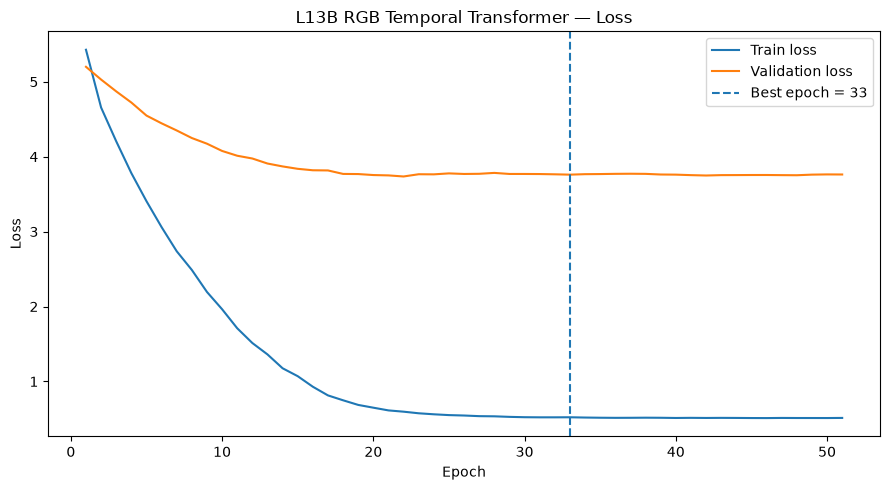

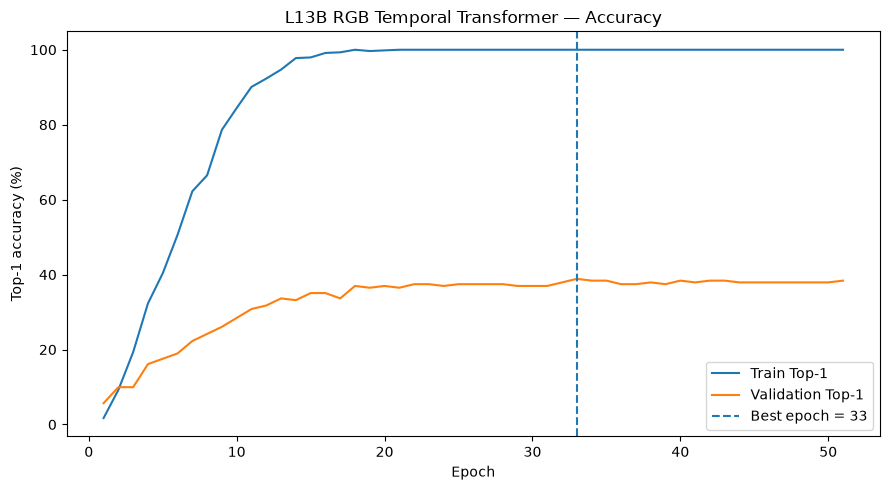


L13B FINAL REPORT

REPRESENTATION
--------------------------------------------------------------------------------------------------------------------------------------------
Visual encoder             : MobileNetV3-Small
Pretraining                : L13A SSL
Encoder frozen             : YES
Projection head            : NOT USED
Sequence                   : 32 frames
Visual embedding/frame     : 576
Temporal representation    : 32 × 576

MODEL
--------------------------------------------------------------------------------------------------------------------------------------------
Architecture               : RGB Temporal Transformer
Model dimension            : 256
Attention heads            : 4
Transformer layers         : 2
Parameters                 : 1,299,028

VALIDATION
--------------------------------------------------------------------------------------------------------------------------------------------
Best epoch                 : 33
Loss                       : 3.760191

In [6]:
# ==================================================================================================
# CISLR MULTIMODAL MODEL — L13B
# RGB-ONLY TEMPORAL SIGN CLASSIFICATION
#
# CORRECTED FULL VERSION
#
# L13A frozen MobileNetV3-Small visual encoder
#       ↓
# 32 landmark-guided RGB observations / video
#       ↓
# 32 × 576 visual embeddings
#       ↓
# train-only standardization
#       ↓
# Temporal Transformer
#       ↓
# 211 controlled CISLR classes
#
# SPLIT POLICY
# ------------
# L9 TRAIN      : 585 videos -> supervised training
# L9 VALIDATION : 211 videos -> model selection
# L9 TEST       : 211 videos -> COMPLETELY LOCKED
#
# IMPORTANT
# ---------
# - Exact frozen L9 class mapping is preserved.
# - Nested L9 JSON mappings are supported.
# - Class IDs are NEVER regenerated alphabetically.
# - L13A encoder is frozen.
# - L13A projection head is not used.
# - Test videos are never opened, decoded, embedded, or evaluated.
# ==================================================================================================

# ==================================================================================================
# 0. IMPORTS
# ==================================================================================================

import os
import cv2
import gc
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import torchvision

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import mobilenet_v3_small

warnings.filterwarnings("ignore")


# ==================================================================================================
# 1. REPRODUCIBILITY
# ==================================================================================================

SEED = 42


def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True


# ==================================================================================================
# 2. DEVICE
# ==================================================================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"


print("=" * 140)
print("CISLR MULTIMODAL MODEL — L13B")
print("RGB-ONLY TEMPORAL CLASSIFICATION USING FROZEN L13A VISUAL ENCODER")
print("=" * 140)

print()
print("PyTorch version     :", torch.__version__)
print("Torchvision version :", torchvision.__version__)
print("Device              :", DEVICE)

if torch.cuda.is_available():
    print("GPU                 :", torch.cuda.get_device_name(0))

print("AMP                 :", USE_AMP)


# ==================================================================================================
# 3. PATHS
# ==================================================================================================

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)

MODEL_ROOT = (
    PROJECT_ROOT /
    "CISLR_LANDMARK_MODEL"
)

VIDEO_DIR = Path(
    "/home/dipshikha/Music/cao/CISLR_v1.5-a_videos"
)

RAW_DIR = (
    MODEL_ROOT /
    "audit" /
    "l6_full_extraction" /
    "raw_sequences"
)


# --------------------------------------------------------------------------------------------------
# L9
# --------------------------------------------------------------------------------------------------

L9_ROOT = (
    MODEL_ROOT /
    "audit" /
    "l9_split_freeze"
)

TRAIN_MANIFEST = (
    L9_ROOT /
    "splits" /
    "l9_train_manifest.csv"
)

VAL_MANIFEST = (
    L9_ROOT /
    "splits" /
    "l9_validation_manifest.csv"
)

TEST_MANIFEST = (
    L9_ROOT /
    "splits" /
    "l9_test_manifest.csv"
)

CLASS_MAPPING_PATH = (
    L9_ROOT /
    "class_mapping" /
    "l9_controlled_class_mapping.json"
)


# --------------------------------------------------------------------------------------------------
# L13A
# --------------------------------------------------------------------------------------------------

L13A_ROOT = (
    MODEL_ROOT /
    "audit" /
    "l13_multimodal" /
    "l13_a_visual"
)

L13A_MODEL_PATH = (
    L13A_ROOT /
    "models" /
    "l13a_best_visual_encoder.pt"
)

L13A_CHECKPOINT_PATH = (
    L13A_ROOT /
    "reports" /
    "l13a_checkpoint.json"
)


# --------------------------------------------------------------------------------------------------
# Previous experiment summaries
# --------------------------------------------------------------------------------------------------

L10_SUMMARY = (
    MODEL_ROOT /
    "audit" /
    "l10_gru_baseline" /
    "reports" /
    "l10_summary.json"
)

L11_SUMMARY = (
    MODEL_ROOT /
    "audit" /
    "l11_bilstm" /
    "reports" /
    "l11_summary.json"
)

L102_SUMMARY = (
    MODEL_ROOT /
    "audit" /
    "l10_2_enhanced_skeleton_gru" /
    "reports" /
    "l10_2_summary.json"
)

L12A_SUMMARY = (
    MODEL_ROOT /
    "audit" /
    "l12_stgcn" /
    "reports" /
    "l12_summary.json"
)

L12B_SUMMARY = (
    MODEL_ROOT /
    "audit" /
    "l12b_ssl_stgcn" /
    "reports" /
    "l12b_summary.json"
)


# --------------------------------------------------------------------------------------------------
# L13B
# --------------------------------------------------------------------------------------------------

L13B_ROOT = (
    MODEL_ROOT /
    "audit" /
    "l13_multimodal" /
    "l13_b_rgb_temporal"
)

CACHE_DIR = (
    L13B_ROOT /
    "embedding_cache"
)

TRAIN_CACHE_DIR = (
    CACHE_DIR /
    "train"
)

VAL_CACHE_DIR = (
    CACHE_DIR /
    "validation"
)

MODEL_DIR = (
    L13B_ROOT /
    "models"
)

REPORT_DIR = (
    L13B_ROOT /
    "reports"
)

PLOT_DIR = (
    L13B_ROOT /
    "plots"
)


for d in [
    L13B_ROOT,
    CACHE_DIR,
    TRAIN_CACHE_DIR,
    VAL_CACHE_DIR,
    MODEL_DIR,
    REPORT_DIR,
    PLOT_DIR
]:

    d.mkdir(
        parents=True,
        exist_ok=True
    )


# ==================================================================================================
# 4. CONFIGURATION
# ==================================================================================================

SEQUENCE_LENGTH = 32

IMAGE_SIZE = 224

VISUAL_DIM = 576

NUM_CLASSES = 211


# --------------------------------------------------------------------------------------------------
# Transformer
# --------------------------------------------------------------------------------------------------

MODEL_DIM = 256

NUM_HEADS = 4

NUM_LAYERS = 2

FF_DIM = 512

DROPOUT = 0.35


# --------------------------------------------------------------------------------------------------
# Training
# --------------------------------------------------------------------------------------------------

BATCH_SIZE = 32

MAX_EPOCHS = 120

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 1e-4

EARLY_STOP_PATIENCE = 18

LR_PATIENCE = 6

LR_FACTOR = 0.5

MIN_LR = 1e-6

GRAD_CLIP = 5.0

LABEL_SMOOTHING = 0.05


# --------------------------------------------------------------------------------------------------
# Embedding extraction
# --------------------------------------------------------------------------------------------------

EMBED_BATCH_SIZE = 64


# --------------------------------------------------------------------------------------------------
# ROI
# --------------------------------------------------------------------------------------------------

CONTEXT_BOX_SCALE = 1.50

MIN_CONTEXT_BOX = 96


# ==================================================================================================
# 5. REQUIRED PATH CHECK
# ==================================================================================================

required_paths = [

    VIDEO_DIR,
    RAW_DIR,

    TRAIN_MANIFEST,
    VAL_MANIFEST,
    TEST_MANIFEST,

    CLASS_MAPPING_PATH,

    L13A_MODEL_PATH,
    L13A_CHECKPOINT_PATH
]


for path in required_paths:

    if not path.exists():

        raise FileNotFoundError(
            f"Required dependency missing:\n{path}"
        )


print()
print("[PASS] Required L6/L9/L13A paths exist.")


# ==================================================================================================
# 6. VERIFY L13A CHECKPOINT
# ==================================================================================================

with open(
    L13A_CHECKPOINT_PATH,
    "r"
) as f:

    l13a_checkpoint = json.load(f)


if l13a_checkpoint.get("status") != "PASS":

    raise RuntimeError(
        "L13A checkpoint is not PASS."
    )


if l13a_checkpoint.get(
    "l9_test_used",
    False
):

    raise RuntimeError(
        "L13A checkpoint indicates L9 test usage."
    )


print("[PASS] L13A checkpoint verified.")

print(
    "L13A best epoch :",
    l13a_checkpoint.get(
        "best_epoch",
        "unknown"
    )
)

print(
    "L13A SSL loss   :",
    l13a_checkpoint.get(
        "best_ssl_holdout_loss",
        "unknown"
    )
)


# ==================================================================================================
# 7. LOAD FROZEN L9 SPLITS
# ==================================================================================================

train_df = pd.read_csv(
    TRAIN_MANIFEST
)

val_df = pd.read_csv(
    VAL_MANIFEST
)

test_df = pd.read_csv(
    TEST_MANIFEST
)


for df in [
    train_df,
    val_df,
    test_df
]:

    if "uid" not in df.columns:

        raise RuntimeError(
            "L9 manifest does not contain UID column."
        )

    df["uid"] = df["uid"].astype(str)


assert len(train_df) == 585
assert len(val_df) == 211
assert len(test_df) == 211


train_uids = set(
    train_df["uid"]
)

val_uids = set(
    val_df["uid"]
)

test_uids = set(
    test_df["uid"]
)


assert train_uids.isdisjoint(
    val_uids
)

assert train_uids.isdisjoint(
    test_uids
)

assert val_uids.isdisjoint(
    test_uids
)


print()
print("=" * 140)
print("FROZEN L9 SPLIT")
print("=" * 140)

print()
print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df), "(LOCKED)")

print()
print("[PASS] Zero UID overlap.")


# ==================================================================================================
# 8. LOAD EXACT FROZEN L9 CLASS MAPPING
# ==================================================================================================

with open(
    CLASS_MAPPING_PATH,
    "r"
) as f:

    class_mapping_raw = json.load(f)


print()
print("=" * 140)
print("L9 CLASS MAPPING")
print("=" * 140)

print()
print("Mapping file   :", CLASS_MAPPING_PATH)
print("Top-level type :", type(class_mapping_raw).__name__)

if isinstance(
    class_mapping_raw,
    dict
):

    print(
        "Top-level keys :",
        list(
            class_mapping_raw.keys()
        )[:20]
    )


# --------------------------------------------------------------------------------------------------
# Detect {gloss: class_id}
# --------------------------------------------------------------------------------------------------

def is_gloss_to_id_dict(
    obj
):

    if (
        not isinstance(
            obj,
            dict
        )
        or
        len(obj) == 0
    ):

        return False


    try:

        for key, value in obj.items():

            if isinstance(
                value,
                bool
            ):
                return False

            if isinstance(
                value,
                (
                    dict,
                    list
                )
            ):
                return False

            int(value)


        return True


    except (
        TypeError,
        ValueError
    ):

        return False


# --------------------------------------------------------------------------------------------------
# Detect {class_id: gloss}
# --------------------------------------------------------------------------------------------------

def is_id_to_gloss_dict(
    obj
):

    if (
        not isinstance(
            obj,
            dict
        )
        or
        len(obj) == 0
    ):

        return False


    try:

        for key, value in obj.items():

            int(key)

            if isinstance(
                value,
                (
                    dict,
                    list
                )
            ):
                return False


        return True


    except (
        TypeError,
        ValueError
    ):

        return False


# --------------------------------------------------------------------------------------------------
# Recursively search nested JSON
# --------------------------------------------------------------------------------------------------

def find_mapping_candidates(
    obj,
    path="root"
):

    candidates = []


    if isinstance(
        obj,
        dict
    ):

        # ------------------------------------------------------------------------------------------
        # gloss -> ID
        # ------------------------------------------------------------------------------------------

        if is_gloss_to_id_dict(
            obj
        ):

            converted = {
                str(k): int(v)
                for k, v in obj.items()
            }


            candidates.append(
                {
                    "path":
                        path,

                    "type":
                        "gloss_to_id",

                    "mapping":
                        converted
                }
            )


        # ------------------------------------------------------------------------------------------
        # ID -> gloss
        # ------------------------------------------------------------------------------------------

        if is_id_to_gloss_dict(
            obj
        ):

            converted = {
                str(v): int(k)
                for k, v in obj.items()
            }


            candidates.append(
                {
                    "path":
                        path,

                    "type":
                        "id_to_gloss",

                    "mapping":
                        converted
                }
            )


        # ------------------------------------------------------------------------------------------
        # recurse
        # ------------------------------------------------------------------------------------------

        for key, value in obj.items():

            candidates.extend(
                find_mapping_candidates(
                    value,
                    path=f"{path}.{key}"
                )
            )


    elif isinstance(
        obj,
        list
    ):

        for i, value in enumerate(
            obj
        ):

            candidates.extend(
                find_mapping_candidates(
                    value,
                    path=f"{path}[{i}]"
                )
            )


    return candidates


mapping_candidates = (
    find_mapping_candidates(
        class_mapping_raw
    )
)


# --------------------------------------------------------------------------------------------------
# Keep only exact 211-class mappings with IDs 0..210
# --------------------------------------------------------------------------------------------------

valid_candidates = []


for candidate in mapping_candidates:

    mapping = candidate[
        "mapping"
    ]


    if len(
        mapping
    ) != NUM_CLASSES:

        continue


    ids = sorted(
        mapping.values()
    )


    if ids != list(
        range(
            NUM_CLASSES
        )
    ):

        continue


    valid_candidates.append(
        candidate
    )


print()
print(
    "Candidate mappings found :",
    len(mapping_candidates)
)

print(
    "Valid 211-class mappings :",
    len(valid_candidates)
)


if len(
    valid_candidates
) == 0:

    print()
    print("JSON structure preview:")
    print(
        json.dumps(
            class_mapping_raw,
            indent=2
        )[:5000]
    )


    raise RuntimeError(
        "\nCould not locate an exact frozen 211-class "
        "mapping inside L9 JSON.\n"
        "Stopping rather than generating new class IDs."
    )


# --------------------------------------------------------------------------------------------------
# Prefer semantically named mapping
# --------------------------------------------------------------------------------------------------

preferred_keywords = [

    "gloss_to_id",
    "gloss_to_idx",

    "class_to_id",
    "class_to_idx",

    "label_to_id",
    "label_to_idx"
]


selected_candidate = None


for keyword in preferred_keywords:

    for candidate in valid_candidates:

        if keyword in candidate[
            "path"
        ].lower():

            selected_candidate = (
                candidate
            )

            break


    if selected_candidate is not None:
        break


# --------------------------------------------------------------------------------------------------
# If no preferred key, require equivalent mappings
# --------------------------------------------------------------------------------------------------

if selected_candidate is None:

    first_mapping = (
        valid_candidates[0][
            "mapping"
        ]
    )


    all_equivalent = all(

        candidate[
            "mapping"
        ]
        ==
        first_mapping

        for candidate
        in valid_candidates
    )


    if not all_equivalent:

        print()
        print(
            "Multiple DIFFERENT valid mappings found:"
        )


        for candidate in valid_candidates:

            print(
                candidate[
                    "path"
                ],
                "|",
                candidate[
                    "type"
                ]
            )


        raise RuntimeError(
            "Ambiguous frozen class mapping. "
            "Stopping rather than guessing."
        )


    selected_candidate = (
        valid_candidates[0]
    )


gloss_to_id = {

    str(k):
        int(v)

    for k, v
    in selected_candidate[
        "mapping"
    ].items()
}


id_to_gloss = {

    int(v):
        str(k)

    for k, v
    in gloss_to_id.items()
}


assert len(
    gloss_to_id
) == NUM_CLASSES

assert len(
    id_to_gloss
) == NUM_CLASSES

assert sorted(
    id_to_gloss.keys()
) == list(
    range(
        NUM_CLASSES
    )
)


print()
print("[PASS] Frozen L9 class mapping located.")

print(
    "Selected JSON path :",
    selected_candidate[
        "path"
    ]
)

print(
    "Detected format    :",
    selected_candidate[
        "type"
    ]
)

print(
    "Controlled classes :",
    len(
        gloss_to_id
    )
)

print(
    "Class-ID range     :",
    min(
        id_to_gloss
    ),
    "to",
    max(
        id_to_gloss
    )
)


print()
print("First 15 frozen class IDs:")
print("-" * 70)


for class_id in range(
    15
):

    print(
        f"{class_id:3d} -> "
        f"{id_to_gloss[class_id]}"
    )


# ==================================================================================================
# 9. RESOLVE GLOSS COLUMN
# ==================================================================================================

def get_gloss_column(
    df
):

    for candidate in [

        "gloss",
        "label",
        "class_name"

    ]:

        if candidate in df.columns:

            return candidate


    raise RuntimeError(
        "Could not locate gloss/label column."
    )


TRAIN_GLOSS_COL = (
    get_gloss_column(
        train_df
    )
)

VAL_GLOSS_COL = (
    get_gloss_column(
        val_df
    )
)


train_df[
    "gloss_l13b"
] = (
    train_df[
        TRAIN_GLOSS_COL
    ]
    .astype(str)
)


val_df[
    "gloss_l13b"
] = (
    val_df[
        VAL_GLOSS_COL
    ]
    .astype(str)
)


# --------------------------------------------------------------------------------------------------
# Validate vocabulary BEFORE assigning IDs
# --------------------------------------------------------------------------------------------------

train_gloss_set = set(
    train_df[
        "gloss_l13b"
    ]
)

val_gloss_set = set(
    val_df[
        "gloss_l13b"
    ]
)

mapping_gloss_set = set(
    gloss_to_id.keys()
)


missing_train_glosses = (
    train_gloss_set -
    mapping_gloss_set
)

missing_val_glosses = (
    val_gloss_set -
    mapping_gloss_set
)


if missing_train_glosses:

    raise RuntimeError(
        "Training labels missing from frozen mapping:\n"
        +
        str(
            sorted(
                missing_train_glosses
            )
        )
    )


if missing_val_glosses:

    raise RuntimeError(
        "Validation labels missing from frozen mapping:\n"
        +
        str(
            sorted(
                missing_val_glosses
            )
        )
    )


assert len(
    train_gloss_set
) == NUM_CLASSES

assert len(
    val_gloss_set
) == NUM_CLASSES


train_df[
    "class_id_l13b"
] = (
    train_df[
        "gloss_l13b"
    ]
    .map(
        gloss_to_id
    )
    .astype(int)
)


val_df[
    "class_id_l13b"
] = (
    val_df[
        "gloss_l13b"
    ]
    .map(
        gloss_to_id
    )
    .astype(int)
)


assert (
    train_df[
        "class_id_l13b"
    ].nunique()
    ==
    NUM_CLASSES
)

assert (
    val_df[
        "class_id_l13b"
    ].nunique()
    ==
    NUM_CLASSES
)


print()
print("[PASS] TRAIN contains all 211 frozen classes.")
print("[PASS] VALIDATION contains all 211 frozen classes.")
print("[PASS] No class IDs regenerated or reordered.")


# ==================================================================================================
# 10. INDEX L6 RAW SEQUENCES FOR TRAIN + VALIDATION ONLY
# ==================================================================================================

print()
print("=" * 140)
print("INDEXING L6 RAW SEQUENCES — TRAIN + VALIDATION ONLY")
print("=" * 140)


allowed_uids = (
    train_uids |
    val_uids
)


uid_to_raw = {}


raw_paths = sorted(
    RAW_DIR.glob(
        "*.npz"
    )
)


print()
print(
    "Raw sequence files:",
    len(
        raw_paths
    )
)


for i, path in enumerate(
    raw_paths,
    start=1
):

    try:

        with np.load(
            path,
            allow_pickle=True
        ) as d:

            uid = str(
                d[
                    "uid"
                ].item()
            )


        if uid in allowed_uids:

            uid_to_raw[
                uid
            ] = path


    except Exception:

        pass


    if (
        i % 1000 == 0
        or
        i == len(
            raw_paths
        )
    ):

        print(
            f"  {i}/{len(raw_paths)}"
        )


missing_train_raw = (
    train_uids -
    set(
        uid_to_raw.keys()
    )
)

missing_val_raw = (
    val_uids -
    set(
        uid_to_raw.keys()
    )
)


print()
print(
    "Train raw found :",
    len(train_uids) -
    len(missing_train_raw)
)

print(
    "Val raw found   :",
    len(val_uids) -
    len(missing_val_raw)
)


if missing_train_raw:

    raise RuntimeError(
        f"Missing TRAIN raw sequences: "
        f"{len(missing_train_raw)}"
    )


if missing_val_raw:

    raise RuntimeError(
        f"Missing VALIDATION raw sequences: "
        f"{len(missing_val_raw)}"
    )


print(
    "[PASS] All TRAIN/VALIDATION raw sequences found."
)


# ==================================================================================================
# 11. INDEX ORIGINAL VIDEOS
# ==================================================================================================

video_paths = sorted(
    VIDEO_DIR.glob(
        "*.mp4"
    )
)


video_name_index = {

    p.name:
        p

    for p in video_paths
}


print()
print(
    "Original MP4 files:",
    len(
        video_paths
    )
)


# ==================================================================================================
# 12. VIDEO PATH RESOLUTION
# ==================================================================================================

def resolve_video_path(
    uid,
    raw_path
):

    with np.load(
        raw_path,
        allow_pickle=True
    ) as d:

        if "video_path" in d.files:

            stored = Path(
                str(
                    d[
                        "video_path"
                    ].item()
                )
            )


            if stored.exists():

                return stored


            if stored.name in video_name_index:

                return video_name_index[
                    stored.name
                ]


    candidate = (
        f"{uid}.mp4"
    )


    if candidate in video_name_index:

        return video_name_index[
            candidate
        ]


    return None


# ==================================================================================================
# 13. BUILD ALLOWED SOURCE TABLES
# ==================================================================================================

def build_source_table(
    df,
    split_name
):

    rows = []


    for _, row in df.iterrows():

        uid = str(
            row[
                "uid"
            ]
        )


        if uid in test_uids:

            raise RuntimeError(
                f"TEST UID encountered while building "
                f"{split_name}: {uid}"
            )


        raw_path = (
            uid_to_raw[
                uid
            ]
        )


        video_path = (
            resolve_video_path(
                uid,
                raw_path
            )
        )


        if video_path is None:

            raise FileNotFoundError(
                f"Could not resolve video for UID {uid}"
            )


        rows.append(
            {
                "uid":
                    uid,

                "gloss":
                    str(
                        row[
                            "gloss_l13b"
                        ]
                    ),

                "class_id":
                    int(
                        row[
                            "class_id_l13b"
                        ]
                    ),

                "split":
                    split_name,

                "raw_path":
                    str(
                        raw_path
                    ),

                "video_path":
                    str(
                        video_path
                    )
            }
        )


    return pd.DataFrame(
        rows
    )


train_sources = (
    build_source_table(
        train_df,
        "TRAIN"
    )
)

val_sources = (
    build_source_table(
        val_df,
        "VALIDATION"
    )
)


assert len(
    train_sources
) == 585

assert len(
    val_sources
) == 211


print()
print(
    "[PASS] TRAIN and VALIDATION RGB source tables built."
)


# ==================================================================================================
# 14. TEST LOCK VERIFICATION
# ==================================================================================================

assert set(
    train_sources[
        "uid"
    ]
).isdisjoint(
    test_uids
)

assert set(
    val_sources[
        "uid"
    ]
).isdisjoint(
    test_uids
)


print()
print("=" * 140)
print("TEST LOCK VERIFICATION")
print("=" * 140)

print()
print(
    "Test manifest UIDs       :",
    len(
        test_uids
    )
)

print(
    "Test source table built  : NO"
)

print(
    "Test video paths resolved: NO"
)

print(
    "Test RGB decoded         : NO"
)

print(
    "Test embeddings created  : NO"
)

print(
    "Test evaluated           : NO"
)

print()
print(
    "[PASS] L9 TEST remains locked."
)


# ==================================================================================================
# 15. VISUAL ENCODER ARCHITECTURE
# ==================================================================================================

class VisualEncoder(
    nn.Module
):

    def __init__(
        self,
        backbone
    ):

        super().__init__()

        self.features = (
            backbone.features
        )

        self.avgpool = (
            nn.AdaptiveAvgPool2d(1)
        )


    def forward(
        self,
        x
    ):

        x = self.features(
            x
        )

        x = self.avgpool(
            x
        )

        x = torch.flatten(
            x,
            1
        )

        return x


# ==================================================================================================
# 16. LOAD L13A ENCODER CHECKPOINT ROBUSTLY
# ==================================================================================================

backbone = mobilenet_v3_small(
    weights=None
)

visual_encoder = VisualEncoder(
    backbone
)


l13a_model_checkpoint = torch.load(
    L13A_MODEL_PATH,
    map_location="cpu",
    weights_only=False
)


print()
print("=" * 140)
print("LOADING FROZEN L13A VISUAL ENCODER")
print("=" * 140)

print()
print(
    "Checkpoint type:",
    type(
        l13a_model_checkpoint
    ).__name__
)


# --------------------------------------------------------------------------------------------------
# Locate encoder state dict
# --------------------------------------------------------------------------------------------------

encoder_state = None


if isinstance(
    l13a_model_checkpoint,
    dict
):

    possible_keys = [

        "encoder_state_dict",
        "visual_encoder_state_dict",
        "backbone_state_dict",
        "model_state_dict",
        "state_dict"
    ]


    for key in possible_keys:

        if key in l13a_model_checkpoint:

            candidate = (
                l13a_model_checkpoint[
                    key
                ]
            )


            if isinstance(
                candidate,
                dict
            ):

                encoder_state = (
                    candidate
                )

                print(
                    "Encoder state key:",
                    key
                )

                break


    # ----------------------------------------------------------------------------------------------
    # Could itself already be state dict
    # ----------------------------------------------------------------------------------------------

    if encoder_state is None:

        if all(
            torch.is_tensor(v)
            for v in l13a_model_checkpoint.values()
        ):

            encoder_state = (
                l13a_model_checkpoint
            )

            print(
                "Checkpoint itself is state_dict."
            )


if encoder_state is None:

    raise RuntimeError(
        "Could not locate L13A encoder state_dict."
    )


# --------------------------------------------------------------------------------------------------
# Handle optional prefixes
# --------------------------------------------------------------------------------------------------

clean_state = {}


for key, value in encoder_state.items():

    new_key = key


    for prefix in [

        "module.",
        "encoder.",
        "visual_encoder."

    ]:

        if new_key.startswith(
            prefix
        ):

            new_key = new_key[
                len(prefix):
            ]


    clean_state[
        new_key
    ] = value


# --------------------------------------------------------------------------------------------------
# First attempt exact load
# --------------------------------------------------------------------------------------------------

try:

    visual_encoder.load_state_dict(
        clean_state,
        strict=True
    )


except RuntimeError:

    # ----------------------------------------------------------------------------------------------
    # L13A may have saved a full SimCLR model whose encoder weights are prefixed with encoder.
    # Extract keys matching VisualEncoder.
    # ----------------------------------------------------------------------------------------------

    expected_keys = set(
        visual_encoder
        .state_dict()
        .keys()
    )


    filtered_state = {

        k:
            v

        for k, v
        in clean_state.items()

        if k in expected_keys
    }


    missing = (
        expected_keys -
        set(
            filtered_state.keys()
        )
    )


    if missing:

        print()
        print(
            "Missing encoder keys:",
            list(
                sorted(
                    missing
                )
            )[:20]
        )


        raise RuntimeError(
            "L13A visual encoder weights could not "
            "be reconstructed exactly."
        )


    visual_encoder.load_state_dict(
        filtered_state,
        strict=True
    )


visual_encoder = (
    visual_encoder
    .to(
        DEVICE
    )
)

visual_encoder.eval()


for parameter in visual_encoder.parameters():

    parameter.requires_grad = False


# --------------------------------------------------------------------------------------------------
# Sanity check output dimension
# --------------------------------------------------------------------------------------------------

with torch.no_grad():

    dummy = torch.zeros(
        1,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=DEVICE
    )


    with torch.amp.autocast(
        device_type="cuda",
        enabled=USE_AMP
    ):

        dummy_embedding = (
            visual_encoder(
                dummy
            )
        )


if dummy_embedding.shape != (
    1,
    VISUAL_DIM
):

    raise RuntimeError(
        "Unexpected L13A embedding shape: "
        f"{tuple(dummy_embedding.shape)}"
    )


print()
print("[PASS] L13A encoder loaded exactly.")
print("Encoder frozen       : YES")
print("Embedding dimension  :", VISUAL_DIM)
print("Projection head used : NO")


# ==================================================================================================
# 17. IMAGE PREPROCESSING
# ==================================================================================================

visual_transform = (
    transforms.Compose(
        [
            transforms.ToPILImage(),

            transforms.Resize(
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE
                )
            ),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=[
                    0.485,
                    0.456,
                    0.406
                ],

                std=[
                    0.229,
                    0.224,
                    0.225
                ]
            )
        ]
    )
)


# ==================================================================================================
# 18. ROI UTILITIES
# ==================================================================================================

def clip_box(
    box,
    width,
    height
):

    x1, y1, x2, y2 = box


    x1 = int(
        np.clip(
            round(x1),
            0,
            max(
                width - 1,
                0
            )
        )
    )


    y1 = int(
        np.clip(
            round(y1),
            0,
            max(
                height - 1,
                0
            )
        )
    )


    x2 = int(
        np.clip(
            round(x2),
            x1 + 1,
            width
        )
    )


    y2 = int(
        np.clip(
            round(y2),
            y1 + 1,
            height
        )
    )


    return (
        x1,
        y1,
        x2,
        y2
    )


def square_box_from_points(
    points_xy,
    width,
    height,
    scale,
    minimum_size
):

    points_xy = np.asarray(
        points_xy,
        dtype=np.float32
    )


    finite = np.isfinite(
        points_xy
    ).all(
        axis=1
    )


    points_xy = (
        points_xy[
            finite
        ]
    )


    if len(
        points_xy
    ) == 0:

        return None


    xmin = float(
        points_xy[
            :,
            0
        ].min()
    )

    xmax = float(
        points_xy[
            :,
            0
        ].max()
    )

    ymin = float(
        points_xy[
            :,
            1
        ].min()
    )

    ymax = float(
        points_xy[
            :,
            1
        ].max()
    )


    cx = (
        xmin +
        xmax
    ) / 2.0

    cy = (
        ymin +
        ymax
    ) / 2.0


    side = max(

        xmax - xmin,
        ymax - ymin,

        float(
            minimum_size
        )
    )


    side *= scale


    return clip_box(
        (
            cx - side / 2.0,
            cy - side / 2.0,
            cx + side / 2.0,
            cy + side / 2.0
        ),
        width,
        height
    )


def context_box_from_landmarks(
    landmarks,
    mask,
    width,
    height
):

    all_points = []


    for hand_idx in range(
        2
    ):

        if mask[
            hand_idx
        ] <= 0:

            continue


        points = (
            landmarks[
                hand_idx,
                :,
                :2
            ]
        )


        finite = np.isfinite(
            points
        ).all(
            axis=1
        )


        points = (
            points[
                finite
            ]
        )


        if len(
            points
        ) > 0:

            all_points.append(
                points
            )


    if len(
        all_points
    ) == 0:

        return None


    all_points = np.concatenate(
        all_points,
        axis=0
    )


    return square_box_from_points(
        all_points,
        width,
        height,
        CONTEXT_BOX_SCALE,
        MIN_CONTEXT_BOX
    )


# ==================================================================================================
# 19. TEMPORAL RESAMPLING
# ==================================================================================================

def resample_positions(
    T,
    target_length=32
):

    if T <= 0:

        raise RuntimeError(
            "Empty raw sequence."
        )


    indices = np.linspace(
        0,
        T - 1,
        target_length
    )


    indices = np.rint(
        indices
    ).astype(
        np.int64
    )


    indices = np.clip(
        indices,
        0,
        T - 1
    )


    return indices


# ==================================================================================================
# 20. RGB DECODING
# ==================================================================================================

def decode_selected_frames(
    video_path,
    frame_numbers
):

    cap = cv2.VideoCapture(
        str(
            video_path
        )
    )


    if not cap.isOpened():

        cap.release()

        raise RuntimeError(
            f"Could not open video:\n{video_path}"
        )


    frames = []

    last_good = None


    for frame_number in frame_numbers:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(
                frame_number
            )
        )


        ok, frame = cap.read()


        if (
            not ok
            or
            frame is None
        ):

            recovered = None


            for offset in [

                -1,
                1,
                -2,
                2,
                -3,
                3

            ]:

                candidate = max(
                    0,
                    int(
                        frame_number
                    ) + offset
                )


                cap.set(
                    cv2.CAP_PROP_POS_FRAMES,
                    candidate
                )


                ok2, frame2 = (
                    cap.read()
                )


                if (
                    ok2
                    and
                    frame2 is not None
                ):

                    recovered = (
                        frame2
                    )

                    break


            if recovered is not None:

                frame = recovered


            elif last_good is not None:

                frame = (
                    last_good.copy()
                )


            else:

                cap.release()

                raise RuntimeError(
                    f"Could not decode frame "
                    f"{frame_number} from {video_path}"
                )


        last_good = (
            frame.copy()
        )


        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )


        frames.append(
            frame
        )


    cap.release()


    return frames


# ==================================================================================================
# 21. DETERMINISTIC LANDMARK-GUIDED CROP
# ==================================================================================================

def deterministic_visual_crop(
    frame,
    landmarks,
    mask
):

    height, width = (
        frame.shape[:2]
    )


    box = (
        context_box_from_landmarks(
            landmarks,
            mask,
            width,
            height
        )
    )


    if box is None:

        return (
            frame,
            0
        )


    x1, y1, x2, y2 = box


    crop = (
        frame[
            y1:y2,
            x1:x2
        ]
    )


    if (
        crop.size == 0
        or
        crop.shape[0] < 8
        or
        crop.shape[1] < 8
    ):

        return (
            frame,
            0
        )


    return (
        crop,
        1
    )


# ==================================================================================================
# 22. EXTRACT ONE VIDEO'S 32 × 576 EMBEDDINGS
# ==================================================================================================

@torch.no_grad()
def extract_video_embedding_sequence(
    source_row
):

    uid = str(
        source_row[
            "uid"
        ]
    )


    if uid in test_uids:

        raise RuntimeError(
            "TEST leakage attempt detected."
        )


    raw_path = Path(
        source_row[
            "raw_path"
        ]
    )

    video_path = Path(
        source_row[
            "video_path"
        ]
    )


    with np.load(
        raw_path,
        allow_pickle=True
    ) as d:

        raw_uid = str(
            d[
                "uid"
            ].item()
        )


        if raw_uid != uid:

            raise RuntimeError(
                f"UID mismatch: "
                f"{uid} != {raw_uid}"
            )


        frame_numbers = (
            d[
                "frame_numbers"
            ]
            .astype(
                np.int64
            )
        )


        landmarks = (
            d[
                "landmarks_px"
            ]
            .astype(
                np.float32
            )
        )


        hand_mask = (
            d[
                "hand_mask"
            ]
            .astype(
                np.uint8
            )
        )


    T = len(
        frame_numbers
    )


    positions = (
        resample_positions(
            T,
            SEQUENCE_LENGTH
        )
    )


    selected_frame_numbers = (
        frame_numbers[
            positions
        ]
    )


    selected_landmarks = (
        landmarks[
            positions
        ]
    )


    selected_masks = (
        hand_mask[
            positions
        ]
    )


    frames = (
        decode_selected_frames(
            video_path,
            selected_frame_numbers
        )
    )


    tensors = []

    context_mask = []


    for i in range(
        SEQUENCE_LENGTH
    ):

        crop, used_context = (
            deterministic_visual_crop(
                frames[i],
                selected_landmarks[i],
                selected_masks[i]
            )
        )


        tensors.append(
            visual_transform(
                crop
            )
        )


        context_mask.append(
            used_context
        )


    tensors = torch.stack(
        tensors,
        dim=0
    )


    embeddings = []


    for start in range(
        0,
        SEQUENCE_LENGTH,
        EMBED_BATCH_SIZE
    ):

        batch = (
            tensors[
                start:
                start + EMBED_BATCH_SIZE
            ]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        with torch.amp.autocast(
            device_type="cuda",
            enabled=USE_AMP
        ):

            embedding = (
                visual_encoder(
                    batch
                )
            )


        embeddings.append(
            embedding
            .float()
            .cpu()
        )


    embeddings = (
        torch.cat(
            embeddings,
            dim=0
        )
        .numpy()
        .astype(
            np.float32
        )
    )


    context_mask = np.asarray(
        context_mask,
        dtype=np.float32
    )


    if embeddings.shape != (
        SEQUENCE_LENGTH,
        VISUAL_DIM
    ):

        raise RuntimeError(
            f"Bad embedding shape "
            f"for {uid}: {embeddings.shape}"
        )


    if not np.isfinite(
        embeddings
    ).all():

        raise RuntimeError(
            f"Non-finite embeddings for {uid}"
        )


    return (
        embeddings,
        context_mask,
        selected_frame_numbers
    )


# ==================================================================================================
# 23. BUILD RGB EMBEDDING CACHE
# ==================================================================================================

def build_embedding_cache(
    source_df,
    cache_dir,
    split_name
):

    print()
    print("=" * 140)
    print(
        f"EXTRACTING {split_name} RGB EMBEDDINGS"
    )
    print("=" * 140)


    rows = []

    failures = []

    start_time = time.time()


    source_df = (
        source_df
        .reset_index(
            drop=True
        )
    )


    for idx, row in source_df.iterrows():

        uid = str(
            row[
                "uid"
            ]
        )


        if uid in test_uids:

            raise RuntimeError(
                f"TEST UID {uid} reached RGB embedding extraction."
            )


        cache_path = (
            cache_dir /
            f"{uid}.npz"
        )


        use_existing = False


        # ------------------------------------------------------------------------------------------
        # Existing cache validation
        # ------------------------------------------------------------------------------------------

        if cache_path.exists():

            try:

                with np.load(
                    cache_path,
                    allow_pickle=True
                ) as d:

                    cached_uid = str(
                        d[
                            "uid"
                        ].item()
                    )


                    embeddings = (
                        d[
                            "embeddings"
                        ]
                    )


                    if (
                        cached_uid == uid
                        and
                        embeddings.shape ==
                        (
                            SEQUENCE_LENGTH,
                            VISUAL_DIM
                        )
                        and
                        np.isfinite(
                            embeddings
                        ).all()
                    ):

                        use_existing = True


            except Exception:

                use_existing = False


        # ------------------------------------------------------------------------------------------
        # Extract
        # ------------------------------------------------------------------------------------------

        if not use_existing:

            try:

                (
                    embeddings,
                    context_mask,
                    selected_frame_numbers
                ) = (
                    extract_video_embedding_sequence(
                        row
                    )
                )


                np.savez_compressed(

                    cache_path,

                    uid=np.asarray(
                        uid
                    ),

                    gloss=np.asarray(
                        str(
                            row[
                                "gloss"
                            ]
                        )
                    ),

                    class_id=np.asarray(
                        int(
                            row[
                                "class_id"
                            ]
                        ),
                        dtype=np.int64
                    ),

                    split=np.asarray(
                        split_name
                    ),

                    embeddings=embeddings,

                    context_mask=context_mask,

                    frame_numbers=selected_frame_numbers
                )


            except Exception as e:

                failures.append(
                    {
                        "uid":
                            uid,

                        "split":
                            split_name,

                        "error":
                            repr(e)
                    }
                )


                print()
                print(
                    f"[FAIL] {uid}: {e}"
                )

                continue


        rows.append(
            {
                "uid":
                    uid,

                "gloss":
                    str(
                        row[
                            "gloss"
                        ]
                    ),

                "class_id":
                    int(
                        row[
                            "class_id"
                        ]
                    ),

                "split":
                    split_name,

                "cache_path":
                    str(
                        cache_path
                    )
            }
        )


        done = (
            idx + 1
        )


        if (
            done % 50 == 0
            or
            done == len(
                source_df
            )
        ):

            elapsed = (
                time.time() -
                start_time
            )


            print(
                f"  {done}/{len(source_df)} "
                f"| {elapsed:.1f} sec"
            )


    print()
    print(
        f"[DONE] {split_name}: "
        f"{len(rows)}/{len(source_df)}"
    )


    return (
        pd.DataFrame(
            rows
        ),

        pd.DataFrame(
            failures
        )
    )


# ==================================================================================================
# 24. TRAIN RGB EMBEDDINGS
# ==================================================================================================

train_cache_df, train_failures = (
    build_embedding_cache(
        train_sources,
        TRAIN_CACHE_DIR,
        "TRAIN"
    )
)


# ==================================================================================================
# 25. VALIDATION RGB EMBEDDINGS
# ==================================================================================================

val_cache_df, val_failures = (
    build_embedding_cache(
        val_sources,
        VAL_CACHE_DIR,
        "VALIDATION"
    )
)


# ==================================================================================================
# 26. CACHE AUDIT
# ==================================================================================================

print()
print("=" * 140)
print("RGB EMBEDDING CACHE AUDIT")
print("=" * 140)

print()
print(
    "TRAIN cache      :",
    len(
        train_cache_df
    ),
    "/585"
)

print(
    "VALIDATION cache :",
    len(
        val_cache_df
    ),
    "/211"
)

print(
    "TRAIN failures   :",
    len(
        train_failures
    )
)

print(
    "VAL failures     :",
    len(
        val_failures
    )
)


if len(
    train_cache_df
) != 585:

    raise RuntimeError(
        "TRAIN embedding cache incomplete."
    )


if len(
    val_cache_df
) != 211:

    raise RuntimeError(
        "VALIDATION embedding cache incomplete."
    )


if len(
    train_failures
) != 0:

    raise RuntimeError(
        "TRAIN RGB embedding failures detected."
    )


if len(
    val_failures
) != 0:

    raise RuntimeError(
        "VALIDATION RGB embedding failures detected."
    )


def audit_cache(
    cache_df
):

    bad = []


    for _, row in cache_df.iterrows():

        path = Path(
            row[
                "cache_path"
            ]
        )


        try:

            with np.load(
                path,
                allow_pickle=True
            ) as d:

                x = (
                    d[
                        "embeddings"
                    ]
                )


                uid = str(
                    d[
                        "uid"
                    ].item()
                )


                if uid in test_uids:

                    bad.append(
                        (
                            uid,
                            "TEST_UID"
                        )
                    )


                elif x.shape != (
                    32,
                    576
                ):

                    bad.append(
                        (
                            uid,
                            f"shape={x.shape}"
                        )
                    )


                elif not np.isfinite(
                    x
                ).all():

                    bad.append(
                        (
                            uid,
                            "nonfinite"
                        )
                    )


        except Exception as e:

            bad.append(
                (
                    str(
                        row[
                            "uid"
                        ]
                    ),
                    repr(e)
                )
            )


    return bad


bad_train_cache = (
    audit_cache(
        train_cache_df
    )
)

bad_val_cache = (
    audit_cache(
        val_cache_df
    )
)


if bad_train_cache:

    raise RuntimeError(
        f"Bad TRAIN cache:\n"
        f"{bad_train_cache[:10]}"
    )


if bad_val_cache:

    raise RuntimeError(
        f"Bad VALIDATION cache:\n"
        f"{bad_val_cache[:10]}"
    )


print()
print(
    "[PASS] All 796 embedding caches are structurally valid."
)


# ==================================================================================================
# 27. LOAD EMBEDDING MATRICES
# ==================================================================================================

def load_embedding_matrix(
    cache_df
):

    X = []

    y = []

    uids = []

    glosses = []


    for _, row in cache_df.iterrows():

        uid = str(
            row[
                "uid"
            ]
        )


        if uid in test_uids:

            raise RuntimeError(
                "TEST UID encountered while loading embeddings."
            )


        with np.load(
            row[
                "cache_path"
            ],
            allow_pickle=True
        ) as d:

            embeddings = (
                d[
                    "embeddings"
                ]
                .astype(
                    np.float32
                )
            )


        X.append(
            embeddings
        )

        y.append(
            int(
                row[
                    "class_id"
                ]
            )
        )

        uids.append(
            uid
        )

        glosses.append(
            str(
                row[
                    "gloss"
                ]
            )
        )


    return (

        np.stack(
            X,
            axis=0
        ),

        np.asarray(
            y,
            dtype=np.int64
        ),

        uids,

        glosses
    )


(
    X_train,
    y_train,
    train_uid_list,
    train_gloss_list

) = load_embedding_matrix(
    train_cache_df
)


(
    X_val,
    y_val,
    val_uid_list,
    val_gloss_list

) = load_embedding_matrix(
    val_cache_df
)


print()
print("=" * 140)
print("RGB TEMPORAL DATASET")
print("=" * 140)

print()
print(
    "TRAIN      :",
    X_train.shape
)

print(
    "VALIDATION :",
    X_val.shape
)


assert X_train.shape == (
    585,
    32,
    576
)

assert X_val.shape == (
    211,
    32,
    576
)


# ==================================================================================================
# 28. TRAIN-ONLY STANDARDIZATION
# ==================================================================================================

train_flat = (
    X_train.reshape(
        -1,
        VISUAL_DIM
    )
)


train_mean = (
    train_flat
    .mean(
        axis=0
    )
    .astype(
        np.float32
    )
)


train_std = (
    train_flat
    .std(
        axis=0
    )
    .astype(
        np.float32
    )
)


near_zero = (
    train_std <
    1e-6
)


train_std[
    near_zero
] = 1.0


X_train = (
    (
        X_train -
        train_mean[
            None,
            None,
            :
        ]
    )
    /
    train_std[
        None,
        None,
        :
    ]
).astype(
    np.float32
)


X_val = (
    (
        X_val -
        train_mean[
            None,
            None,
            :
        ]
    )
    /
    train_std[
        None,
        None,
        :
    ]
).astype(
    np.float32
)


assert np.isfinite(
    X_train
).all()

assert np.isfinite(
    X_val
).all()


MEAN_PATH = (
    REPORT_DIR /
    "l13b_train_embedding_mean.npy"
)

STD_PATH = (
    REPORT_DIR /
    "l13b_train_embedding_std.npy"
)


np.save(
    MEAN_PATH,
    train_mean
)

np.save(
    STD_PATH,
    train_std
)


print()
print("=" * 140)
print("TRAIN-ONLY STANDARDIZATION")
print("=" * 140)

print()
print(
    "Near-zero std dims :",
    int(
        near_zero.sum()
    )
)

print(
    "Train mean         :",
    f"{X_train.mean():.6f}"
)

print(
    "Train std          :",
    f"{X_train.std():.6f}"
)

print(
    "Validation mean    :",
    f"{X_val.mean():.6f}"
)

print(
    "Validation std     :",
    f"{X_val.std():.6f}"
)


# ==================================================================================================
# 29. DATASETS
# ==================================================================================================

class TemporalEmbeddingDataset(
    Dataset
):

    def __init__(
        self,
        X,
        y
    ):

        self.X = torch.from_numpy(
            X
        )

        self.y = torch.from_numpy(
            y
        )


    def __len__(
        self
    ):

        return len(
            self.y
        )


    def __getitem__(
        self,
        index
    ):

        return (
            self.X[
                index
            ],
            self.y[
                index
            ]
        )


train_dataset = (
    TemporalEmbeddingDataset(
        X_train,
        y_train
    )
)

val_dataset = (
    TemporalEmbeddingDataset(
        X_val,
        y_val
    )
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=USE_AMP
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=USE_AMP
)


# ==================================================================================================
# 30. POSITIONAL ENCODING
# ==================================================================================================

class LearnablePositionalEncoding(
    nn.Module
):

    def __init__(
        self,
        sequence_length,
        model_dim
    ):

        super().__init__()


        self.position = (
            nn.Parameter(
                torch.zeros(
                    1,
                    sequence_length,
                    model_dim
                )
            )
        )


        nn.init.trunc_normal_(
            self.position,
            std=0.02
        )


    def forward(
        self,
        x
    ):

        return (
            x +
            self.position[
                :,
                :x.size(1)
            ]
        )


# ==================================================================================================
# 31. TEMPORAL TRANSFORMER
# ==================================================================================================

class RGBTemporalTransformer(
    nn.Module
):

    def __init__(
        self,

        input_dim=576,

        model_dim=256,

        num_heads=4,

        num_layers=2,

        ff_dim=512,

        num_classes=211,

        dropout=0.35,

        sequence_length=32
    ):

        super().__init__()


        self.input_norm = (
            nn.LayerNorm(
                input_dim
            )
        )


        self.input_projection = (
            nn.Linear(
                input_dim,
                model_dim
            )
        )


        self.position = (
            LearnablePositionalEncoding(
                sequence_length,
                model_dim
            )
        )


        encoder_layer = (
            nn.TransformerEncoderLayer(

                d_model=model_dim,

                nhead=num_heads,

                dim_feedforward=ff_dim,

                dropout=dropout,

                activation="gelu",

                batch_first=True,

                norm_first=True
            )
        )


        self.transformer = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers
            )
        )


        self.temporal_attention = (
            nn.Sequential(

                nn.Linear(
                    model_dim,
                    128
                ),

                nn.Tanh(),

                nn.Linear(
                    128,
                    1
                )
            )
        )


        self.output_norm = (
            nn.LayerNorm(
                model_dim
            )
        )


        self.dropout = (
            nn.Dropout(
                dropout
            )
        )


        self.classifier = (
            nn.Linear(
                model_dim,
                num_classes
            )
        )


    def forward(
        self,
        x,
        return_attention=False
    ):

        x = (
            self.input_norm(
                x
            )
        )


        x = (
            self.input_projection(
                x
            )
        )


        x = (
            self.position(
                x
            )
        )


        x = (
            self.transformer(
                x
            )
        )


        attention_logits = (
            self.temporal_attention(
                x
            )
            .squeeze(-1)
        )


        attention = torch.softmax(
            attention_logits,
            dim=1
        )


        pooled = torch.sum(

            x *
            attention.unsqueeze(
                -1
            ),

            dim=1
        )


        pooled = (
            self.output_norm(
                pooled
            )
        )


        pooled = (
            self.dropout(
                pooled
            )
        )


        logits = (
            self.classifier(
                pooled
            )
        )


        if return_attention:

            return (
                logits,
                attention
            )


        return logits


# ==================================================================================================
# 32. MODEL
# ==================================================================================================

seed_everything(
    SEED
)


classifier = (
    RGBTemporalTransformer(

        input_dim=VISUAL_DIM,

        model_dim=MODEL_DIM,

        num_heads=NUM_HEADS,

        num_layers=NUM_LAYERS,

        ff_dim=FF_DIM,

        num_classes=NUM_CLASSES,

        dropout=DROPOUT,

        sequence_length=SEQUENCE_LENGTH

    ).to(
        DEVICE
    )
)


classifier_params = sum(
    p.numel()
    for p in classifier.parameters()
)


print()
print("=" * 140)
print("L13B TEMPORAL MODEL")
print("=" * 140)

print()
print(classifier)

print()
print(
    "Input shape        : 32 × 576"
)

print(
    "Model dimension    :",
    MODEL_DIM
)

print(
    "Heads              :",
    NUM_HEADS
)

print(
    "Layers             :",
    NUM_LAYERS
)

print(
    "FF dimension       :",
    FF_DIM
)

print(
    "Dropout            :",
    DROPOUT
)

print(
    "Parameters         :",
    f"{classifier_params:,}"
)


# ==================================================================================================
# 33. OPTIMIZATION
# ==================================================================================================

criterion = (
    nn.CrossEntropyLoss(
        label_smoothing=LABEL_SMOOTHING
    )
)


optimizer = (
    torch.optim.AdamW(

        classifier.parameters(),

        lr=LEARNING_RATE,

        weight_decay=WEIGHT_DECAY
    )
)


scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=LR_FACTOR,

        patience=LR_PATIENCE,

        min_lr=MIN_LR
    )
)


scaler = (
    torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )
)


# ==================================================================================================
# 34. METRICS
# ==================================================================================================

def topk_counts(
    logits,
    targets,
    k=5
):

    _, pred = logits.topk(
        min(
            k,
            logits.shape[1]
        ),
        dim=1
    )


    correct = (
        pred ==
        targets.unsqueeze(
            1
        )
    )


    top1 = int(
        correct[
            :,
            :1
        ]
        .any(
            dim=1
        )
        .sum()
        .item()
    )


    topk = int(
        correct
        .any(
            dim=1
        )
        .sum()
        .item()
    )


    return (
        top1,
        topk
    )


# ==================================================================================================
# 35. EPOCH
# ==================================================================================================

def run_epoch(
    loader,
    training=True
):

    if training:

        classifier.train()

    else:

        classifier.eval()


    total_loss = 0.0

    total_samples = 0

    total_top1 = 0

    total_top5 = 0


    for X, y in loader:

        X = X.to(
            DEVICE,
            non_blocking=True
        )

        y = y.to(
            DEVICE,
            non_blocking=True
        )


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        with torch.set_grad_enabled(
            training
        ):

            with torch.amp.autocast(
                device_type="cuda",
                enabled=USE_AMP
            ):

                logits = (
                    classifier(
                        X
                    )
                )


                loss = (
                    criterion(
                        logits,
                        y
                    )
                )


            if not torch.isfinite(
                loss
            ):

                raise RuntimeError(
                    "Non-finite training loss."
                )


            if training:

                scaler.scale(
                    loss
                ).backward()


                scaler.unscale_(
                    optimizer
                )


                torch.nn.utils.clip_grad_norm_(
                    classifier.parameters(),
                    GRAD_CLIP
                )


                scaler.step(
                    optimizer
                )


                scaler.update()


        batch_n = (
            y.size(0)
        )


        top1_count, top5_count = (
            topk_counts(
                logits,
                y
            )
        )


        total_loss += (
            float(
                loss.item()
            )
            *
            batch_n
        )


        total_samples += (
            batch_n
        )


        total_top1 += (
            top1_count
        )


        total_top5 += (
            top5_count
        )


    return {

        "loss":
            total_loss /
            total_samples,

        "top1":
            100.0 *
            total_top1 /
            total_samples,

        "top5":
            100.0 *
            total_top5 /
            total_samples,

        "top1_correct":
            total_top1,

        "top5_correct":
            total_top5,

        "n":
            total_samples
    }


# ==================================================================================================
# 36. OUTPUT FILES
# ==================================================================================================

BEST_MODEL_PATH = (
    MODEL_DIR /
    "l13b_best_rgb_temporal.pt"
)

LAST_MODEL_PATH = (
    MODEL_DIR /
    "l13b_last_rgb_temporal.pt"
)

HISTORY_PATH = (
    REPORT_DIR /
    "l13b_training_history.csv"
)

VAL_PRED_PATH = (
    REPORT_DIR /
    "l13b_validation_predictions.csv"
)

COMPARISON_PATH = (
    REPORT_DIR /
    "l13b_model_comparison.csv"
)

SUMMARY_PATH = (
    REPORT_DIR /
    "l13b_summary.json"
)

CHECKPOINT_PATH = (
    REPORT_DIR /
    "l13b_checkpoint.json"
)

LOSS_PLOT_PATH = (
    PLOT_DIR /
    "l13b_loss_curve.png"
)

ACCURACY_PLOT_PATH = (
    PLOT_DIR /
    "l13b_accuracy_curve.png"
)


# ==================================================================================================
# 37. TRAIN
# ==================================================================================================

print()
print("=" * 140)
print("STARTING L13B TRAINING")
print("=" * 140)

print()
print(
    "TRAIN      :",
    len(
        train_dataset
    )
)

print(
    "VALIDATION :",
    len(
        val_dataset
    )
)

print(
    "TEST       :",
    len(
        test_df
    ),
    "(LOCKED)"
)

print()
print(
    "Learning rate   :",
    LEARNING_RATE
)

print(
    "Weight decay    :",
    WEIGHT_DECAY
)

print(
    "Label smoothing :",
    LABEL_SMOOTHING
)

print(
    "Batch size      :",
    BATCH_SIZE
)

print(
    "Maximum epochs  :",
    MAX_EPOCHS
)

print()


history = []


best_epoch = -1

best_val_top1 = -1.0

best_val_top5 = -1.0

best_val_loss = float(
    "inf"
)


no_improvement = 0


training_start = (
    time.time()
)


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )


    train_metrics = (
        run_epoch(
            train_loader,
            training=True
        )
    )


    with torch.no_grad():

        val_metrics = (
            run_epoch(
                val_loader,
                training=False
            )
        )


    scheduler.step(
        val_metrics[
            "loss"
        ]
    )


    current_lr = (
        optimizer
        .param_groups[0][
            "lr"
        ]
    )


    improved = False


    if (
        val_metrics[
            "top1"
        ]
        >
        best_val_top1 +
        1e-12
    ):

        improved = True


    elif (
        abs(
            val_metrics[
                "top1"
            ]
            -
            best_val_top1
        )
        <=
        1e-12
        and
        val_metrics[
            "loss"
        ]
        <
        best_val_loss
    ):

        improved = True


    if improved:

        best_epoch = (
            epoch
        )


        best_val_top1 = float(
            val_metrics[
                "top1"
            ]
        )


        best_val_top5 = float(
            val_metrics[
                "top5"
            ]
        )


        best_val_loss = float(
            val_metrics[
                "loss"
            ]
        )


        no_improvement = 0


        torch.save(
            {
                "stage":
                    "L13B",

                "epoch":
                    best_epoch,

                "architecture":
                    "RGB Temporal Transformer",

                "model_state_dict":
                    classifier.state_dict(),

                "visual_encoder":
                    "L13A MobileNetV3-Small",

                "visual_encoder_frozen":
                    True,

                "sequence_length":
                    SEQUENCE_LENGTH,

                "visual_dim":
                    VISUAL_DIM,

                "num_classes":
                    NUM_CLASSES,

                "model_dim":
                    MODEL_DIM,

                "num_heads":
                    NUM_HEADS,

                "num_layers":
                    NUM_LAYERS,

                "ff_dim":
                    FF_DIM,

                "dropout":
                    DROPOUT,

                "best_val_top1":
                    best_val_top1,

                "best_val_top5":
                    best_val_top5,

                "best_val_loss":
                    best_val_loss,

                "train_mean":
                    train_mean,

                "train_std":
                    train_std,

                "gloss_to_id":
                    gloss_to_id,

                "id_to_gloss":
                    id_to_gloss,

                "l9_test_used":
                    False,

                "seed":
                    SEED
            },

            BEST_MODEL_PATH
        )


    else:

        no_improvement += 1


    epoch_seconds = (
        time.time() -
        epoch_start
    )


    history.append(
        {
            "epoch":
                epoch,

            "train_loss":
                train_metrics[
                    "loss"
                ],

            "train_top1":
                train_metrics[
                    "top1"
                ],

            "train_top5":
                train_metrics[
                    "top5"
                ],

            "val_loss":
                val_metrics[
                    "loss"
                ],

            "val_top1":
                val_metrics[
                    "top1"
                ],

            "val_top5":
                val_metrics[
                    "top5"
                ],

            "learning_rate":
                current_lr,

            "seconds":
                epoch_seconds,

            "best":
                improved
        }
    )


    marker = (
        "  <-- BEST"
        if improved
        else ""
    )


    print(
        f"Epoch {epoch:03d}/{MAX_EPOCHS} | "
        f"train loss={train_metrics['loss']:.4f} | "
        f"Top1={train_metrics['top1']:6.2f}% | "
        f"Top5={train_metrics['top5']:6.2f}% || "
        f"val loss={val_metrics['loss']:.4f} | "
        f"Top1={val_metrics['top1']:6.2f}% | "
        f"Top5={val_metrics['top5']:6.2f}% | "
        f"lr={current_lr:.2e} | "
        f"{epoch_seconds:.2f}s"
        f"{marker}"
    )


    if (
        no_improvement
        >=
        EARLY_STOP_PATIENCE
    ):

        print()
        print(
            "[EARLY STOPPING]"
        )

        print(
            f"No validation Top-1 improvement "
            f"for {EARLY_STOP_PATIENCE} epochs."
        )

        break


training_seconds = (
    time.time() -
    training_start
)


# ==================================================================================================
# 38. SAVE LAST MODEL
# ==================================================================================================

torch.save(
    {
        "stage":
            "L13B",

        "epoch":
            int(
                epoch
            ),

        "model_state_dict":
            classifier.state_dict(),

        "l9_test_used":
            False
    },

    LAST_MODEL_PATH
)


# ==================================================================================================
# 39. HISTORY
# ==================================================================================================

history_df = (
    pd.DataFrame(
        history
    )
)


history_df.to_csv(
    HISTORY_PATH,
    index=False
)


# ==================================================================================================
# 40. LOAD BEST CHECKPOINT
# ==================================================================================================

best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)


classifier.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)


classifier.eval()


print()
print("=" * 140)
print("BEST L13B CHECKPOINT")
print("=" * 140)

print()
print(
    "Best epoch      :",
    best_epoch
)

print(
    "Validation loss :",
    f"{best_val_loss:.6f}"
)

print(
    "Validation Top1 :",
    f"{best_val_top1:.2f}%"
)

print(
    "Validation Top5 :",
    f"{best_val_top5:.2f}%"
)


# ==================================================================================================
# 41. EXACT VALIDATION PREDICTIONS
# ==================================================================================================

all_logits = []

all_targets = []

all_attention = []


with torch.no_grad():

    for X, y in val_loader:

        X = X.to(
            DEVICE,
            non_blocking=True
        )


        logits, attention = (
            classifier(
                X,
                return_attention=True
            )
        )


        all_logits.append(
            logits
            .float()
            .cpu()
        )

        all_targets.append(
            y.cpu()
        )

        all_attention.append(
            attention
            .float()
            .cpu()
        )


all_logits = torch.cat(
    all_logits,
    dim=0
)

all_targets = torch.cat(
    all_targets,
    dim=0
)

all_attention = torch.cat(
    all_attention,
    dim=0
)


probabilities = torch.softmax(
    all_logits,
    dim=1
)


top5_prob, top5_idx = (
    torch.topk(
        probabilities,
        k=5,
        dim=1
    )
)


predicted = (
    top5_idx[
        :,
        0
    ]
)


top1_correct_tensor = (
    predicted ==
    all_targets
)


top5_correct_tensor = (
    top5_idx ==
    all_targets.unsqueeze(
        1
    )
).any(
    dim=1
)


exact_top1_correct = int(
    top1_correct_tensor
    .sum()
    .item()
)

exact_top5_correct = int(
    top5_correct_tensor
    .sum()
    .item()
)


exact_top1 = (
    100.0 *
    exact_top1_correct /
    211
)

exact_top5 = (
    100.0 *
    exact_top5_correct /
    211
)


prediction_rows = []


for i in range(
    211
):

    true_id = int(
        all_targets[
            i
        ]
    )

    pred_id = int(
        predicted[
            i
        ]
    )


    result = {

        "uid":
            val_uid_list[
                i
            ],

        "true_gloss":
            val_gloss_list[
                i
            ],

        "true_class_id":
            true_id,

        "predicted_class_id":
            pred_id,

        "predicted_gloss":
            id_to_gloss[
                pred_id
            ],

        "confidence":
            float(
                top5_prob[
                    i,
                    0
                ]
            ),

        "top1_correct":
            bool(
                top1_correct_tensor[
                    i
                ]
            ),

        "top5_correct":
            bool(
                top5_correct_tensor[
                    i
                ]
            ),

        "max_attention_frame":
            int(
                torch.argmax(
                    all_attention[
                        i
                    ]
                )
            )
    }


    for rank in range(
        5
    ):

        class_id = int(
            top5_idx[
                i,
                rank
            ]
        )


        result[
            f"top{rank + 1}_gloss"
        ] = (
            id_to_gloss[
                class_id
            ]
        )


        result[
            f"top{rank + 1}_prob"
        ] = float(
            top5_prob[
                i,
                rank
            ]
        )


    prediction_rows.append(
        result
    )


val_predictions_df = (
    pd.DataFrame(
        prediction_rows
    )
)


val_predictions_df.to_csv(
    VAL_PRED_PATH,
    index=False
)


print()
print("=" * 140)
print("L13B EXACT VALIDATION RESULT")
print("=" * 140)

print()
print(
    "Top-1 :",
    f"{exact_top1:.2f}%",
    f"({exact_top1_correct}/211)"
)

print(
    "Top-5 :",
    f"{exact_top5:.2f}%",
    f"({exact_top5_correct}/211)"
)


# ==================================================================================================
# 42. TRAIN ACCURACY AT SELECTED CHECKPOINT
# ==================================================================================================

with torch.no_grad():

    selected_train_metrics = (
        run_epoch(
            train_loader,
            training=False
        )
    )


generalization_gap = (
    selected_train_metrics[
        "top1"
    ]
    -
    exact_top1
)


print()
print("=" * 140)
print("GENERALIZATION DIAGNOSTIC")
print("=" * 140)

print()
print(
    "Train Top-1 @ selected epoch :",
    f"{selected_train_metrics['top1']:.2f}%"
)

print(
    "Validation Top-1              :",
    f"{exact_top1:.2f}%"
)

print(
    "Generalization gap            :",
    f"{generalization_gap:.2f} pp"
)


# ==================================================================================================
# 43. PREVIOUS RESULTS
# ==================================================================================================

def recursive_find_numeric(
    obj,
    keys
):

    if isinstance(
        obj,
        dict
    ):

        for key, value in obj.items():

            if (
                key.lower() in keys
                and
                isinstance(
                    value,
                    (
                        int,
                        float
                    )
                )
            ):

                return float(
                    value
                )


        for value in obj.values():

            result = (
                recursive_find_numeric(
                    value,
                    keys
                )
            )

            if result is not None:

                return result


    elif isinstance(
        obj,
        list
    ):

        for value in obj:

            result = (
                recursive_find_numeric(
                    value,
                    keys
                )
            )

            if result is not None:

                return result


    return None


def load_previous_result(
    path,
    default_top1,
    default_top5
):

    if not path.exists():

        return (
            default_top1,
            default_top5
        )


    try:

        with open(
            path,
            "r"
        ) as f:

            data = json.load(
                f
            )


        top1 = (
            recursive_find_numeric(
                data,
                {
                    "val_top1",
                    "validation_top1",
                    "val_top1_percent",
                    "best_val_top1",
                    "top1_percent"
                }
            )
        )


        top5 = (
            recursive_find_numeric(
                data,
                {
                    "val_top5",
                    "validation_top5",
                    "val_top5_percent",
                    "best_val_top5",
                    "top5_percent"
                }
            )
        )


        if top1 is None:
            top1 = default_top1


        if top5 is None:
            top5 = default_top5


        return (
            float(
                top1
            ),
            float(
                top5
            )
        )


    except Exception:

        return (
            default_top1,
            default_top5
        )


l10_top1, l10_top5 = (
    load_previous_result(
        L10_SUMMARY,
        7.109005,
        13.744076
    )
)

l11_top1, l11_top5 = (
    load_previous_result(
        L11_SUMMARY,
        8.530806,
        17.535545
    )
)

l102_top1, l102_top5 = (
    load_previous_result(
        L102_SUMMARY,
        3.791469,
        6.635071
    )
)

l12a_top1, l12a_top5 = (
    load_previous_result(
        L12A_SUMMARY,
        18.009479,
        27.962085
    )
)

l12b_top1, l12b_top5 = (
    load_previous_result(
        L12B_SUMMARY,
        28.436019,
        37.914692
    )
)


# ==================================================================================================
# 44. COMPARISON
# ==================================================================================================

comparison_df = (
    pd.DataFrame(
        [
            {
                "experiment":
                    "L10.0",

                "model":
                    "GRU",

                "val_top1_percent":
                    l10_top1,

                "val_top5_percent":
                    l10_top5
            },

            {
                "experiment":
                    "L11.0",

                "model":
                    "BiLSTM",

                "val_top1_percent":
                    l11_top1,

                "val_top5_percent":
                    l11_top5
            },

            {
                "experiment":
                    "L10.2",

                "model":
                    "Enhanced GRU",

                "val_top1_percent":
                    l102_top1,

                "val_top5_percent":
                    l102_top5
            },

            {
                "experiment":
                    "L12A",

                "model":
                    "ST-GCN",

                "val_top1_percent":
                    l12a_top1,

                "val_top5_percent":
                    l12a_top5
            },

            {
                "experiment":
                    "L12B",

                "model":
                    "SSL ST-GCN",

                "val_top1_percent":
                    l12b_top1,

                "val_top5_percent":
                    l12b_top5
            },

            {
                "experiment":
                    "L13B",

                "model":
                    "RGB Temporal Transformer",

                "val_top1_percent":
                    exact_top1,

                "val_top5_percent":
                    exact_top5
            }
        ]
    )
)


comparison_df.to_csv(
    COMPARISON_PATH,
    index=False
)


print()
print("=" * 140)
print("VALIDATION COMPARISON")
print("=" * 140)

print()
print(
    comparison_df.to_string(
        index=False
    )
)


print()
print("=" * 140)
print("L13B vs L12B")
print("=" * 140)

print()
print(
    "L12B ST-GCN Top-1 :",
    f"{l12b_top1:.2f}%"
)

print(
    "L13B RGB Top-1    :",
    f"{exact_top1:.2f}%"
)

print(
    "Top-1 delta       :",
    f"{exact_top1 - l12b_top1:+.2f} pp"
)

print()
print(
    "L12B ST-GCN Top-5 :",
    f"{l12b_top5:.2f}%"
)

print(
    "L13B RGB Top-5    :",
    f"{exact_top5:.2f}%"
)

print(
    "Top-5 delta       :",
    f"{exact_top5 - l12b_top5:+.2f} pp"
)


# ==================================================================================================
# 45. PLOTS
# ==================================================================================================

plt.figure(
    figsize=(
        9,
        5
    )
)

plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "train_loss"
    ],
    label="Train loss"
)

plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "val_loss"
    ],
    label="Validation loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "L13B RGB Temporal Transformer — Loss"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    LOSS_PLOT_PATH,
    dpi=160
)

plt.show()


plt.figure(
    figsize=(
        9,
        5
    )
)

plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "train_top1"
    ],
    label="Train Top-1"
)

plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "val_top1"
    ],
    label="Validation Top-1"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Top-1 accuracy (%)"
)

plt.title(
    "L13B RGB Temporal Transformer — Accuracy"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    ACCURACY_PLOT_PATH,
    dpi=160
)

plt.show()


# ==================================================================================================
# 46. SAVE SUMMARY
# ==================================================================================================

summary = {

    "stage":
        "L13B",

    "description":
        (
            "RGB-only temporal classification "
            "using frozen L13A visual encoder"
        ),

    "representation": {

        "encoder":
            "MobileNetV3-Small",

        "encoder_stage":
            "L13A",

        "encoder_frozen":
            True,

        "projection_head_used":
            False,

        "sequence_length":
            SEQUENCE_LENGTH,

        "visual_embedding_dim":
            VISUAL_DIM,

        "input_shape":
            [
                SEQUENCE_LENGTH,
                VISUAL_DIM
            ]
    },

    "classifier": {

        "architecture":
            "Temporal Transformer",

        "model_dim":
            MODEL_DIM,

        "num_heads":
            NUM_HEADS,

        "num_layers":
            NUM_LAYERS,

        "ff_dim":
            FF_DIM,

        "dropout":
            DROPOUT,

        "parameters":
            int(
                classifier_params
            )
    },

    "split": {

        "train":
            585,

        "validation":
            211,

        "test":
            211
    },

    "training": {

        "best_epoch":
            int(
                best_epoch
            ),

        "epochs_completed":
            int(
                len(
                    history_df
                )
            ),

        "initial_learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "label_smoothing":
            LABEL_SMOOTHING,

        "training_seconds":
            float(
                training_seconds
            )
    },

    "validation": {

        "loss":
            float(
                best_val_loss
            ),

        "top1_percent":
            float(
                exact_top1
            ),

        "top1_correct":
            int(
                exact_top1_correct
            ),

        "top5_percent":
            float(
                exact_top5
            ),

        "top5_correct":
            int(
                exact_top5_correct
            )
    },

    "generalization": {

        "train_top1_at_selected_checkpoint":
            float(
                selected_train_metrics[
                    "top1"
                ]
            ),

        "validation_top1":
            float(
                exact_top1
            ),

        "gap_pp":
            float(
                generalization_gap
            )
    },

    "comparison": {

        "l12b_top1":
            float(
                l12b_top1
            ),

        "l12b_top5":
            float(
                l12b_top5
            ),

        "l13b_minus_l12b_top1_pp":
            float(
                exact_top1 -
                l12b_top1
            ),

        "l13b_minus_l12b_top5_pp":
            float(
                exact_top5 -
                l12b_top5
            )
    },

    "class_mapping": {

        "source":
            str(
                CLASS_MAPPING_PATH
            ),

        "selected_json_path":
            selected_candidate[
                "path"
            ],

        "mapping_type":
            selected_candidate[
                "type"
            ],

        "num_classes":
            NUM_CLASSES,

        "regenerated":
            False
    },

    "test_integrity": {

        "manifest_verified":
            True,

        "source_table_built":
            False,

        "video_paths_resolved":
            False,

        "rgb_decoded":
            False,

        "embeddings_created":
            False,

        "evaluated":
            False,

        "status":
            "LOCKED"
    }
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ==================================================================================================
# 47. FINAL CHECKPOINT
# ==================================================================================================

pass_conditions = {

    "l13a_passed":
        (
            l13a_checkpoint.get(
                "status"
            )
            ==
            "PASS"
        ),

    "frozen_train_count":
        (
            len(
                train_df
            )
            ==
            585
        ),

    "frozen_validation_count":
        (
            len(
                val_df
            )
            ==
            211
        ),

    "frozen_test_count":
        (
            len(
                test_df
            )
            ==
            211
        ),

    "zero_split_overlap":
        (
            train_uids.isdisjoint(
                val_uids
            )
            and
            train_uids.isdisjoint(
                test_uids
            )
            and
            val_uids.isdisjoint(
                test_uids
            )
        ),

    "frozen_class_mapping":
        (
            len(
                gloss_to_id
            )
            ==
            211
        ),

    "class_ids_0_to_210":
        (
            sorted(
                id_to_gloss.keys()
            )
            ==
            list(
                range(
                    211
                )
            )
        ),

    "all_train_embeddings":
        (
            len(
                train_cache_df
            )
            ==
            585
        ),

    "all_validation_embeddings":
        (
            len(
                val_cache_df
            )
            ==
            211
        ),

    "train_cache_valid":
        (
            len(
                bad_train_cache
            )
            ==
            0
        ),

    "validation_cache_valid":
        (
            len(
                bad_val_cache
            )
            ==
            0
        ),

    "finite_validation_top1":
        bool(
            np.isfinite(
                exact_top1
            )
        ),

    "finite_validation_top5":
        bool(
            np.isfinite(
                exact_top5
            )
        ),

    "best_model_exists":
        BEST_MODEL_PATH.exists(),

    "test_not_processed":
        True,

    "test_not_evaluated":
        True
}


overall_pass = all(
    pass_conditions.values()
)


checkpoint = {

    "stage":
        "L13B",

    "status":
        (
            "PASS"
            if overall_pass
            else
            "FAIL"
        ),

    "best_epoch":
        int(
            best_epoch
        ),

    "validation_top1_percent":
        float(
            exact_top1
        ),

    "validation_top5_percent":
        float(
            exact_top5
        ),

    "best_model":
        str(
            BEST_MODEL_PATH
        ),

    "test_locked":
        True,

    "pass_conditions": {

        k:
            bool(v)

        for k, v
        in pass_conditions.items()
    },

    "next_stage":
        (
            "L13C RGB + skeleton multimodal fusion"
            if overall_pass
            else
            "Resolve L13B integrity failure"
        )
}


with open(
    CHECKPOINT_PATH,
    "w"
) as f:

    json.dump(
        checkpoint,
        f,
        indent=2
    )


# ==================================================================================================
# 48. FINAL REPORT
# ==================================================================================================

print()
print("=" * 140)
print("L13B FINAL REPORT")
print("=" * 140)


print()
print("REPRESENTATION")
print("-" * 140)

print(
    "Visual encoder             : MobileNetV3-Small"
)

print(
    "Pretraining                : L13A SSL"
)

print(
    "Encoder frozen             : YES"
)

print(
    "Projection head            : NOT USED"
)

print(
    "Sequence                   : 32 frames"
)

print(
    "Visual embedding/frame     : 576"
)

print(
    "Temporal representation    : 32 × 576"
)


print()
print("MODEL")
print("-" * 140)

print(
    "Architecture               : RGB Temporal Transformer"
)

print(
    "Model dimension            :",
    MODEL_DIM
)

print(
    "Attention heads            :",
    NUM_HEADS
)

print(
    "Transformer layers         :",
    NUM_LAYERS
)

print(
    "Parameters                 :",
    f"{classifier_params:,}"
)


print()
print("VALIDATION")
print("-" * 140)

print(
    "Best epoch                 :",
    best_epoch
)

print(
    "Loss                       :",
    f"{best_val_loss:.6f}"
)

print(
    "Top-1                      :",
    f"{exact_top1:.2f}%"
)

print(
    "Top-1 correct              :",
    f"{exact_top1_correct}/211"
)

print(
    "Top-5                      :",
    f"{exact_top5:.2f}%"
)

print(
    "Top-5 correct              :",
    f"{exact_top5_correct}/211"
)


print()
print("PREVIOUS VALIDATION RESULTS")
print("-" * 140)

print(
    f"L10.0 GRU                 : "
    f"Top-1 {l10_top1:.2f}% | "
    f"Top-5 {l10_top5:.2f}%"
)

print(
    f"L11.0 BiLSTM              : "
    f"Top-1 {l11_top1:.2f}% | "
    f"Top-5 {l11_top5:.2f}%"
)

print(
    f"L10.2 Enhanced GRU        : "
    f"Top-1 {l102_top1:.2f}% | "
    f"Top-5 {l102_top5:.2f}%"
)

print(
    f"L12A ST-GCN               : "
    f"Top-1 {l12a_top1:.2f}% | "
    f"Top-5 {l12a_top5:.2f}%"
)

print(
    f"L12B SSL ST-GCN           : "
    f"Top-1 {l12b_top1:.2f}% | "
    f"Top-5 {l12b_top5:.2f}%"
)

print(
    f"L13B RGB Transformer      : "
    f"Top-1 {exact_top1:.2f}% | "
    f"Top-5 {exact_top5:.2f}%"
)


print()
print("L13B vs L12B")
print("-" * 140)

print(
    "Top-1 delta               :",
    f"{exact_top1 - l12b_top1:+.2f} pp"
)

print(
    "Top-5 delta               :",
    f"{exact_top5 - l12b_top5:+.2f} pp"
)


print()
print("GENERALIZATION")
print("-" * 140)

print(
    "Train Top-1 @ best        :",
    f"{selected_train_metrics['top1']:.2f}%"
)

print(
    "Validation Top-1          :",
    f"{exact_top1:.2f}%"
)

print(
    "Gap                       :",
    f"{generalization_gap:.2f} pp"
)


print()
print("CLASS MAPPING")
print("-" * 140)

print(
    "Source                    : L9 frozen mapping"
)

print(
    "JSON path                 :",
    selected_candidate[
        "path"
    ]
)

print(
    "Classes                   :",
    len(
        gloss_to_id
    )
)

print(
    "Class IDs                 : 0–210"
)

print(
    "Mapping regenerated       : NO"
)


print()
print("TEST")
print("-" * 140)

print(
    "Test manifest             : verified"
)

print(
    "Test source table         : NOT BUILT"
)

print(
    "Test video paths resolved : NO"
)

print(
    "Test RGB decoded          : NO"
)

print(
    "Test embeddings generated : NO"
)

print(
    "Test evaluated            : NO"
)

print(
    "Status                    : LOCKED"
)


print()
print("=" * 140)
print("L13B CHECKPOINT")
print("=" * 140)

print()


for key, value in pass_conditions.items():

    print(
        f"{'[PASS]' if value else '[FAIL]'} "
        f"{key}"
    )


print()


if overall_pass:

    print(
        "[PASS] L13B COMPLETE."
    )

    print()
    print(
        "PASS means the RGB-only temporal experiment "
        "completed correctly."
    )

    print(
        "It does NOT automatically mean RGB outperformed "
        "the L12B skeleton model."
    )

    print()
    print(
        "NEXT: L13C — MULTIMODAL FUSION OF "
        "L12B SKELETON + L13B RGB."
    )


else:

    print(
        "[FAIL] L13B IS NOT FROZEN."
    )

    print(
        "Resolve the failed condition before L13C."
    )


print()
print("=" * 140)
print("OUTPUTS")
print("=" * 140)

print()

print("Best model:")
print(BEST_MODEL_PATH)

print()

print("Last model:")
print(LAST_MODEL_PATH)

print()

print("RGB embedding cache:")
print(CACHE_DIR)

print()

print("Training history:")
print(HISTORY_PATH)

print()

print("Validation predictions:")
print(VAL_PRED_PATH)

print()

print("Comparison:")
print(COMPARISON_PATH)

print()

print("Summary:")
print(SUMMARY_PATH)

print()

print("Checkpoint:")
print(CHECKPOINT_PATH)

print()

print("Loss plot:")
print(LOSS_PLOT_PATH)

print()

print("Accuracy plot:")
print(ACCURACY_PLOT_PATH)

print()

print("=" * 140)


# ==================================================================================================
# 49. CLEANUP
# ==================================================================================================

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

CISLR — L13C
QUALITY-AWARE MULTIMODAL FUSION

PyTorch : 2.14.0+cu130
Device  : cuda
GPU     : NVIDIA GeForce RTX 4050 Laptop GPU

[PASS] Required paths exist.

FROZEN L9 SPLIT

TRAIN      : 585
VALIDATION : 211
TEST       : 211 (LOCKED)

[PASS] Zero UID overlap.
[PASS] Frozen L9 211-class mapping.

[PASS] L12B adjacency reconstructed.

INDEXING L6 RAW SEQUENCES
1000/7050
2000/7050
3000/7050
4000/7050
5000/7050
6000/7050
7000/7050
7050/7050
Indexed: 7050

[PASS] L12B preprocessing loaded from checkpoint.

[PASS] Exact frozen L12B model loaded.

L13B RGB CACHE

Train cache      : 585
Validation cache : 211

[PASS] 585 train RGB caches.
[PASS] 211 validation RGB caches.
[PASS] No L9 test UID in RGB cache used by L13C.

[PASS] Exact frozen L13B Transformer loaded.

PRETRAINED BRANCH SANITY CHECK
[PASS] RGB feature shape: (1, 256)
[PASS] Skeleton feature shape: (1, 128)

EXTRACTING TRAIN MULTIMODAL FEATURES
50/585 | 0.4s
100/585 | 0.8s
150/585 | 1.3s
200/585 | 1.9s
250/585 | 2.3s
300/585 | 

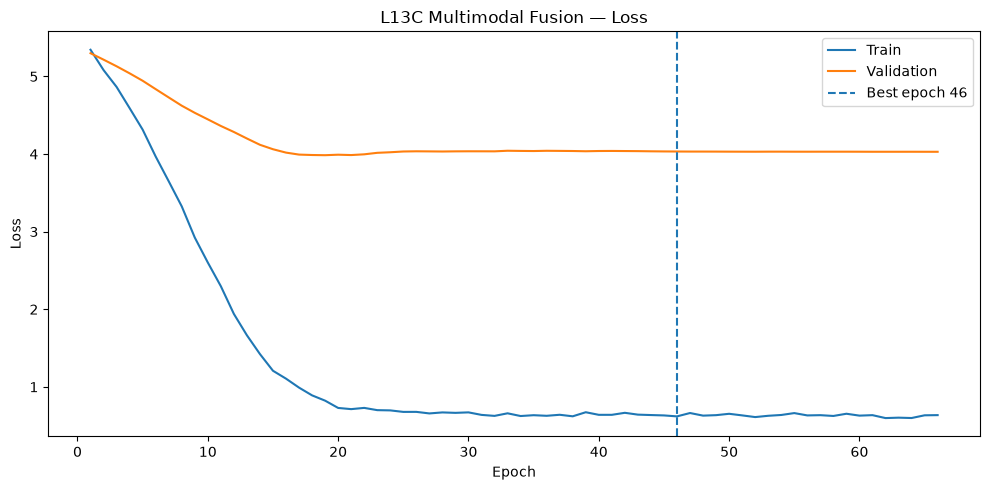

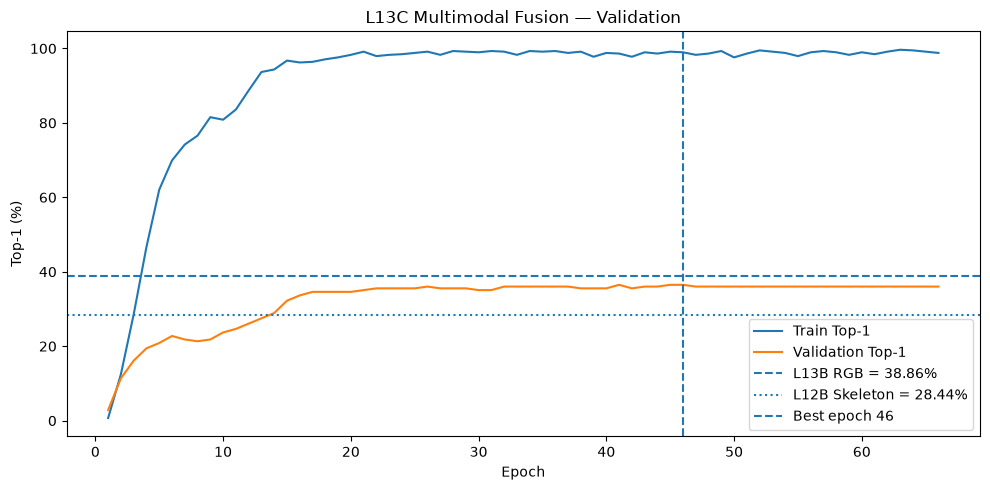


VALIDATION COMPARISON

experiment                           model      top1      top5
     L10.0                             GRU  7.109005 13.744076
     L11.0                          BiLSTM  8.530806 17.535545
     L10.2                    Enhanced GRU  3.791469  6.635071
      L12A                          ST-GCN 18.009479 27.962085
      L12B                      SSL ST-GCN 28.436019 37.914692
      L13B        RGB Temporal Transformer 38.862559 46.445498
      L13C Quality-Aware Multimodal Fusion 36.492891 44.075829

L13C FINAL REPORT

REPRESENTATION
--------------------------------------------------------------------------------------------------------------------------------------------
Skeleton encoder           : L12B SSL ST-GCN
Skeleton encoder frozen    : YES
Skeleton representation    : 128-D
RGB encoder                : L13B RGB Temporal Transformer
RGB encoder frozen         : YES
RGB input representation   : 32 × 576
RGB pooled representation  : 256-D
Fusion representat

In [12]:
# ==================================================================================================
# CISLR — L13C
# QUALITY-AWARE MULTIMODAL FUSION
#
# Frozen L12B SSL ST-GCN skeleton encoder (128-D)
#                  +
# Frozen L13B RGB Temporal Transformer (256-D)
#                  ↓
#        Quality-aware gated fusion
#                  ↓
#              211 classes
#
# TRAIN      : 585
# VALIDATION : 211
# TEST       : 211 — STRICTLY LOCKED
#
# ==================================================================================================

import os
import json
import time
import random
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt


# ==================================================================================================
# 0. CONFIG
# ==================================================================================================

SEED = 42

ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)

MODEL_ROOT = (
    ROOT /
    "CISLR_LANDMARK_MODEL"
)

L6_RAW_DIR = (
    MODEL_ROOT /
    "audit/l6_full_extraction/raw_sequences"
)

L9_ROOT = (
    MODEL_ROOT /
    "audit/l9_split_freeze"
)

TRAIN_MANIFEST = (
    L9_ROOT /
    "splits/l9_train_manifest.csv"
)

VAL_MANIFEST = (
    L9_ROOT /
    "splits/l9_validation_manifest.csv"
)

TEST_MANIFEST = (
    L9_ROOT /
    "splits/l9_test_manifest.csv"
)

CLASS_MAPPING_PATH = (
    L9_ROOT /
    "class_mapping/l9_controlled_class_mapping.json"
)


# --------------------------------------------------------------------------------------------------
# L12B
# --------------------------------------------------------------------------------------------------

L12B_ROOT = (
    MODEL_ROOT /
    "audit/l12b_ssl_stgcn"
)

L12B_MODEL_PATH = (
    L12B_ROOT /
    "models/l12b_best_stgcn.pt"
)


# --------------------------------------------------------------------------------------------------
# L13B
# --------------------------------------------------------------------------------------------------

L13B_ROOT = (
    MODEL_ROOT /
    "audit/l13_multimodal/l13_b_rgb_temporal"
)

L13B_MODEL_PATH = (
    L13B_ROOT /
    "models/l13b_best_rgb_temporal.pt"
)

RGB_CACHE_ROOT = (
    L13B_ROOT /
    "embedding_cache"
)

RGB_TRAIN_CACHE = (
    RGB_CACHE_ROOT /
    "train"
)

RGB_VAL_CACHE = (
    RGB_CACHE_ROOT /
    "validation"
)


# --------------------------------------------------------------------------------------------------
# L13C
# --------------------------------------------------------------------------------------------------

L13C_ROOT = (
    MODEL_ROOT /
    "audit/l13_multimodal/l13_c_multimodal_fusion"
)

MODEL_DIR = L13C_ROOT / "models"
REPORT_DIR = L13C_ROOT / "reports"
PLOT_DIR = L13C_ROOT / "plots"
CACHE_DIR = L13C_ROOT / "feature_cache"

for p in [
    MODEL_DIR,
    REPORT_DIR,
    PLOT_DIR,
    CACHE_DIR
]:
    p.mkdir(
        parents=True,
        exist_ok=True
    )


# --------------------------------------------------------------------------------------------------
# Architecture
# --------------------------------------------------------------------------------------------------

NUM_CLASSES = 211

SEQ_LEN = 32

NUM_HANDS = 2
JOINTS_PER_HAND = 21
NUM_NODES = 42

INPUT_CHANNELS = 11

SKELETON_DIM = 128

VISUAL_DIM = 576
RGB_MODEL_DIM = 256

FUSION_DIM = 256

BATCH_SIZE = 32

MAX_EPOCHS = 120

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 5e-4

DROPOUT = 0.35

LABEL_SMOOTHING = 0.05

EARLY_STOP_PATIENCE = 20

GRAD_CLIP = 5.0


# ==================================================================================================
# 1. REPRODUCIBILITY
# ==================================================================================================

def seed_everything(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)

        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


# ==================================================================================================
# 2. DEVICE
# ==================================================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = (
    DEVICE.type == "cuda"
)


print("=" * 140)
print("CISLR — L13C")
print("QUALITY-AWARE MULTIMODAL FUSION")
print("=" * 140)

print()
print("PyTorch :", torch.__version__)
print("Device  :", DEVICE)

if USE_AMP:

    print(
        "GPU     :",
        torch.cuda.get_device_name(0)
    )


# ==================================================================================================
# 3. REQUIRED FILES
# ==================================================================================================

required_paths = [

    L6_RAW_DIR,

    TRAIN_MANIFEST,
    VAL_MANIFEST,
    TEST_MANIFEST,

    CLASS_MAPPING_PATH,

    L12B_MODEL_PATH,

    L13B_MODEL_PATH,

    RGB_TRAIN_CACHE,
    RGB_VAL_CACHE
]


missing = [
    p
    for p in required_paths
    if not p.exists()
]


if missing:

    print()
    print("MISSING:")

    for p in missing:
        print(p)

    raise FileNotFoundError(
        "Required L13C input missing."
    )


print()
print("[PASS] Required paths exist.")


# ==================================================================================================
# 4. FROZEN L9 SPLIT
# ==================================================================================================

train_df = pd.read_csv(
    TRAIN_MANIFEST
)

val_df = pd.read_csv(
    VAL_MANIFEST
)

test_df = pd.read_csv(
    TEST_MANIFEST
)


for df in [
    train_df,
    val_df,
    test_df
]:

    df["uid"] = (
        df["uid"]
        .astype(str)
    )


train_uids = set(
    train_df["uid"]
)

val_uids = set(
    val_df["uid"]
)

test_uids = set(
    test_df["uid"]
)


assert len(train_df) == 585

assert len(val_df) == 211

assert len(test_df) == 211


assert not (
    train_uids &
    val_uids
)

assert not (
    train_uids &
    test_uids
)

assert not (
    val_uids &
    test_uids
)


print()
print("=" * 140)
print("FROZEN L9 SPLIT")
print("=" * 140)

print()
print("TRAIN      :", len(train_df))
print("VALIDATION :", len(val_df))
print("TEST       :", len(test_df), "(LOCKED)")

print()
print("[PASS] Zero UID overlap.")


# ==================================================================================================
# 5. CLASS MAPPING
# ==================================================================================================

with open(
    CLASS_MAPPING_PATH,
    "r"
) as f:

    mapping_json = json.load(f)


if (
    isinstance(mapping_json, dict)
    and
    "gloss_to_id" in mapping_json
):

    gloss_to_id = {

        str(k):
            int(v)

        for k, v in
        mapping_json[
            "gloss_to_id"
        ].items()
    }

else:

    # fallback only if JSON itself is mapping
    gloss_to_id = {

        str(k):
            int(v)

        for k, v
        in mapping_json.items()
    }


assert len(
    gloss_to_id
) == NUM_CLASSES


assert sorted(
    gloss_to_id.values()
) == list(
    range(NUM_CLASSES)
)


id_to_gloss = {

    int(v):
        str(k)

    for k, v
    in gloss_to_id.items()
}


print(
    "[PASS] Frozen L9 211-class mapping."
)


# ==================================================================================================
# 6. LABEL UTILITY
# ==================================================================================================

def label_from_row(row):

    if "class_id" in row.index:

        return int(
            row["class_id"]
        )

    gloss = str(
        row["gloss"]
    )

    return int(
        gloss_to_id[
            gloss
        ]
    )


# ==================================================================================================
# 7. EXACT L12B HAND GRAPH
# ==================================================================================================

HAND_EDGES = [

    (0,1),
    (1,2),
    (2,3),
    (3,4),

    (0,5),
    (5,6),
    (6,7),
    (7,8),

    (5,9),
    (9,10),
    (10,11),
    (11,12),

    (9,13),
    (13,14),
    (14,15),
    (15,16),

    (13,17),
    (17,18),
    (18,19),
    (19,20),

    (0,17)
]


def normalize_adjacency(A):

    A = A.astype(
        np.float32
    )

    degree = A.sum(
        axis=0
    )

    degree[
        degree < 1e-6
    ] = 1.0

    return (
        A /
        degree[
            None,
            :
        ]
    )


def build_graph():

    A_self = np.eye(
        NUM_NODES,
        dtype=np.float32
    )

    A_in = np.zeros(
        (
            NUM_NODES,
            NUM_NODES
        ),
        dtype=np.float32
    )

    A_out = np.zeros_like(
        A_in
    )


    for hand in range(2):

        offset = (
            hand *
            JOINTS_PER_HAND
        )

        for parent, child in HAND_EDGES:

            p = parent + offset

            c = child + offset

            A_in[
                c,
                p
            ] = 1.0

            A_out[
                p,
                c
            ] = 1.0


    A_self = normalize_adjacency(
        A_self
    )

    A_in = normalize_adjacency(
        A_in
    )

    A_out = normalize_adjacency(
        A_out
    )


    return np.stack(

        [
            A_self,
            A_in,
            A_out
        ],

        axis=0
    )


A = build_graph()


assert A.shape == (
    3,
    42,
    42
)


A_tensor = torch.tensor(

    A,

    dtype=torch.float32,

    device=DEVICE
)


print()
print("[PASS] L12B adjacency reconstructed.")


# ==================================================================================================
# 8. EXACT L12B TEMPORAL UTILITIES
# ==================================================================================================

def uniform_indices(
    length,
    target_length=32
):

    if length <= 0:

        return np.zeros(
            target_length,
            dtype=np.int64
        )


    idx = np.linspace(
        0,
        length - 1,
        target_length
    )


    idx = np.round(
        idx
    ).astype(
        np.int64
    )


    return np.clip(
        idx,
        0,
        length - 1
    )


def interpolate_short_gaps(
    data,
    mask,
    max_gap=3
):

    data = data.copy()

    mask = (
        mask.copy()
        .astype(
            np.uint8
        )
    )


    T, H = mask.shape


    for h in range(H):

        valid = np.where(
            mask[:, h] > 0
        )[0]


        if len(valid) < 2:
            continue


        for a, b in zip(
            valid[:-1],
            valid[1:]
        ):

            gap = (
                b -
                a -
                1
            )


            if (
                gap <= 0
                or
                gap > max_gap
            ):
                continue


            for k in range(
                1,
                gap + 1
            ):

                alpha = (
                    k /
                    (gap + 1)
                )


                data[
                    a + k,
                    h
                ] = (

                    (1.0 - alpha)
                    *
                    data[
                        a,
                        h
                    ]

                    +

                    alpha
                    *
                    data[
                        b,
                        h
                    ]
                )


                mask[
                    a + k,
                    h
                ] = 1


    return (
        data,
        mask
    )


# ==================================================================================================
# 9. EXACT L12B RAW -> GRAPH
# ==================================================================================================

def raw_to_graph(
    npz_path
):

    with np.load(
        npz_path,
        allow_pickle=True
    ) as d:

        uid = str(
            d["uid"].item()
        )

        landmarks_px = (
            d["landmarks_px"]
            .astype(
                np.float32
            )
        )

        world = (
            d["world_landmarks"]
            .astype(
                np.float32
            )
        )

        hand_mask = (
            d["hand_mask"]
            .astype(
                np.uint8
            )
        )

        width = float(
            d["width"].item()
        )

        height = float(
            d["height"].item()
        )


    if landmarks_px.ndim != 4:

        raise ValueError(
            f"Bad landmarks: {uid}"
        )


    if world.shape != landmarks_px.shape:

        raise ValueError(
            f"World/image mismatch: {uid}"
        )


    T = landmarks_px.shape[0]


    if hand_mask.shape != (
        T,
        2
    ):

        raise ValueError(
            f"Bad mask: {uid}"
        )


    # ----------------------------------------------------------------------------------------------
    # short-gap repair
    # ----------------------------------------------------------------------------------------------

    world, repaired_mask = (
        interpolate_short_gaps(

            world,

            hand_mask,

            max_gap=3
        )
    )


    image = landmarks_px.copy()


    image, _ = (
        interpolate_short_gaps(

            image,

            hand_mask,

            max_gap=3
        )
    )


    # ----------------------------------------------------------------------------------------------
    # world XYZ
    # ----------------------------------------------------------------------------------------------

    world_norm = np.zeros_like(
        world,
        dtype=np.float32
    )


    MCP = [
        5,
        9,
        13,
        17
    ]


    for t in range(T):

        for h in range(2):

            if repaired_mask[
                t,
                h
            ] == 0:

                continue


            pts = (
                world[
                    t,
                    h
                ]
                .copy()
            )


            wrist = (
                pts[0]
                .copy()
            )


            centered = (
                pts -
                wrist
            )


            scale = np.mean(

                np.linalg.norm(

                    centered[
                        MCP
                    ],

                    axis=1
                )
            )


            if (
                not np.isfinite(
                    scale
                )
                or
                scale < 1e-5
            ):

                scale = 1.0


            world_norm[
                t,
                h
            ] = (

                centered /
                scale
            )


    # ----------------------------------------------------------------------------------------------
    # global image XY
    # ----------------------------------------------------------------------------------------------

    image_xy = np.zeros(

        (
            T,
            2,
            21,
            2
        ),

        dtype=np.float32
    )


    for t in range(T):

        for h in range(2):

            if repaired_mask[
                t,
                h
            ] == 0:

                continue


            image_xy[
                t,
                h,
                :,
                0
            ] = (

                image[
                    t,
                    h,
                    :,
                    0
                ]
                /
                max(
                    width,
                    1.0
                )

                -
                0.5
            )


            image_xy[
                t,
                h,
                :,
                1
            ] = (

                image[
                    t,
                    h,
                    :,
                    1
                ]
                /
                max(
                    height,
                    1.0
                )

                -
                0.5
            )


    # ----------------------------------------------------------------------------------------------
    # velocity
    # ----------------------------------------------------------------------------------------------

    world_vel = np.zeros_like(
        world_norm,
        dtype=np.float32
    )


    image_vel = np.zeros_like(
        image_xy,
        dtype=np.float32
    )


    for t in range(
        1,
        T
    ):

        for h in range(2):

            if (

                repaired_mask[
                    t,
                    h
                ] > 0

                and

                repaired_mask[
                    t - 1,
                    h
                ] > 0
            ):

                world_vel[
                    t,
                    h
                ] = (

                    world_norm[
                        t,
                        h
                    ]

                    -

                    world_norm[
                        t - 1,
                        h
                    ]
                )


                image_vel[
                    t,
                    h
                ] = (

                    image_xy[
                        t,
                        h
                    ]

                    -

                    image_xy[
                        t - 1,
                        h
                    ]
                )


    # ----------------------------------------------------------------------------------------------
    # 32 frames
    # ----------------------------------------------------------------------------------------------

    idx = uniform_indices(
        T,
        SEQ_LEN
    )


    world_norm = world_norm[
        idx
    ]

    world_vel = world_vel[
        idx
    ]

    image_xy = image_xy[
        idx
    ]

    image_vel = image_vel[
        idx
    ]

    sampled_mask = repaired_mask[
        idx
    ]


    # ----------------------------------------------------------------------------------------------
    # 42 nodes
    # ----------------------------------------------------------------------------------------------

    world_norm = world_norm.reshape(
        SEQ_LEN,
        NUM_NODES,
        3
    )


    world_vel = world_vel.reshape(
        SEQ_LEN,
        NUM_NODES,
        3
    )


    image_xy = image_xy.reshape(
        SEQ_LEN,
        NUM_NODES,
        2
    )


    image_vel = image_vel.reshape(
        SEQ_LEN,
        NUM_NODES,
        2
    )


    node_mask = np.repeat(

        sampled_mask[
            :,
            :,
            None
        ],

        JOINTS_PER_HAND,

        axis=2

    ).reshape(

        SEQ_LEN,
        NUM_NODES

    ).astype(
        np.float32
    )


    m = node_mask[
        ...,
        None
    ]


    world_norm *= m

    world_vel *= m

    image_xy *= m

    image_vel *= m


    graph = np.concatenate(

        [
            world_norm,
            world_vel,
            image_xy,
            image_vel,
            node_mask[
                ...,
                None
            ]
        ],

        axis=-1
    )


    graph = np.transpose(

        graph,

        (
            2,
            0,
            1
        )

    ).astype(
        np.float32
    )


    if graph.shape != (
        11,
        32,
        42
    ):

        raise RuntimeError(
            f"Bad graph {uid}: {graph.shape}"
        )


    if not np.isfinite(
        graph
    ).all():

        raise RuntimeError(
            f"NaN/Inf graph: {uid}"
        )


    # quality for fusion
    hand_presence = (
        sampled_mask > 0
    )


    any_hand = float(

        np.mean(

            np.any(
                hand_presence,
                axis=1
            )
        )
    )


    both_hands = float(

        np.mean(

            np.all(
                hand_presence,
                axis=1
            )
        )
    )


    track0 = float(
        np.mean(
            hand_presence[
                :,
                0
            ]
        )
    )


    track1 = float(
        np.mean(
            hand_presence[
                :,
                1
            ]
        )
    )


    quality = np.asarray(

        [
            any_hand,
            both_hands,
            track0,
            track1
        ],

        dtype=np.float32
    )


    return (
        graph,
        quality,
        uid
    )


# ==================================================================================================
# 10. INDEX L6 RAW FILES
# ==================================================================================================

print()
print("=" * 140)
print("INDEXING L6 RAW SEQUENCES")
print("=" * 140)


raw_files = sorted(
    L6_RAW_DIR.glob(
        "*.npz"
    )
)


uid_to_raw = {}


for i, path in enumerate(
    raw_files,
    start=1
):

    try:

        with np.load(
            path,
            allow_pickle=True
        ) as d:

            uid = str(
                d["uid"].item()
            )


        uid_to_raw[
            uid
        ] = path


    except Exception as e:

        print(
            "[WARNING]",
            path.name,
            e
        )


    if (
        i % 1000 == 0
        or
        i == len(raw_files)
    ):

        print(
            f"{i}/{len(raw_files)}"
        )


print(
    "Indexed:",
    len(uid_to_raw)
)


# ==================================================================================================
# 11. LOAD L12B CHECKPOINT
# ==================================================================================================

l12b_checkpoint = torch.load(

    L12B_MODEL_PATH,

    map_location=DEVICE,

    weights_only=False
)


l12b_mean = np.asarray(

    l12b_checkpoint[
        "channel_mean"
    ],

    dtype=np.float32
)


l12b_std = np.asarray(

    l12b_checkpoint[
        "channel_std"
    ],

    dtype=np.float32
)


assert l12b_mean.shape == (
    10,
)

assert l12b_std.shape == (
    10,
)


checkpoint_A = np.asarray(

    l12b_checkpoint[
        "adjacency"
    ],

    dtype=np.float32
)


assert np.allclose(
    A,
    checkpoint_A
)


print()
print(
    "[PASS] L12B preprocessing loaded from checkpoint."
)


# ==================================================================================================
# 12. EXACT L12B NORMALIZATION
# ==================================================================================================

def normalize_graph(
    graph
):

    X = graph.copy()


    mask = X[
        10:11
    ]


    for c in range(10):

        X[
            c:c+1
        ] = (

            X[
                c:c+1
            ]

            -

            l12b_mean[
                c
            ]

        ) / l12b_std[
            c
        ]


        X[
            c:c+1
        ] *= mask


    X[
        10:11
    ] = mask


    return X.astype(
        np.float32
    )


# ==================================================================================================
# 13. EXACT L12B ST-GCN
# ==================================================================================================

class GraphConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        num_partitions=3
    ):

        super().__init__()


        self.num_partitions = (
            num_partitions
        )

        self.out_channels = (
            out_channels
        )


        self.conv = nn.Conv2d(

            in_channels,

            out_channels *
            num_partitions,

            kernel_size=1,

            bias=False
        )


    def forward(
        self,
        x,
        A
    ):

        x = self.conv(
            x
        )


        N, KC, T, V = (
            x.shape
        )


        x = x.view(

            N,

            self.num_partitions,

            self.out_channels,

            T,

            V
        )


        x = torch.einsum(

            "nkctv,kvw->nctw",

            x,

            A
        )


        return x.contiguous()


class STGCNBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        dropout=0.35
    ):

        super().__init__()


        self.gcn = GraphConv(

            in_channels,

            out_channels,

            num_partitions=3
        )


        self.gcn_bn = nn.BatchNorm2d(
            out_channels
        )


        self.temporal = nn.Sequential(

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(

                out_channels,

                out_channels,

                kernel_size=(
                    9,
                    1
                ),

                padding=(
                    4,
                    0
                ),

                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.Dropout(
                dropout
            )
        )


        if (
            in_channels ==
            out_channels
        ):

            self.residual = (
                nn.Identity()
            )

        else:

            self.residual = nn.Sequential(

                nn.Conv2d(

                    in_channels,

                    out_channels,

                    kernel_size=1,

                    bias=False
                ),

                nn.BatchNorm2d(
                    out_channels
                )
            )


        self.relu = nn.ReLU(
            inplace=True
        )


    def forward(
        self,
        x,
        A
    ):

        residual = self.residual(
            x
        )


        x = self.gcn(
            x,
            A
        )


        x = self.gcn_bn(
            x
        )


        x = self.temporal(
            x
        )


        x = (
            x +
            residual
        )


        return self.relu(
            x
        )


class STGCNEncoder(nn.Module):

    def __init__(
        self,
        in_channels=11,
        dropout=0.35
    ):

        super().__init__()


        self.input_bn = nn.BatchNorm1d(

            in_channels *
            NUM_NODES
        )


        self.block1 = STGCNBlock(

            in_channels,

            64,

            dropout=(
                dropout *
                0.5
            )
        )


        self.block2 = STGCNBlock(

            64,

            64,

            dropout=dropout
        )


        self.block3 = STGCNBlock(

            64,

            128,

            dropout=dropout
        )


        self.block4 = STGCNBlock(

            128,

            128,

            dropout=dropout
        )


        self.output_norm = nn.LayerNorm(
            128
        )


    def forward(
        self,
        x,
        A
    ):

        N, C, T, V = (
            x.shape
        )


        y = x.permute(
            0,
            3,
            1,
            2
        ).contiguous()


        y = y.view(
            N,
            V * C,
            T
        )


        y = self.input_bn(
            y
        )


        y = y.view(
            N,
            V,
            C,
            T
        )


        x = y.permute(
            0,
            2,
            3,
            1
        ).contiguous()


        x = self.block1(
            x,
            A
        )

        x = self.block2(
            x,
            A
        )

        x = self.block3(
            x,
            A
        )

        x = self.block4(
            x,
            A
        )


        mask = (

            y.view(
                N,
                V,
                C,
                T
            )

            [
                :,
                :,
                10,
                :
            ]
        )


        mask = mask.permute(
            0,
            2,
            1
        ).unsqueeze(
            1
        )


        mask = (
            mask > 0.5
        ).float()


        weighted = (
            x *
            mask
        )


        denom = (

            mask.sum(
                dim=(
                    2,
                    3
                )
            )

            .clamp(
                min=1.0
            )
        )


        pooled = (

            weighted.sum(
                dim=(
                    2,
                    3
                )
            )

            /

            denom
        )


        pooled = self.output_norm(
            pooled
        )


        return pooled


class STGCNClassifier(nn.Module):

    def __init__(
        self,
        num_classes=211
    ):

        super().__init__()


        self.encoder = STGCNEncoder(

            in_channels=11,

            dropout=0.35
        )


        self.dropout = nn.Dropout(
            0.35
        )


        self.classifier = nn.Linear(
            128,
            num_classes
        )


    def forward(
        self,
        x,
        A
    ):

        features = self.encoder(
            x,
            A
        )


        features = self.dropout(
            features
        )


        return self.classifier(
            features
        )


# ==================================================================================================
# 14. LOAD EXACT L12B
# ==================================================================================================

skeleton_model = (
    STGCNClassifier(
        NUM_CLASSES
    )
    .to(
        DEVICE
    )
)


result = skeleton_model.load_state_dict(

    l12b_checkpoint[
        "model_state_dict"
    ],

    strict=True
)


assert len(
    result.missing_keys
) == 0


assert len(
    result.unexpected_keys
) == 0


skeleton_model.eval()


for p in skeleton_model.parameters():

    p.requires_grad = False


print()
print("[PASS] Exact frozen L12B model loaded.")


# ==================================================================================================
# 15. L13B RGB CACHE — CORRECTED DIRECTORY STRUCTURE
# ==================================================================================================

print()
print("=" * 140)
print("L13B RGB CACHE")
print("=" * 140)


rgb_train_files = sorted(
    RGB_TRAIN_CACHE.glob(
        "*.npz"
    )
)


rgb_val_files = sorted(
    RGB_VAL_CACHE.glob(
        "*.npz"
    )
)


print()
print(
    "Train cache      :",
    len(rgb_train_files)
)

print(
    "Validation cache :",
    len(rgb_val_files)
)


assert len(
    rgb_train_files
) == 585


assert len(
    rgb_val_files
) == 211


uid_to_rgb_train = {

    p.stem:
        p

    for p in rgb_train_files
}


uid_to_rgb_val = {

    p.stem:
        p

    for p in rgb_val_files
}


# Better: use UID stored inside NPZ rather than assume filename

uid_to_rgb_train = {}

for p in rgb_train_files:

    with np.load(
        p,
        allow_pickle=True
    ) as d:

        uid = str(
            d["uid"].item()
        )

    uid_to_rgb_train[
        uid
    ] = p


uid_to_rgb_val = {}

for p in rgb_val_files:

    with np.load(
        p,
        allow_pickle=True
    ) as d:

        uid = str(
            d["uid"].item()
        )

    uid_to_rgb_val[
        uid
    ] = p


assert len(
    uid_to_rgb_train
) == 585


assert len(
    uid_to_rgb_val
) == 211


assert not (
    set(
        uid_to_rgb_train
    )
    &
    test_uids
)


assert not (
    set(
        uid_to_rgb_val
    )
    &
    test_uids
)


print()
print("[PASS] 585 train RGB caches.")
print("[PASS] 211 validation RGB caches.")
print("[PASS] No L9 test UID in RGB cache used by L13C.")


# ==================================================================================================
# 16. RGB CACHE READER
# ==================================================================================================

def read_rgb_cache(
    path
):

    with np.load(
        path,
        allow_pickle=True
    ) as d:

        uid = str(
            d["uid"].item()
        )

        embeddings = (
            d["embeddings"]
            .astype(
                np.float32
            )
        )

        class_id = int(
            d["class_id"].item()
        )


    if embeddings.shape != (
        32,
        576
    ):

        raise RuntimeError(

            f"Bad RGB shape {uid}: "
            f"{embeddings.shape}"
        )


    if not np.isfinite(
        embeddings
    ).all():

        raise RuntimeError(
            f"RGB NaN/Inf: {uid}"
        )


    return (
        uid,
        embeddings,
        class_id
    )


# ==================================================================================================
# 17. EXACT L13B MODEL
# ==================================================================================================

class LearnablePositionalEncoding(
    nn.Module
):

    def __init__(
        self,
        sequence_length,
        model_dim
    ):

        super().__init__()


        self.position = nn.Parameter(

            torch.zeros(

                1,

                sequence_length,

                model_dim
            )
        )


        nn.init.trunc_normal_(

            self.position,

            std=0.02
        )


    def forward(
        self,
        x
    ):

        return (

            x +

            self.position[
                :,
                :x.size(1)
            ]
        )


class RGBTemporalTransformer(
    nn.Module
):

    def __init__(

        self,

        input_dim=576,

        model_dim=256,

        num_heads=4,

        num_layers=2,

        ff_dim=512,

        num_classes=211,

        dropout=0.35,

        sequence_length=32
    ):

        super().__init__()


        self.input_norm = nn.LayerNorm(
            input_dim
        )


        self.input_projection = nn.Linear(

            input_dim,

            model_dim
        )


        self.position = (
            LearnablePositionalEncoding(

                sequence_length,

                model_dim
            )
        )


        encoder_layer = (
            nn.TransformerEncoderLayer(

                d_model=model_dim,

                nhead=num_heads,

                dim_feedforward=ff_dim,

                dropout=dropout,

                activation="gelu",

                batch_first=True,

                norm_first=True
            )
        )


        self.transformer = (
            nn.TransformerEncoder(

                encoder_layer,

                num_layers=num_layers
            )
        )


        self.temporal_attention = (
            nn.Sequential(

                nn.Linear(
                    model_dim,
                    128
                ),

                nn.Tanh(),

                nn.Linear(
                    128,
                    1
                )
            )
        )


        self.output_norm = nn.LayerNorm(
            model_dim
        )


        self.dropout = nn.Dropout(
            dropout
        )


        self.classifier = nn.Linear(

            model_dim,

            num_classes
        )


    def encode(
        self,
        x
    ):

        # Exact L13B representation up to output_norm.
        # Dropout is intentionally excluded here because the frozen
        # representation should be deterministic.

        x = self.input_norm(
            x
        )


        x = self.input_projection(
            x
        )


        x = self.position(
            x
        )


        x = self.transformer(
            x
        )


        attention_logits = (

            self.temporal_attention(
                x
            )

            .squeeze(
                -1
            )
        )


        attention = torch.softmax(

            attention_logits,

            dim=1
        )


        pooled = torch.sum(

            x *

            attention.unsqueeze(
                -1
            ),

            dim=1
        )


        pooled = self.output_norm(
            pooled
        )


        return (
            pooled,
            attention
        )


    def forward(
        self,
        x,
        return_attention=False
    ):

        pooled, attention = (
            self.encode(
                x
            )
        )


        pooled = self.dropout(
            pooled
        )


        logits = self.classifier(
            pooled
        )


        if return_attention:

            return (
                logits,
                attention
            )


        return logits


# ==================================================================================================
# 18. LOAD EXACT L13B CHECKPOINT
# ==================================================================================================

l13b_checkpoint = torch.load(

    L13B_MODEL_PATH,

    map_location=DEVICE,

    weights_only=False
)


assert int(
    l13b_checkpoint[
        "sequence_length"
    ]
) == 32


assert int(
    l13b_checkpoint[
        "visual_dim"
    ]
) == 576


assert int(
    l13b_checkpoint[
        "model_dim"
    ]
) == 256


assert int(
    l13b_checkpoint[
        "num_heads"
    ]
) == 4


assert int(
    l13b_checkpoint[
        "num_layers"
    ]
) == 2


assert int(
    l13b_checkpoint[
        "ff_dim"
    ]
) == 512


rgb_model = (
    RGBTemporalTransformer(

        input_dim=576,

        model_dim=256,

        num_heads=4,

        num_layers=2,

        ff_dim=512,

        num_classes=211,

        dropout=float(
            l13b_checkpoint[
                "dropout"
            ]
        ),

        sequence_length=32
    )
    .to(
        DEVICE
    )
)


load_result = rgb_model.load_state_dict(

    l13b_checkpoint[
        "model_state_dict"
    ],

    strict=True
)


assert len(
    load_result.missing_keys
) == 0


assert len(
    load_result.unexpected_keys
) == 0


rgb_model.eval()


for p in rgb_model.parameters():

    p.requires_grad = False


rgb_train_mean = np.asarray(

    l13b_checkpoint[
        "train_mean"
    ],

    dtype=np.float32
)


rgb_train_std = np.asarray(

    l13b_checkpoint[
        "train_std"
    ],

    dtype=np.float32
)


assert rgb_train_mean.shape == (
    576,
)


assert rgb_train_std.shape == (
    576,
)


print()
print("[PASS] Exact frozen L13B Transformer loaded.")


# ==================================================================================================
# 19. RGB STANDARDIZATION
# ==================================================================================================

def normalize_rgb(
    x
):

    x = (

        x -

        rgb_train_mean[
            None,
            :
        ]

    ) / rgb_train_std[
        None,
        :
    ]


    x = x.astype(
        np.float32
    )


    if not np.isfinite(
        x
    ).all():

        raise RuntimeError(
            "Non-finite normalized RGB."
        )


    return x


# ==================================================================================================
# 20. SANITY CHECK PRETRAINED BRANCHES
# ==================================================================================================

print()
print("=" * 140)
print("PRETRAINED BRANCH SANITY CHECK")
print("=" * 140)


# L13B one sample

sample_uid = str(
    val_df.iloc[0][
        "uid"
    ]
)


sample_path = (
    uid_to_rgb_val[
        sample_uid
    ]
)


_, sample_rgb, _ = (
    read_rgb_cache(
        sample_path
    )
)


sample_rgb = normalize_rgb(
    sample_rgb
)


with torch.no_grad():

    sample_tensor = (

        torch.from_numpy(
            sample_rgb
        )

        .unsqueeze(0)

        .to(
            DEVICE
        )
    )


    rgb_feature, _ = (
        rgb_model.encode(
            sample_tensor
        )
    )


assert rgb_feature.shape == (
    1,
    256
)


print(
    "[PASS] RGB feature shape:",
    tuple(
        rgb_feature.shape
    )
)


# L12B one sample

sample_raw = (
    uid_to_raw[
        sample_uid
    ]
)


sample_graph, _, _ = (
    raw_to_graph(
        sample_raw
    )
)


sample_graph = normalize_graph(
    sample_graph
)


with torch.no_grad():

    sample_tensor = (

        torch.from_numpy(
            sample_graph
        )

        .unsqueeze(0)

        .to(
            DEVICE
        )
    )


    skeleton_feature = (
        skeleton_model.encoder(

            sample_tensor,

            A_tensor
        )
    )


assert skeleton_feature.shape == (
    1,
    128
)


print(
    "[PASS] Skeleton feature shape:",
    tuple(
        skeleton_feature.shape
    )
)


# ==================================================================================================
# 21. BUILD FROZEN MULTIMODAL REPRESENTATIONS
# ==================================================================================================

def extract_split_features(
    df,
    rgb_index,
    split_name
):

    skeleton_features = []

    rgb_features = []

    quality_features = []

    labels = []

    uids = []


    print()
    print("=" * 140)
    print(
        f"EXTRACTING {split_name} MULTIMODAL FEATURES"
    )
    print("=" * 140)


    start_time = time.time()


    for i, (_, row) in enumerate(
        df.iterrows(),
        start=1
    ):

        uid = str(
            row["uid"]
        )


        # ------------------------------------------------------------------------------------------
        # HARD TEST GUARD
        # ------------------------------------------------------------------------------------------

        if uid in test_uids:

            raise RuntimeError(

                "TEST UID reached L13C feature extraction: "
                +
                uid
            )


        if uid not in uid_to_raw:

            raise RuntimeError(
                f"Missing L6 raw: {uid}"
            )


        if uid not in rgb_index:

            raise RuntimeError(
                f"Missing RGB cache: {uid}"
            )


        label = label_from_row(
            row
        )


        # ------------------------------------------------------------------------------------------
        # Skeleton
        # ------------------------------------------------------------------------------------------

        graph, quality, raw_uid = (
            raw_to_graph(

                uid_to_raw[
                    uid
                ]
            )
        )


        if raw_uid != uid:

            raise RuntimeError(
                f"Raw UID mismatch: {uid}"
            )


        graph = normalize_graph(
            graph
        )


        graph_tensor = (

            torch.from_numpy(
                graph
            )

            .unsqueeze(0)

            .to(
                DEVICE
            )
        )


        with torch.no_grad():

            sk = skeleton_model.encoder(

                graph_tensor,

                A_tensor
            )


        sk = (

            sk[0]

            .float()

            .cpu()

            .numpy()

            .astype(
                np.float32
            )
        )


        # ------------------------------------------------------------------------------------------
        # RGB
        # ------------------------------------------------------------------------------------------

        rgb_uid, rgb_seq, rgb_label = (
            read_rgb_cache(

                rgb_index[
                    uid
                ]
            )
        )


        if rgb_uid != uid:

            raise RuntimeError(
                f"RGB UID mismatch: {uid}"
            )


        if rgb_label != label:

            raise RuntimeError(

                f"Class mismatch {uid}: "
                f"manifest={label}, "
                f"RGB={rgb_label}"
            )


        rgb_seq = normalize_rgb(
            rgb_seq
        )


        rgb_tensor = (

            torch.from_numpy(
                rgb_seq
            )

            .unsqueeze(0)

            .to(
                DEVICE
            )
        )


        with torch.no_grad():

            rgb, _ = rgb_model.encode(
                rgb_tensor
            )


        rgb = (

            rgb[0]

            .float()

            .cpu()

            .numpy()

            .astype(
                np.float32
            )
        )


        # ------------------------------------------------------------------------------------------
        # verify
        # ------------------------------------------------------------------------------------------

        assert sk.shape == (
            128,
        )


        assert rgb.shape == (
            256,
        )


        assert quality.shape == (
            4,
        )


        if not np.isfinite(
            sk
        ).all():

            raise RuntimeError(
                f"Bad skeleton feature: {uid}"
            )


        if not np.isfinite(
            rgb
        ).all():

            raise RuntimeError(
                f"Bad RGB feature: {uid}"
            )


        skeleton_features.append(
            sk
        )


        rgb_features.append(
            rgb
        )


        quality_features.append(
            quality
        )


        labels.append(
            label
        )


        uids.append(
            uid
        )


        if (
            i % 50 == 0
            or
            i == len(df)
        ):

            elapsed = (
                time.time() -
                start_time
            )


            print(

                f"{i}/{len(df)} "
                f"| {elapsed:.1f}s"
            )


    skeleton_features = np.stack(
        skeleton_features
    ).astype(
        np.float32
    )


    rgb_features = np.stack(
        rgb_features
    ).astype(
        np.float32
    )


    quality_features = np.stack(
        quality_features
    ).astype(
        np.float32
    )


    labels = np.asarray(
        labels,
        dtype=np.int64
    )


    print()
    print(
        "Skeleton:",
        skeleton_features.shape
    )

    print(
        "RGB     :",
        rgb_features.shape
    )

    print(
        "Quality :",
        quality_features.shape
    )

    print(
        "Labels  :",
        labels.shape
    )


    return (

        skeleton_features,

        rgb_features,

        quality_features,

        labels,

        uids
    )


(
    train_sk,
    train_rgb,
    train_quality,
    y_train,
    train_uid_order

) = extract_split_features(

    train_df,

    uid_to_rgb_train,

    "TRAIN"
)


(
    val_sk,
    val_rgb,
    val_quality,
    y_val,
    val_uid_order

) = extract_split_features(

    val_df,

    uid_to_rgb_val,

    "VALIDATION"
)


assert train_sk.shape == (
    585,
    128
)


assert train_rgb.shape == (
    585,
    256
)


assert train_quality.shape == (
    585,
    4
)


assert val_sk.shape == (
    211,
    128
)


assert val_rgb.shape == (
    211,
    256
)


assert val_quality.shape == (
    211,
    4
)


# ==================================================================================================
# 22. TEST LOCK CHECK
# ==================================================================================================

assert not (
    set(
        train_uid_order
    )
    &
    test_uids
)


assert not (
    set(
        val_uid_order
    )
    &
    test_uids
)


print()
print("=" * 140)
print("TEST LOCK")
print("=" * 140)

print()
print("Test manifest              : VERIFIED")
print("Test skeleton extracted    : NO")
print("Test RGB cache read        : NO")
print("Test multimodal features   : NO")
print("Test evaluated             : NO")
print("Status                     : LOCKED")


# ==================================================================================================
# 23. SAVE FROZEN FEATURE CACHE
# ==================================================================================================

np.savez_compressed(

    CACHE_DIR /
    "l13c_train_features.npz",

    uid=np.asarray(
        train_uid_order
    ),

    skeleton=train_sk,

    rgb=train_rgb,

    quality=train_quality,

    labels=y_train
)


np.savez_compressed(

    CACHE_DIR /
    "l13c_validation_features.npz",

    uid=np.asarray(
        val_uid_order
    ),

    skeleton=val_sk,

    rgb=val_rgb,

    quality=val_quality,

    labels=y_val
)


print()
print("[PASS] L13C frozen feature cache saved.")


# ==================================================================================================
# 24. TRAIN-ONLY FEATURE STANDARDIZATION
#
# The frozen branch representations already contain normalization,
# but their numeric scales differ.
#
# Fit this SECOND-STAGE standardization on L13C TRAIN ONLY.
# ==================================================================================================

sk_mean = train_sk.mean(
    axis=0
).astype(
    np.float32
)


sk_std = train_sk.std(
    axis=0
).astype(
    np.float32
)


sk_std[
    sk_std < 1e-6
] = 1.0


rgb_feature_mean = train_rgb.mean(
    axis=0
).astype(
    np.float32
)


rgb_feature_std = train_rgb.std(
    axis=0
).astype(
    np.float32
)


rgb_feature_std[
    rgb_feature_std < 1e-6
] = 1.0


train_sk = (

    (
        train_sk -
        sk_mean
    )

    /
    sk_std

).astype(
    np.float32
)


val_sk = (

    (
        val_sk -
        sk_mean
    )

    /
    sk_std

).astype(
    np.float32
)


train_rgb = (

    (
        train_rgb -
        rgb_feature_mean
    )

    /
    rgb_feature_std

).astype(
    np.float32
)


val_rgb = (

    (
        val_rgb -
        rgb_feature_mean
    )

    /
    rgb_feature_std

).astype(
    np.float32
)


assert np.isfinite(
    train_sk
).all()


assert np.isfinite(
    train_rgb
).all()


assert np.isfinite(
    val_sk
).all()


assert np.isfinite(
    val_rgb
).all()


np.save(
    REPORT_DIR /
    "l13c_skeleton_mean.npy",
    sk_mean
)


np.save(
    REPORT_DIR /
    "l13c_skeleton_std.npy",
    sk_std
)


np.save(
    REPORT_DIR /
    "l13c_rgb_mean.npy",
    rgb_feature_mean
)


np.save(
    REPORT_DIR /
    "l13c_rgb_std.npy",
    rgb_feature_std
)


print()
print("=" * 140)
print("L13C TRAIN-ONLY FEATURE STANDARDIZATION")
print("=" * 140)

print()
print(
    "Skeleton train mean:",
    f"{train_sk.mean():.6f}"
)

print(
    "Skeleton train std :",
    f"{train_sk.std():.6f}"
)

print(
    "RGB train mean     :",
    f"{train_rgb.mean():.6f}"
)

print(
    "RGB train std      :",
    f"{train_rgb.std():.6f}"
)


# ==================================================================================================
# 25. DATASET
# ==================================================================================================

class MultimodalDataset(
    Dataset
):

    def __init__(

        self,

        skeleton,

        rgb,

        quality,

        labels,

        training=False
    ):

        self.skeleton = (
            torch.from_numpy(
                skeleton
            )
        )

        self.rgb = (
            torch.from_numpy(
                rgb
            )
        )

        self.quality = (
            torch.from_numpy(
                quality
            )
        )

        self.labels = (
            torch.from_numpy(
                labels
            )
        )

        self.training = (
            training
        )


    def __len__(
        self
    ):

        return len(
            self.labels
        )


    def __getitem__(
        self,
        index
    ):

        sk = self.skeleton[
            index
        ].clone()


        rgb = self.rgb[
            index
        ].clone()


        quality = self.quality[
            index
        ]


        label = self.labels[
            index
        ]


        # Mild modality dropout on TRAIN only.
        # Helps prevent the fusion head from simply memorizing one branch.

        if self.training:

            r = random.random()


            if r < 0.05:

                sk.zero_()


            elif r < 0.10:

                rgb.zero_()


        return (
            sk,
            rgb,
            quality,
            label
        )


train_dataset = (
    MultimodalDataset(

        train_sk,

        train_rgb,

        train_quality,

        y_train,

        training=True
    )
)


val_dataset = (
    MultimodalDataset(

        val_sk,

        val_rgb,

        val_quality,

        y_val,

        training=False
    )
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=USE_AMP
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=USE_AMP
)


# ==================================================================================================
# 26. QUALITY-AWARE GATED FUSION
# ==================================================================================================

class QualityAwareGatedFusion(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()


        # skeleton: 128 -> 256

        self.skeleton_projection = (
            nn.Sequential(

                nn.Linear(
                    128,
                    256
                ),

                nn.LayerNorm(
                    256
                ),

                nn.GELU(),

                nn.Dropout(
                    0.25
                )
            )
        )


        # RGB already 256, but learn a small adaptation layer

        self.rgb_projection = (
            nn.Sequential(

                nn.Linear(
                    256,
                    256
                ),

                nn.LayerNorm(
                    256
                ),

                nn.GELU(),

                nn.Dropout(
                    0.25
                )
            )
        )


        # hand quality: 4 -> 32

        self.quality_encoder = (
            nn.Sequential(

                nn.Linear(
                    4,
                    32
                ),

                nn.GELU(),

                nn.Dropout(
                    0.10
                ),

                nn.Linear(
                    32,
                    32
                ),

                nn.GELU()
            )
        )


        # scalar gate is deliberately used rather than 256 independent
        # gates because supervised data is very small.
        #
        # gate = 1 -> skeleton
        # gate = 0 -> RGB

        self.gate_network = (
            nn.Sequential(

                nn.Linear(
                    256 +
                    256 +
                    32,
                    128
                ),

                nn.GELU(),

                nn.Dropout(
                    0.20
                ),

                nn.Linear(
                    128,
                    1
                ),

                nn.Sigmoid()
            )
        )


        self.fusion_norm = (
            nn.LayerNorm(
                256
            )
        )


        self.fusion_head = (
            nn.Sequential(

                nn.Linear(
                    256,
                    256
                ),

                nn.GELU(),

                nn.Dropout(
                    DROPOUT
                )
            )
        )


        self.classifier = (
            nn.Linear(
                256,
                NUM_CLASSES
            )
        )


    def forward(

        self,

        skeleton,

        rgb,

        quality,

        return_features=False
    ):

        sk = self.skeleton_projection(
            skeleton
        )


        rg = self.rgb_projection(
            rgb
        )


        q = self.quality_encoder(
            quality
        )


        gate_input = torch.cat(

            [
                sk,
                rg,
                q
            ],

            dim=1
        )


        skeleton_gate = (
            self.gate_network(
                gate_input
            )
        )


        fused = (

            skeleton_gate *
            sk

            +

            (
                1.0 -
                skeleton_gate
            )
            *
            rg
        )


        fused = self.fusion_norm(
            fused
        )


        fused = self.fusion_head(
            fused
        )


        logits = self.classifier(
            fused
        )


        if return_features:

            return (

                logits,

                skeleton_gate,

                fused
            )


        return logits


fusion_model = (
    QualityAwareGatedFusion()
    .to(
        DEVICE
    )
)


fusion_parameters = sum(

    p.numel()

    for p in
    fusion_model.parameters()
)


print()
print("=" * 140)
print("L13C MODEL")
print("=" * 140)

print()
print(fusion_model)

print()
print(
    "Trainable parameters:",
    f"{fusion_parameters:,}"
)

print()
print(
    "L12B encoder       : FROZEN"
)

print(
    "L13B encoder       : FROZEN"
)

print(
    "Fusion head        : TRAINABLE"
)


# ==================================================================================================
# 27. FORWARD SANITY
# ==================================================================================================

with torch.no_grad():

    sk = torch.from_numpy(
        train_sk[:4]
    ).to(
        DEVICE
    )


    rgb = torch.from_numpy(
        train_rgb[:4]
    ).to(
        DEVICE
    )


    q = torch.from_numpy(
        train_quality[:4]
    ).to(
        DEVICE
    )


    logits, gate, features = (
        fusion_model(

            sk,

            rgb,

            q,

            return_features=True
        )
    )


assert logits.shape == (
    4,
    211
)


assert gate.shape == (
    4,
    1
)


assert features.shape == (
    4,
    256
)


print()
print("[PASS] L13C forward.")
print("Logits :", tuple(logits.shape))
print("Gate   :", tuple(gate.shape))
print("Feature:", tuple(features.shape))


# ==================================================================================================
# 28. LOSS / OPTIMIZER
# ==================================================================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)


optimizer = torch.optim.AdamW(

    fusion_model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY
)


scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="min",

        factor=0.5,

        patience=6,

        min_lr=1e-6
    )
)


scaler = torch.amp.GradScaler(

    "cuda",

    enabled=USE_AMP
)


# ==================================================================================================
# 29. METRICS
# ==================================================================================================

def topk_counts(
    logits,
    targets
):

    _, pred = logits.topk(

        5,

        dim=1
    )


    correct = (

        pred ==

        targets.unsqueeze(
            1
        )
    )


    top1 = int(

        correct[
            :,
            :1
        ]

        .any(
            dim=1
        )

        .sum()

        .item()
    )


    top5 = int(

        correct

        .any(
            dim=1
        )

        .sum()

        .item()
    )


    return (
        top1,
        top5
    )


# ==================================================================================================
# 30. EPOCH
# ==================================================================================================

def run_epoch(
    loader,
    training
):

    if training:

        fusion_model.train()

    else:

        fusion_model.eval()


    total_loss = 0.0

    total_n = 0

    total_top1 = 0

    total_top5 = 0


    for (
        skeleton,
        rgb,
        quality,
        labels
    ) in loader:


        skeleton = skeleton.to(
            DEVICE,
            non_blocking=True
        )


        rgb = rgb.to(
            DEVICE,
            non_blocking=True
        )


        quality = quality.to(
            DEVICE,
            non_blocking=True
        )


        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        if training:

            optimizer.zero_grad(
                set_to_none=True
            )


        with torch.set_grad_enabled(
            training
        ):

            with torch.amp.autocast(

                device_type="cuda",

                enabled=USE_AMP
            ):

                logits = fusion_model(

                    skeleton,

                    rgb,

                    quality
                )


                loss = criterion(
                    logits,
                    labels
                )


            if not torch.isfinite(
                loss
            ):

                raise RuntimeError(
                    "Non-finite L13C loss."
                )


            if training:

                scaler.scale(
                    loss
                ).backward()


                scaler.unscale_(
                    optimizer
                )


                torch.nn.utils.clip_grad_norm_(

                    fusion_model.parameters(),

                    GRAD_CLIP
                )


                scaler.step(
                    optimizer
                )


                scaler.update()


        n = labels.size(
            0
        )


        top1, top5 = (
            topk_counts(
                logits,
                labels
            )
        )


        total_loss += (
            float(
                loss.item()
            )
            *
            n
        )


        total_n += n

        total_top1 += top1

        total_top5 += top5


    return {

        "loss":
            total_loss /
            total_n,

        "top1":
            100.0 *
            total_top1 /
            total_n,

        "top5":
            100.0 *
            total_top5 /
            total_n,

        "correct1":
            total_top1,

        "correct5":
            total_top5,

        "n":
            total_n
    }


# ==================================================================================================
# 31. OUTPUT PATHS
# ==================================================================================================

BEST_MODEL_PATH = (
    MODEL_DIR /
    "l13c_best_multimodal_fusion.pt"
)


LAST_MODEL_PATH = (
    MODEL_DIR /
    "l13c_last_multimodal_fusion.pt"
)


HISTORY_PATH = (
    REPORT_DIR /
    "l13c_training_history.csv"
)


PREDICTIONS_PATH = (
    REPORT_DIR /
    "l13c_validation_predictions.csv"
)


COMPARISON_PATH = (
    REPORT_DIR /
    "l13c_model_comparison.csv"
)


SUMMARY_PATH = (
    REPORT_DIR /
    "l13c_summary.json"
)


CHECKPOINT_PATH = (
    REPORT_DIR /
    "l13c_checkpoint.json"
)


# ==================================================================================================
# 32. TRAIN
# ==================================================================================================

history = []


best_top1 = -1.0

best_top5 = -1.0

best_loss = float(
    "inf"
)

best_epoch = 0

no_improvement = 0


print()
print("=" * 140)
print("STARTING L13C TRAINING")
print("=" * 140)

print()
print("TRAIN      :", 585)
print("VALIDATION :", 211)
print("TEST       :", 211, "(LOCKED)")

print()
print(
    "Current benchmark:"
)

print(
    "L12B Skeleton : Top-1 28.44% | Top-5 37.91%"
)

print(
    "L13B RGB      : Top-1 38.86% | Top-5 46.45%"
)

print()


training_start = time.time()


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = time.time()


    train_metrics = run_epoch(

        train_loader,

        training=True
    )


    val_metrics = run_epoch(

        val_loader,

        training=False
    )


    scheduler.step(
        val_metrics[
            "loss"
        ]
    )


    current_lr = (
        optimizer.param_groups[
            0
        ][
            "lr"
        ]
    )


    improved = False


    if (
        val_metrics[
            "top1"
        ]
        >
        best_top1 + 1e-12
    ):

        improved = True


    elif (

        abs(
            val_metrics[
                "top1"
            ]
            -
            best_top1
        )
        <=
        1e-12

        and

        val_metrics[
            "loss"
        ]
        <
        best_loss
    ):

        improved = True


    if improved:

        best_top1 = float(
            val_metrics[
                "top1"
            ]
        )


        best_top5 = float(
            val_metrics[
                "top5"
            ]
        )


        best_loss = float(
            val_metrics[
                "loss"
            ]
        )


        best_epoch = (
            epoch
        )


        no_improvement = 0


        torch.save(

            {
                "stage":
                    "L13C",

                "architecture":
                    "Quality-Aware Gated Multimodal Fusion",

                "epoch":
                    epoch,

                "model_state_dict":
                    deepcopy(
                        fusion_model.state_dict()
                    ),

                "best_val_top1":
                    best_top1,

                "best_val_top5":
                    best_top5,

                "best_val_loss":
                    best_loss,

                "skeleton_source":
                    str(
                        L12B_MODEL_PATH
                    ),

                "rgb_source":
                    str(
                        L13B_MODEL_PATH
                    ),

                "skeleton_dim":
                    128,

                "rgb_dim":
                    256,

                "fusion_dim":
                    256,

                "quality_dim":
                    4,

                "quality_features":
                    [
                        "any_hand_coverage",
                        "both_hand_coverage",
                        "track0_coverage",
                        "track1_coverage"
                    ],

                "skeleton_feature_mean":
                    sk_mean,

                "skeleton_feature_std":
                    sk_std,

                "rgb_feature_mean":
                    rgb_feature_mean,

                "rgb_feature_std":
                    rgb_feature_std,

                "gloss_to_id":
                    gloss_to_id,

                "id_to_gloss":
                    id_to_gloss,

                "l9_test_used":
                    False,

                "seed":
                    SEED
            },

            BEST_MODEL_PATH
        )


    else:

        no_improvement += 1


    elapsed = (
        time.time() -
        epoch_start
    )


    history.append(

        {
            "epoch":
                epoch,

            "train_loss":
                train_metrics[
                    "loss"
                ],

            "train_top1":
                train_metrics[
                    "top1"
                ],

            "train_top5":
                train_metrics[
                    "top5"
                ],

            "val_loss":
                val_metrics[
                    "loss"
                ],

            "val_top1":
                val_metrics[
                    "top1"
                ],

            "val_top5":
                val_metrics[
                    "top5"
                ],

            "learning_rate":
                current_lr,

            "seconds":
                elapsed,

            "best":
                improved
        }
    )


    marker = (
        "  <-- BEST"
        if improved
        else ""
    )


    print(

        f"Epoch {epoch:03d}/{MAX_EPOCHS} | "

        f"train loss={train_metrics['loss']:.4f} | "

        f"Top1={train_metrics['top1']:6.2f}% | "

        f"Top5={train_metrics['top5']:6.2f}% || "

        f"val loss={val_metrics['loss']:.4f} | "

        f"Top1={val_metrics['top1']:6.2f}% | "

        f"Top5={val_metrics['top5']:6.2f}% | "

        f"lr={current_lr:.2e} | "

        f"{elapsed:.2f}s"

        f"{marker}"
    )


    if (
        no_improvement
        >=
        EARLY_STOP_PATIENCE
    ):

        print()
        print(
            "[EARLY STOPPING]"
        )

        break


training_seconds = (
    time.time() -
    training_start
)


# ==================================================================================================
# 33. SAVE LAST
# ==================================================================================================

torch.save(

    {
        "stage":
            "L13C",

        "epoch":
            epoch,

        "model_state_dict":
            fusion_model.state_dict(),

        "l9_test_used":
            False
    },

    LAST_MODEL_PATH
)


# ==================================================================================================
# 34. HISTORY
# ==================================================================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(

    HISTORY_PATH,

    index=False
)


# ==================================================================================================
# 35. LOAD BEST
# ==================================================================================================

best_checkpoint = torch.load(

    BEST_MODEL_PATH,

    map_location=DEVICE,

    weights_only=False
)


fusion_model.load_state_dict(

    best_checkpoint[
        "model_state_dict"
    ],

    strict=True
)


fusion_model.eval()


# ==================================================================================================
# 36. EXACT FINAL VALIDATION
# ==================================================================================================

all_logits = []

all_targets = []

all_gates = []


with torch.no_grad():

    for (
        skeleton,
        rgb,
        quality,
        labels
    ) in val_loader:


        skeleton = skeleton.to(
            DEVICE
        )


        rgb = rgb.to(
            DEVICE
        )


        quality = quality.to(
            DEVICE
        )


        logits, gates, _ = (
            fusion_model(

                skeleton,

                rgb,

                quality,

                return_features=True
            )
        )


        all_logits.append(
            logits.float().cpu()
        )


        all_targets.append(
            labels.cpu()
        )


        all_gates.append(
            gates.float().cpu()
        )


all_logits = torch.cat(
    all_logits,
    dim=0
)


all_targets = torch.cat(
    all_targets,
    dim=0
)


all_gates = torch.cat(
    all_gates,
    dim=0
)


probabilities = torch.softmax(

    all_logits,

    dim=1
)


top5_prob, top5_idx = (
    probabilities.topk(
        5,
        dim=1
    )
)


predicted = (
    top5_idx[
        :,
        0
    ]
)


top1_correct = (

    predicted ==
    all_targets
)


top5_correct = (

    top5_idx ==

    all_targets.unsqueeze(
        1
    )

).any(
    dim=1
)


correct1 = int(
    top1_correct.sum().item()
)


correct5 = int(
    top5_correct.sum().item()
)


final_top1 = (
    100.0 *
    correct1 /
    211
)


final_top5 = (
    100.0 *
    correct5 /
    211
)


# ==================================================================================================
# 37. GATE ANALYSIS
# ==================================================================================================

gate_values = (

    all_gates[
        :,
        0
    ]
    .numpy()
)


mean_skeleton_gate = float(
    gate_values.mean()
)


mean_rgb_gate = (
    1.0 -
    mean_skeleton_gate
)


any_hand_quality = (
    val_quality[
        :,
        0
    ]
)


if (

    np.std(
        gate_values
    ) > 1e-8

    and

    np.std(
        any_hand_quality
    ) > 1e-8
):

    gate_quality_corr = float(

        np.corrcoef(

            gate_values,

            any_hand_quality
        )[0,1]
    )

else:

    gate_quality_corr = (
        float("nan")
    )


print()
print("=" * 140)
print("QUALITY-AWARE GATE ANALYSIS")
print("=" * 140)

print()
print(
    f"Mean skeleton contribution : "
    f"{100 * mean_skeleton_gate:.2f}%"
)

print(
    f"Mean RGB contribution      : "
    f"{100 * mean_rgb_gate:.2f}%"
)

print(
    f"Gate ↔ hand coverage corr  : "
    f"{gate_quality_corr:.4f}"
)


# ==================================================================================================
# 38. VALIDATION PREDICTIONS
# ==================================================================================================

prediction_rows = []


for i in range(
    211
):

    true_id = int(
        all_targets[
            i
        ]
    )


    pred_id = int(
        predicted[
            i
        ]
    )


    row = {

        "uid":
            val_uid_order[
                i
            ],

        "true_class_id":
            true_id,

        "true_gloss":
            id_to_gloss.get(
                true_id,
                str(
                    true_id
                )
            ),

        "predicted_class_id":
            pred_id,

        "predicted_gloss":
            id_to_gloss.get(
                pred_id,
                str(
                    pred_id
                )
            ),

        "top1_correct":
            int(
                top1_correct[
                    i
                ]
            ),

        "top5_correct":
            int(
                top5_correct[
                    i
                ]
            ),

        "skeleton_gate":
            float(
                gate_values[
                    i
                ]
            ),

        "rgb_gate":
            float(
                1.0 -
                gate_values[
                    i
                ]
            ),

        "any_hand_coverage":
            float(
                val_quality[
                    i,
                    0
                ]
            ),

        "both_hand_coverage":
            float(
                val_quality[
                    i,
                    1
                ]
            ),

        "track0_coverage":
            float(
                val_quality[
                    i,
                    2
                ]
            ),

        "track1_coverage":
            float(
                val_quality[
                    i,
                    3
                ]
            )
    }


    for k in range(5):

        cid = int(
            top5_idx[
                i,
                k
            ]
        )


        row[
            f"top{k+1}_class_id"
        ] = cid


        row[
            f"top{k+1}_gloss"
        ] = id_to_gloss.get(
            cid,
            str(
                cid
            )
        )


        row[
            f"top{k+1}_probability"
        ] = float(
            top5_prob[
                i,
                k
            ]
        )


    prediction_rows.append(
        row
    )


prediction_df = pd.DataFrame(
    prediction_rows
)


prediction_df.to_csv(

    PREDICTIONS_PATH,

    index=False
)


# ==================================================================================================
# 39. COMPARISON
# ==================================================================================================

comparison_df = pd.DataFrame(

    [
        [
            "L10.0",
            "GRU",
            7.109005,
            13.744076
        ],

        [
            "L11.0",
            "BiLSTM",
            8.530806,
            17.535545
        ],

        [
            "L10.2",
            "Enhanced GRU",
            3.791469,
            6.635071
        ],

        [
            "L12A",
            "ST-GCN",
            18.009479,
            27.962085
        ],

        [
            "L12B",
            "SSL ST-GCN",
            28.436019,
            37.914692
        ],

        [
            "L13B",
            "RGB Temporal Transformer",
            38.862559,
            46.445498
        ],

        [
            "L13C",
            "Quality-Aware Multimodal Fusion",
            final_top1,
            final_top5
        ]
    ],

    columns=[
        "experiment",
        "model",
        "top1",
        "top5"
    ]
)


comparison_df.to_csv(

    COMPARISON_PATH,

    index=False
)


# ==================================================================================================
# 40. TRAIN ACCURACY AT BEST EPOCH
# ==================================================================================================

best_row = (

    history_df[
        history_df[
            "epoch"
        ] == best_epoch
    ]

    .iloc[
        0
    ]
)


train_top1_at_best = float(
    best_row[
        "train_top1"
    ]
)


generalization_gap = (
    train_top1_at_best -
    final_top1
)


# ==================================================================================================
# 41. PLOTS
# ==================================================================================================

plt.figure(
    figsize=(
        10,
        5
    )
)


plt.plot(

    history_df[
        "epoch"
    ],

    history_df[
        "train_loss"
    ],

    label="Train"
)


plt.plot(

    history_df[
        "epoch"
    ],

    history_df[
        "val_loss"
    ],

    label="Validation"
)


plt.axvline(

    best_epoch,

    linestyle="--",

    label=(
        f"Best epoch {best_epoch}"
    )
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "L13C Multimodal Fusion — Loss"
)

plt.legend()

plt.tight_layout()


LOSS_PLOT = (
    PLOT_DIR /
    "l13c_loss_curve.png"
)


plt.savefig(
    LOSS_PLOT,
    dpi=160
)

plt.show()


plt.figure(
    figsize=(
        10,
        5
    )
)


plt.plot(

    history_df[
        "epoch"
    ],

    history_df[
        "train_top1"
    ],

    label="Train Top-1"
)


plt.plot(

    history_df[
        "epoch"
    ],

    history_df[
        "val_top1"
    ],

    label="Validation Top-1"
)


plt.axhline(

    38.862559,

    linestyle="--",

    label="L13B RGB = 38.86%"
)


plt.axhline(

    28.436019,

    linestyle=":",

    label="L12B Skeleton = 28.44%"
)


plt.axvline(

    best_epoch,

    linestyle="--",

    label=(
        f"Best epoch {best_epoch}"
    )
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Top-1 (%)"
)

plt.title(
    "L13C Multimodal Fusion — Validation"
)

plt.legend()

plt.tight_layout()


ACCURACY_PLOT = (
    PLOT_DIR /
    "l13c_accuracy_curve.png"
)


plt.savefig(
    ACCURACY_PLOT,
    dpi=160
)

plt.show()


# ==================================================================================================
# 42. SUMMARY
# ==================================================================================================

summary = {

    "stage":
        "L13C",

    "architecture":
        "Quality-Aware Gated Multimodal Fusion",

    "skeleton": {

        "source":
            "L12B SSL ST-GCN",

        "frozen":
            True,

        "dimension":
            128
    },

    "rgb": {

        "source":
            "L13B RGB Temporal Transformer",

        "frozen":
            True,

        "frame_representation":
            "32x576",

        "pooled_dimension":
            256
    },

    "fusion": {

        "dimension":
            256,

        "quality_features":
            4,

        "mean_skeleton_gate":
            mean_skeleton_gate,

        "mean_rgb_gate":
            mean_rgb_gate,

        "gate_quality_correlation":
            gate_quality_corr
    },

    "train": {

        "samples":
            585,

        "top1_at_best":
            train_top1_at_best
    },

    "validation": {

        "samples":
            211,

        "best_epoch":
            int(
                best_epoch
            ),

        "top1":
            final_top1,

        "top1_correct":
            correct1,

        "top5":
            final_top5,

        "top5_correct":
            correct5,

        "generalization_gap":
            generalization_gap
    },

    "comparison": {

        "l12b_top1":
            28.436019,

        "l13b_top1":
            38.862559,

        "l13c_top1":
            final_top1,

        "delta_vs_l12b":
            (
                final_top1 -
                28.436019
            ),

        "delta_vs_l13b":
            (
                final_top1 -
                38.862559
            )
    },

    "test": {

        "samples":
            211,

        "skeleton_loaded":
            False,

        "rgb_loaded":
            False,

        "evaluated":
            False,

        "status":
            "LOCKED"
    }
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ==================================================================================================
# 43. CHECKPOINT AUDIT
# ==================================================================================================

checkpoint_report = {

    "frozen_train_count":
        len(train_df) == 585,

    "frozen_validation_count":
        len(val_df) == 211,

    "frozen_test_count":
        len(test_df) == 211,

    "zero_split_overlap":
        (
            len(
                train_uids &
                val_uids
            ) == 0

            and

            len(
                train_uids &
                test_uids
            ) == 0

            and

            len(
                val_uids &
                test_uids
            ) == 0
        ),

    "exact_l12b_checkpoint_loaded":
        True,

    "exact_l13b_checkpoint_loaded":
        True,

    "train_skeleton_features":
        train_sk.shape == (
            585,
            128
        ),

    "train_rgb_features":
        train_rgb.shape == (
            585,
            256
        ),

    "validation_skeleton_features":
        val_sk.shape == (
            211,
            128
        ),

    "validation_rgb_features":
        val_rgb.shape == (
            211,
            256
        ),

    "finite_validation_top1":
        bool(
            np.isfinite(
                final_top1
            )
        ),

    "finite_validation_top5":
        bool(
            np.isfinite(
                final_top5
            )
        ),

    "best_model_exists":
        BEST_MODEL_PATH.exists(),

    "test_skeleton_not_extracted":
        True,

    "test_rgb_not_loaded":
        True,

    "test_not_evaluated":
        True
}


with open(
    CHECKPOINT_PATH,
    "w"
) as f:

    json.dump(
        checkpoint_report,
        f,
        indent=2
    )


# ==================================================================================================
# 44. FINAL REPORT
# ==================================================================================================

print()
print("=" * 140)
print("VALIDATION COMPARISON")
print("=" * 140)

print()

print(
    comparison_df.to_string(
        index=False
    )
)


print()
print("=" * 140)
print("L13C FINAL REPORT")
print("=" * 140)


print()
print("REPRESENTATION")
print("-" * 140)

print(
    "Skeleton encoder           : L12B SSL ST-GCN"
)

print(
    "Skeleton encoder frozen    : YES"
)

print(
    "Skeleton representation    : 128-D"
)

print(
    "RGB encoder                : L13B RGB Temporal Transformer"
)

print(
    "RGB encoder frozen         : YES"
)

print(
    "RGB input representation   : 32 × 576"
)

print(
    "RGB pooled representation  : 256-D"
)

print(
    "Fusion representation      : 256-D"
)


print()
print("MODEL")
print("-" * 140)

print(
    "Architecture               : Quality-Aware Gated Multimodal Fusion"
)

print(
    "Fusion trainable params    :",
    f"{fusion_parameters:,}"
)


print()
print("QUALITY-AWARE FUSION")
print("-" * 140)

print(
    f"Mean skeleton contribution : "
    f"{100 * mean_skeleton_gate:.2f}%"
)

print(
    f"Mean RGB contribution      : "
    f"{100 * mean_rgb_gate:.2f}%"
)

print(
    f"Gate/hand coverage corr    : "
    f"{gate_quality_corr:.4f}"
)


print()
print("VALIDATION")
print("-" * 140)

print(
    "Best epoch                 :",
    best_epoch
)

print(
    f"Top-1                      : "
    f"{final_top1:.2f}%"
)

print(
    f"Top-1 correct              : "
    f"{correct1}/211"
)

print(
    f"Top-5                      : "
    f"{final_top5:.2f}%"
)

print(
    f"Top-5 correct              : "
    f"{correct5}/211"
)


print()
print("PREVIOUS BEST")
print("-" * 140)

print(
    "L12B Skeleton             : "
    "Top-1 28.44% | Top-5 37.91%"
)

print(
    "L13B RGB                  : "
    "Top-1 38.86% | Top-5 46.45%"
)

print(
    f"L13C vs L12B Top-1        : "
    f"{final_top1 - 28.436019:+.2f} pp"
)

print(
    f"L13C vs L13B Top-1        : "
    f"{final_top1 - 38.862559:+.2f} pp"
)

print(
    f"L13C vs L13B Top-5        : "
    f"{final_top5 - 46.445498:+.2f} pp"
)


print()
print("GENERALIZATION")
print("-" * 140)

print(
    f"Train Top-1 @ best        : "
    f"{train_top1_at_best:.2f}%"
)

print(
    f"Validation Top-1          : "
    f"{final_top1:.2f}%"
)

print(
    f"Gap                       : "
    f"{generalization_gap:.2f} pp"
)


print()
print("TEST")
print("-" * 140)

print(
    "Test manifest             : VERIFIED"
)

print(
    "Test skeleton extracted   : NO"
)

print(
    "Test RGB loaded           : NO"
)

print(
    "Test evaluated            : NO"
)

print(
    "Status                    : LOCKED"
)


print()
print("=" * 140)
print("L13C CHECKPOINT")
print("=" * 140)

print()


for key, value in checkpoint_report.items():

    print(

        f"[{'PASS' if value else 'FAIL'}] "

        f"{key}"
    )


if not all(
    checkpoint_report.values()
):

    raise RuntimeError(
        "L13C checkpoint failed."
    )


print()
print("[PASS] L13C COMPLETE.")

print()
print(
    "PASS means the multimodal experiment completed correctly."
)

print(
    "It does NOT mean L13C automatically outperformed L13B."
)

print(
    "Model selection must use the validation results printed above."
)


print()
print("=" * 140)
print("OUTPUTS")
print("=" * 140)

print()

print(
    "Best model:"
)

print(
    BEST_MODEL_PATH
)

print()

print(
    "Last model:"
)

print(
    LAST_MODEL_PATH
)

print()

print(
    "Feature cache:"
)

print(
    CACHE_DIR
)

print()

print(
    "Training history:"
)

print(
    HISTORY_PATH
)

print()

print(
    "Validation predictions:"
)

print(
    PREDICTIONS_PATH
)

print()

print(
    "Comparison:"
)

print(
    COMPARISON_PATH
)

print()

print(
    "Summary:"
)

print(
    SUMMARY_PATH
)

print()

print(
    "Checkpoint:"
)

print(
    CHECKPOINT_PATH
)

print()

print(
    "Loss plot:"
)

print(
    LOSS_PLOT
)

print()

print(
    "Accuracy plot:"
)

print(
    ACCURACY_PLOT
)

print()

print("=" * 140)